# CUTEst

In [1]:
import multiprocessing as mp
import os
import subprocess
import sys
import time
from pathlib import Path

# Each CUTEst task runs in a separate process. Keep BLAS single-threaded to avoid
# oversubscribing the machine when several worker processes run simultaneously.
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[variable] = "1"

working_directory = Path.cwd().resolve()
if (working_directory / "pyproject.toml").exists():
    repository_root = working_directory
elif (working_directory.parent / "pyproject.toml").exists():
    repository_root = working_directory.parent
else:
    raise RuntimeError("Open this notebook from the repository root or notebooks/.")
pycutest_cache = os.environ.get("PYCUTEST_CACHE")
if not pycutest_cache:
    raise RuntimeError(
        "PYCUTEST_CACHE is not set. Before starting Jupyter, run:\n"
        "  mkdir -p \"$HOME/.cache/pycutest\"\n"
        "  export PYCUTEST_CACHE=\"$HOME/.cache/pycutest\"\n"
        "Then restart Jupyter and run this notebook from the first cell."
    )
pycutest_cache_root = Path(pycutest_cache).expanduser().resolve()
if not pycutest_cache_root.is_dir():
    raise RuntimeError(
        f"PYCUTEST_CACHE is not an existing directory: {pycutest_cache_root}\n"
        "Create it before starting Jupyter, then restart the kernel."
    )

import numpy as np
import pandas as pd

from data.CUTEst.check_CUTEst_problems import problemsToRun
from qnlab.experiment.for_cutest_run import (
    CUTEstTask,
    get_file_path,
    load_npz_with_metadata,
    result_matches_task,
    save_hard_timeout_result,
    scaled_iteration_limit,
    solve_problem_with_timeout,
)
from qnlab.experiment.for_cutest_vis import draw_data_profile, draw_pp
from qnlab.util.method import COLORS, LINE_STYLES, Method, get_methods

## Experiment workflow

This single workflow covers the floating-point experiments and all explicit-noise experiments reported in the paper. Results are stored under `data/temp/<scenario>/seed_<seed>/`. SciPy runs first with at most 15,000 iterations. If SciPy reaches the scenario tolerance after `k` iterations, each other solver receives at most `min(15,000, 15k)` iterations; otherwise it receives 15,000. Independent tasks run in separate child processes because CUTEst problems should not share mutable Fortran state within one process. Each child handles exactly one task and then exits, releasing its CUTEst interface and solver memory. `PYCUTEST_CACHE` must name an existing cache directory before Jupyter starts; the import cell stops with setup instructions when it is missing or invalid. Before parallel execution, any uncached CUTEst interfaces are built sequentially in that configured cache to avoid concurrent PyCUTEst cache creation. `MAX_WORKERS` controls the parallelism and defaults to at most 8; set it to 1 for sequential execution. The parent terminates a child that exceeds its task time limit plus `HARD_TIMEOUT_GRACE_SECONDS`, saves an empty hard-timeout result, and continues the batch. Start from a fresh kernel so that the cache and single-threaded BLAS settings in the import cell propagate to every child. With `OVERWRITE_EXISTING = False`, a stored result is reused only when its task-defining metadata exactly matches the current task, so an interrupted experiment can be continued without mixing incompatible settings. Crashed tasks leave no valid result and are retried on the next run; hard timeouts and matching completed results are retained. With `OVERWRITE_EXISTING = True`, every selected task is rerun and its existing result is replaced. A full run is long-running.

In [2]:
os.chdir(repository_root)
print(repository_root)
print(f"PYCUTEST_CACHE={os.environ['PYCUTEST_CACHE']}")

/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab
PYCUTEST_CACHE=/home/fifthlab/.cache/pycutest


In [3]:
PRECISION_FUNCTION_ERRORS = {
    64: np.finfo(np.float64).eps * 1e7,
    32: np.finfo(np.float32).eps * 1e4,
    16: np.finfo(np.float16).eps * 1e2,
}

SCENARIOS = {
    "float64": {
        "precision": 64,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[64],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    "float32": {
        "precision": 32,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[32],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    "float16": {
        "precision": 16,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[16],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    # Theory-aligned experiment: the gradient oracle is exact.
    "function_only": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    # Deliberately adverse stress test outside the exact-gradient theorem.
    "joint_noise": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 1e-3,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_under": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-4,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_nominal": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_over": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-1,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
}

# The checked-in configuration runs the full suite; narrow these selectors for a pilot.
MEMORY_SIZE = 10
OFFO_SQUARED_OFFSET = 1e-20
ASTR1_ADAGRAD_VARSIGMA = 1e-2
ASTR1_ADAGRAD_THETA = 1.0
RESTART_THRESHOLD = 1.0
MAX_RESTARTS = 10
SCENARIOS_TO_RUN = [
    "float64",
    "float32",
    "float16",
    "function_only",
    "joint_noise",
    "eps_under",
    "eps_over",
    # "eps_nominal" is unnecessary
]
RESULT_SCENARIO_ALIASES = {"eps_nominal": "function_only"}
NOISY_SEEDS = list(range(5))
PROBLEMS_TO_RUN = None # or int to limit the number of problems for testing
METHODS_TO_RUN = None
TIME_LIMIT = 600.0
MAX_ITERATIONS = 15000
MAX_WORKERS = min(16, os.cpu_count() or 1)  # Set to 1 for sequential execution.
HARD_TIMEOUT_GRACE_SECONDS = 30
OVERWRITE_EXISTING = False
ERROR_CAUSING_TASKS = [
    (16, "INDEFM", "SciPy"),
    (16, "INDEFM", "NTRQN"),
    (16, "INDEFM", "NTRQN-MS"),
    (16, "INDEFM", "Reg-Sec"),
    (16, "OSCIGRAD", "NTRQN-MS"),
    (32, "INDEFM", "NTRQN"),
    (32, "INDEFM", "NTRQN-MS"),
    (32, "OSCIGRAD", "NTRQN-MS"),
]

## Methods and execution


In [4]:
STANDARD_LABELS = {
    "NTRQN",
    "NTRQN-MS",
    "Line",
    "Line-MS",
    "ASTR1-Adagrad",
    "Reg",
    "Reg-Sec",
    "SciPy",
    "NTQN",
}
SCENARIO_DEFAULT_LABELS = {
    "function_only": STANDARD_LABELS
    | {"NTRQN-Restart", "NTQN-Default-Termination"},
    "joint_noise": STANDARD_LABELS | {"NTQN-Default-Termination"},
    "eps_under": {"NTRQN", "NTRQN-MS"},
    "eps_nominal": {"NTRQN", "NTRQN-MS"},
    "eps_over": {"NTRQN", "NTRQN-MS"},
}
for scenario in ("float64", "float32", "float16"):
    SCENARIO_DEFAULT_LABELS[scenario] = STANDARD_LABELS

In [5]:
def warm_cutest_cache(tasks):
    cache_entries = pycutest_cache_root / "pycutest_cache_holder"
    problem_names = sorted({task.problem_name for task in tasks})
    missing = [name for name in problem_names if not (cache_entries / name).is_dir()]
    if not missing:
        return
    print(f"Preparing {len(missing)} uncached CUTEst problem(s) sequentially.")
    command = (
        "import pycutest, sys; "
        "pycutest.import_problem(sys.argv[1])"
    )
    for index, problem_name in enumerate(missing, start=1):
        subprocess.run(
            [sys.executable, "-c", command, problem_name],
            check=True,
            env=os.environ.copy(),
        )
        print(f"[{index}/{len(missing)}] Cached: {problem_name}")


def run_tasks_with_workers(
    tasks, error_causing_tasks, time_limit, result_subdir=None, overwrite=False
):
    if MAX_WORKERS < 1:
        raise ValueError("MAX_WORKERS must be positive.")
    pending = [
        task for task in tasks
        if overwrite or not result_matches_task(task, result_subdir)
    ]
    print(f"Total tasks to run: {len(pending)} with up to {MAX_WORKERS} workers")
    if not pending:
        return
    warm_cutest_cache(pending)
    known_errors = set(error_causing_tasks)
    errors = []
    context = mp.get_context("fork")
    active = {}
    next_task = 0
    completed = 0
    try:
        while next_task < len(pending) or active:
            while next_task < len(pending) and len(active) < MAX_WORKERS:
                task = pending[next_task]
                next_task += 1
                known_error = (
                    task.precision, task.problem_name, task.method.label
                ) in known_errors
                task_time_limit = 60 if known_error else time_limit
                if known_error:
                    print(
                        f"⚠ Reducing time limit for known error-causing task: "
                        f"{task.problem_name} with {task.method.label}"
                    )
                process = context.Process(
                    target=solve_problem_with_timeout,
                    args=(
                        task,
                        task_time_limit,
                        known_error or time_limit >= 600,
                        result_subdir,
                    ),
                )
                process.start()
                active[process] = (task, task_time_limit, time.monotonic())
                print(
                    f"▶ Started child pid={process.pid}: "
                    f"{task.problem_name} with {task.method.label}"
                )

            made_progress = False
            for process, (task, task_time_limit, started_at) in list(active.items()):
                elapsed = time.monotonic() - started_at
                hard_limit = task_time_limit + HARD_TIMEOUT_GRACE_SECONDS
                hard_timeout = process.is_alive() and elapsed >= hard_limit
                if hard_timeout:
                    process.terminate()
                    process.join(timeout=5)
                    if process.is_alive():
                        process.kill()
                        process.join()
                elif process.is_alive():
                    continue
                else:
                    process.join()

                completed += 1
                file_path = get_file_path(task, result_subdir)
                if hard_timeout:
                    save_hard_timeout_result(
                        task, task_time_limit, elapsed, result_subdir
                    )
                    print(
                        f"[{completed}/{len(pending)}] ⏱ Hard timeout "
                        f"after {hard_limit}s: {file_path}"
                    )
                elif process.exitcode == 0:
                    print(
                        f"[{completed}/{len(pending)}] ✓ Child exited: "
                        f"{task.problem_name} with {task.method.label}"
                    )
                else:
                    print(
                        f"[{completed}/{len(pending)}] ⚠ Child crashed "
                        f"with exit code {process.exitcode}: {file_path}"
                    )
                    errors.append(file_path)
                del active[process]
                process.close()
                made_progress = True
            if not made_progress:
                time.sleep(0.2)
    except BaseException:
        for process in active:
            if process.is_alive():
                process.terminate()
        for process in active:
            process.join()
            process.close()
        raise
    if errors:
        raise RuntimeError(
            f"{len(errors)} CUTEst task(s) crashed or hit a hard timeout. "
            "Rerun this cell to retry them; matching results will be reused."
        )


def get_experiment_methods(max_iterations, solver_gtol=None):
    common = {"m": MEMORY_SIZE, "max_iterations": max_iterations}
    methods = [
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
            },
        ),
        (
            Method("NTRQN", "cautious", "damped_modified", "bfgs", label="NTRQN-MS"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
            },
        ),
        (Method("Line", "raw", "raw", "bfgs", label="Line"), common),
        (
            Method("Line", "raw", "modified", "bfgs", label="Line-MS"),
            common,
        ),
        (Method("Kanzow", "raw", "raw", "bfgs", label="Reg"), common),
        (
            Method("KanzowSec", "raw", "raw", "bfgs", label="Reg-Sec"),
            common,
        ),
        (
            Method("SciPy", scipy_method="L-BFGS-B", label="SciPy"),
            {"maxcor": MEMORY_SIZE, "maxiter": max_iterations, "ftol": 0},
        ),
        (
            Method("NTQN", "raw", "raw", "bfgs", label="NTQN"),
            common | {"terminate": 1, "stop_at_gtol": 1},
        ),
        (
            Method("OFFO", label="ASTR1-Adagrad"),
            {
                "max_iterations": max_iterations,
                "varsigma": ASTR1_ADAGRAD_VARSIGMA,
                "theta": ASTR1_ADAGRAD_THETA,
            },
        ),
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN-Restart"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "restart_threshold": RESTART_THRESHOLD,
                "max_restarts": MAX_RESTARTS,
            },
        ),
        (
            Method("NTQN", "raw", "raw", "bfgs", label="NTQN-Default-Termination"),
            common | {"terminate": 3, "stop_at_gtol": 0},
        ),
    ]
    if solver_gtol is not None:
        methods = [
            (method, option | {"gtol": solver_gtol}) for method, option in methods
        ]
    return methods


def get_scipy_method(solver_gtol):
    methods = get_experiment_methods(MAX_ITERATIONS, solver_gtol)
    return next(entry for entry in methods if entry[0].label == "SciPy")


def get_instance_iteration_limit(scenario, seed, problem_name):
    source_scenario = RESULT_SCENARIO_ALIASES.get(scenario, scenario)
    config = SCENARIOS[source_scenario]
    scipy_method, scipy_options = get_scipy_method(config["solver_gtol"])
    scipy_task = make_task(
        source_scenario, seed, problem_name, scipy_method, scipy_options
    )
    callback, _ = load_npz_with_metadata(scipy_task, verbose=False)
    return scaled_iteration_limit(
        callback, config["solver_gtol"], maximum=MAX_ITERATIONS
    )


def get_instance_methods(scenario, seed, problem_name):
    config = SCENARIOS[scenario]
    iteration_limit = get_instance_iteration_limit(scenario, seed, problem_name)
    methods = get_experiment_methods(iteration_limit, config["solver_gtol"])
    scipy_method = get_scipy_method(config["solver_gtol"])
    return [scipy_method if method.label == "SciPy" else (method, options)
            for method, options in methods]


def get_scenario_seeds(scenario):
    config = SCENARIOS[scenario]
    has_noise = config["function_noise"] > 0.0 or config["gradient_noise"] > 0.0
    return NOISY_SEEDS if has_noise else [0]


def make_task(scenario, seed, problem_name, method, options):
    config = SCENARIOS[scenario]
    assumed_error = config["assumed_function_error"]
    return CUTEstTask(
        problem_name=problem_name,
        method=method,
        options=options,
        precision=config["precision"],
        function_noise=np.float64(config["function_noise"]),
        gradient_noise=np.float64(config["gradient_noise"]),
        assumed_function_error=(
            None if assumed_error is None else np.float64(assumed_error)
        ),
        seed=seed,
        scenario=scenario,
    )


def result_source(scenario, seed, method):
    source_scenario = RESULT_SCENARIO_ALIASES.get(scenario, scenario)
    assert source_scenario in SCENARIOS, f"Unknown scenario: {source_scenario}"
    return source_scenario, seed


def load_scenario_results(scenario, seeds, gtol, labels=None):
    config = SCENARIOS[scenario]
    problems = problemsToRun(config["precision"])
    if type(PROBLEMS_TO_RUN) is int:
        problems = problems[:PROBLEMS_TO_RUN]
    labels = labels or METHODS_TO_RUN or SCENARIO_DEFAULT_LABELS[scenario]
    all_methods = get_experiment_methods(MAX_ITERATIONS, config["solver_gtol"])
    alg_names = [method.label for method, _ in all_methods if method.label in labels]
    instances = [(seed, problem) for seed in seeds for problem in problems]
    calls = np.full((len(alg_names), len(instances)), np.inf)
    dimensions = np.full(len(instances), np.nan)
    metadata = np.empty((len(alg_names), len(instances)), dtype=object)
    metadata.fill(None)
    for instance_index, (seed, problem) in enumerate(instances):
        method_options = get_instance_methods(scenario, seed, problem)
        method_options = [
            entry for entry in method_options if entry[0].label in labels
        ]
        for method_index, (method, options) in enumerate(method_options):
            source_scenario, source_seed = result_source(scenario, seed, method)
            task = make_task(source_scenario, source_seed, problem, method, options)
            callback, run_metadata = load_npz_with_metadata(task, verbose=False)
            metadata[method_index, instance_index] = run_metadata
            if "dimension" in run_metadata:
                dimensions[instance_index] = run_metadata["dimension"]
            reached = np.flatnonzero(np.asarray(callback.gnorms) <= gtol)
            if reached.size > 0:
                calls[method_index, instance_index] = max(1, callback.calls[reached[0]])
    instance_names = [f"{problem} (seed={seed})" for seed, problem in instances]
    return alg_names, calls, instance_names, dimensions, metadata


def summarize_run_metadata(alg_names, metadata):
    rows = []
    for method_index, method in enumerate(alg_names):
        entries = [entry for entry in metadata[method_index] if entry]
        statuses = [entry["status"] for entry in entries]
        return_values = [entry.get("return_code_value") for entry in entries]
        rows.append(
            {
                "method": method,
                "result files": len(entries),
                "missing files": metadata.shape[1] - len(entries),
                "completed": statuses.count("completed"),
                "timeouts": statuses.count("timeout"),
                "exceptions": statuses.count("error"),
                "error return codes": sum(
                    value is not None and value < 0 for value in return_values
                ),
            }
        )
    return pd.DataFrame(rows).set_index("method")


def summarize_diagnostics(alg_names, metadata):
    restart_rows = []
    ntqn_rows = []
    for method_index, method in enumerate(alg_names):
        diagnostics = [
            entry.get("diagnostics", {}) for entry in metadata[method_index] if entry
        ]
        if method == "NTRQN-Restart" and diagnostics:
            counts = np.asarray(
                [entry.get("OFFO accumulator restart", 0) for entry in diagnostics]
            )
            restart_rows.append(
                {
                    "method": method,
                    "mean": counts.mean(),
                    "median": np.median(counts),
                    "maximum": counts.max(),
                    "cap reached": np.count_nonzero(counts >= MAX_RESTARTS),
                }
            )
        for entry in diagnostics:
            if "NTQN termination flag" in entry:
                ntqn_rows.append(
                    {"method": method, "flag": entry["NTQN termination flag"]}
                )
    restart_summary = pd.DataFrame(restart_rows)
    ntqn_summary = (
        pd.crosstab(
            pd.Series([row["method"] for row in ntqn_rows], name="method"),
            pd.Series([row["flag"] for row in ntqn_rows], name="flag"),
        )
        if ntqn_rows
        else pd.DataFrame()
    )
    return restart_summary, ntqn_summary

In [6]:
unknown_scenarios = sorted(set(SCENARIOS_TO_RUN) - set(SCENARIOS))
if unknown_scenarios:
    raise ValueError(f"Unknown scenarios: {unknown_scenarios}")

scipy_tasks = []
instances_by_scenario = {}
for scenario in SCENARIOS_TO_RUN:
    config = SCENARIOS[scenario]
    selected_problems = problemsToRun(config["precision"])
    if type(PROBLEMS_TO_RUN) is int:
        selected_problems = selected_problems[:PROBLEMS_TO_RUN]
    instances = [
        (seed, problem)
        for seed in get_scenario_seeds(scenario)
        for problem in selected_problems
    ]
    instances_by_scenario[scenario] = instances
    scipy_method, scipy_options = get_scipy_method(config["solver_gtol"])
    scipy_tasks.extend(
        make_task(scenario, seed, problem, scipy_method, scipy_options)
        for seed, problem in instances
    )

print(f"Scenarios: {SCENARIOS_TO_RUN}")
print(f"Prepared {len(scipy_tasks)} SciPy reference tasks.")
run_tasks_with_workers(
    scipy_tasks,
    ERROR_CAUSING_TASKS,
    int(TIME_LIMIT),
    overwrite=OVERWRITE_EXISTING,
)

tasks = []
reused_task_count = 0
for scenario in SCENARIOS_TO_RUN:
    labels = METHODS_TO_RUN or SCENARIO_DEFAULT_LABELS[scenario]
    known_labels = {
        method.label
        for method, _ in get_experiment_methods(MAX_ITERATIONS)
    }
    missing = sorted(set(labels) - known_labels)
    if missing:
        raise ValueError(f"Unknown method labels: {missing}")
    for seed, problem in instances_by_scenario[scenario]:
        selected_method_options = get_instance_methods(scenario, seed, problem)
        selected_method_options = [
            entry for entry in selected_method_options
            if entry[0].label in labels and entry[0].label != "SciPy"
        ]
        for method, options in selected_method_options:
            source_scenario, source_seed = result_source(scenario, seed, method)
            if (source_scenario, source_seed) != (scenario, seed):
                reused_task_count += 1
                continue
            tasks.append(make_task(scenario, seed, problem, method, options))

print(f"Prepared {len(tasks)} non-SciPy tasks.")
if reused_task_count:
    print(f"Reusing {reused_task_count} equivalent stored results.")

run_tasks_with_workers(
    tasks, ERROR_CAUSING_TASKS, int(TIME_LIMIT), overwrite=OVERWRITE_EXISTING
)

Scenarios: ['float64', 'float32', 'float16', 'function_only', 'joint_noise', 'eps_under', 'eps_over']
Prepared 4992 SciPy reference tasks.


Total tasks to run: 0 with up to 16 workers
Prepared 30036 non-SciPy tasks.
Total tasks to run: 0 with up to 16 workers


## Visualize saved results

Select scenarios after their runs have completed. The default empty list avoids overwriting existing figures accidentally.

Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-01.pdf


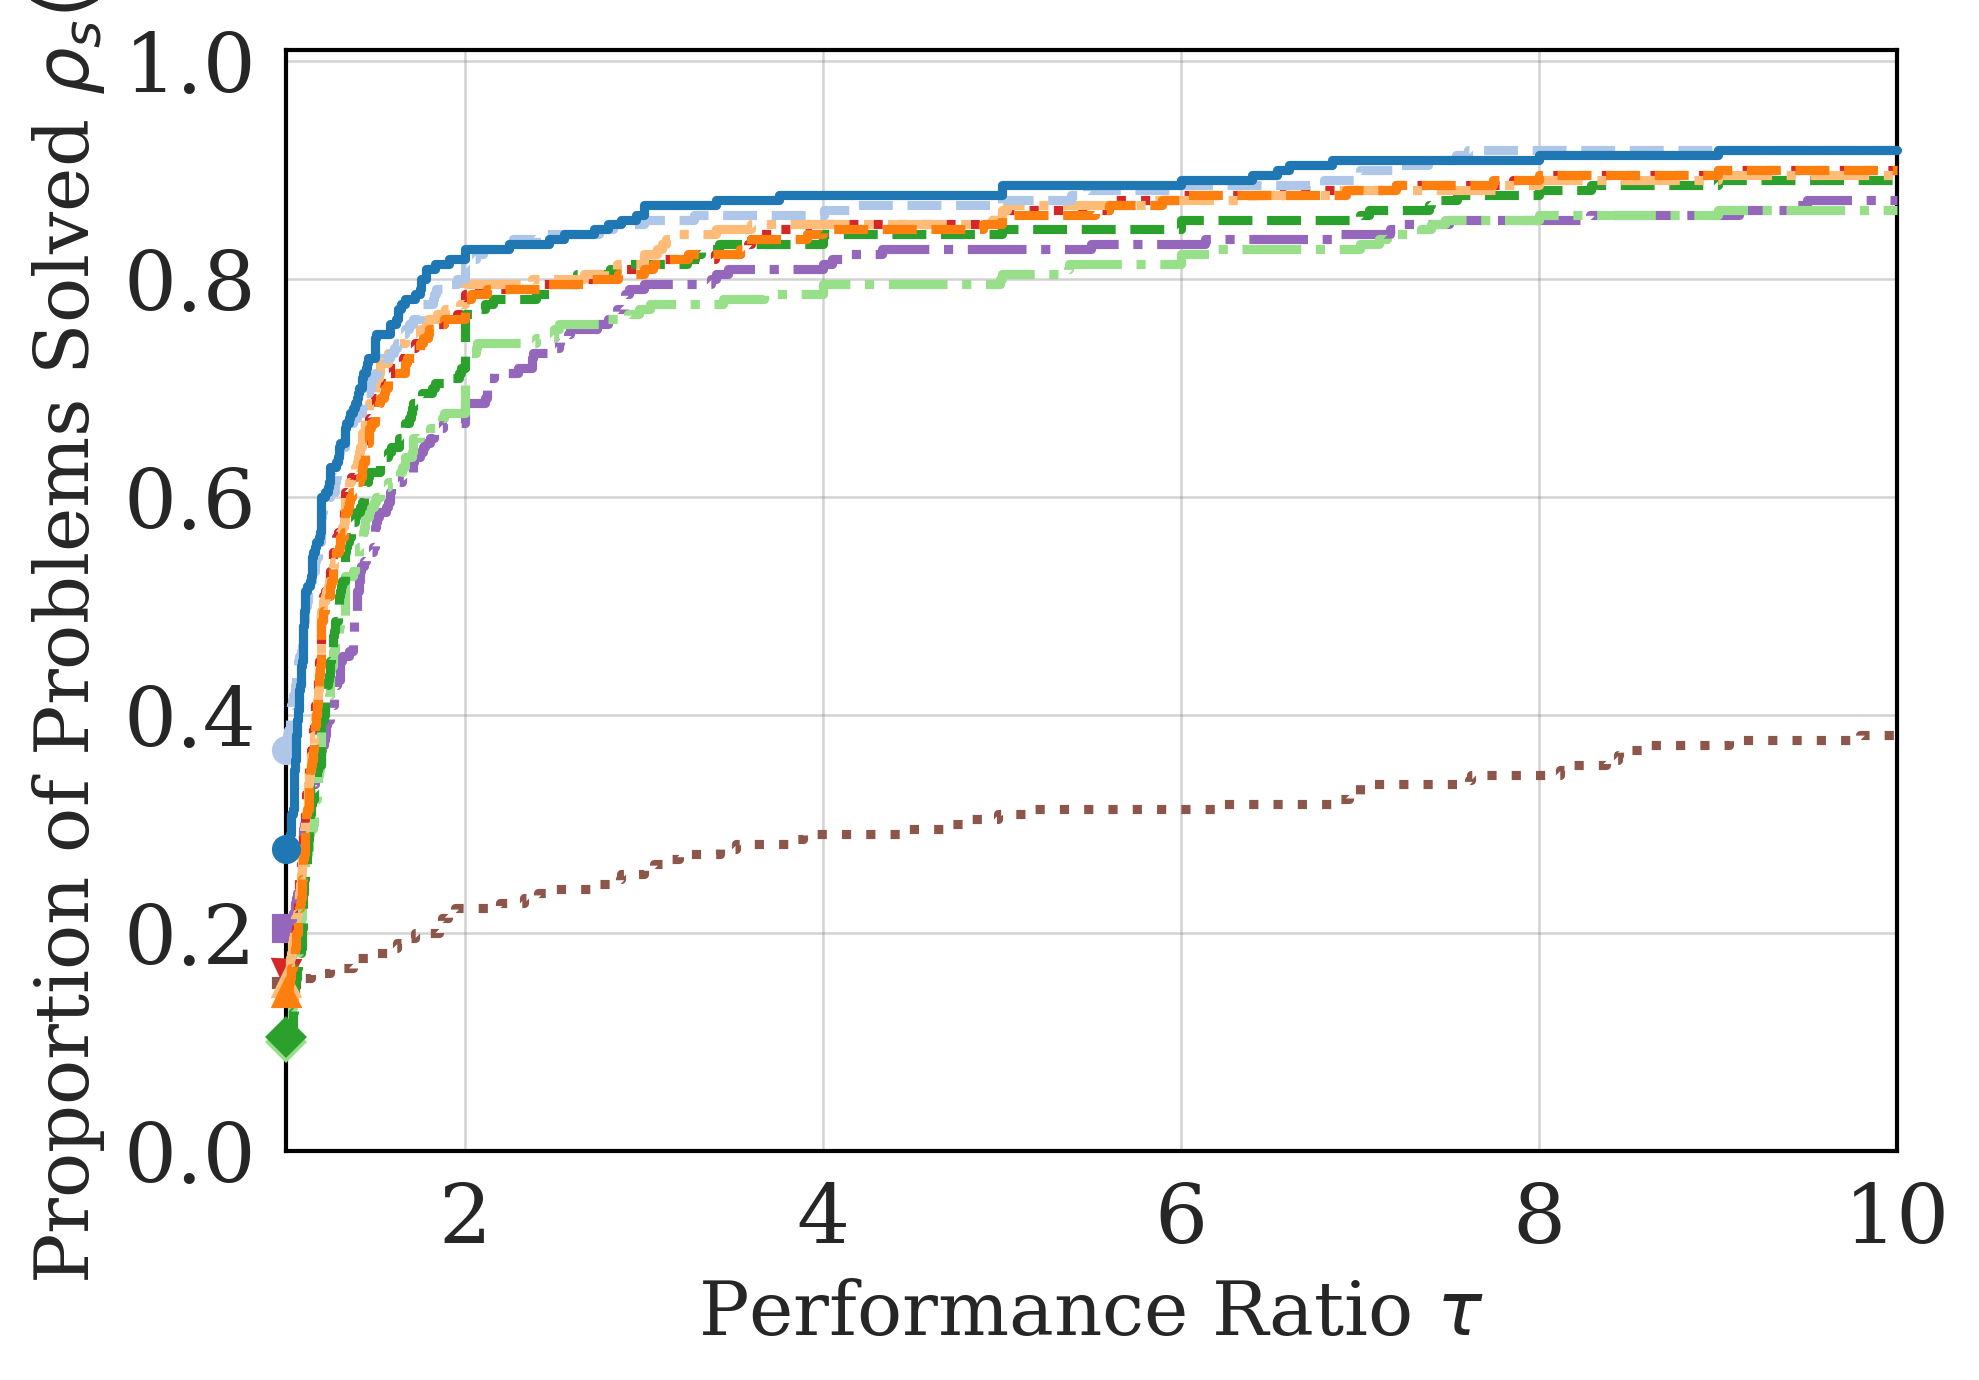

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-01.pdf


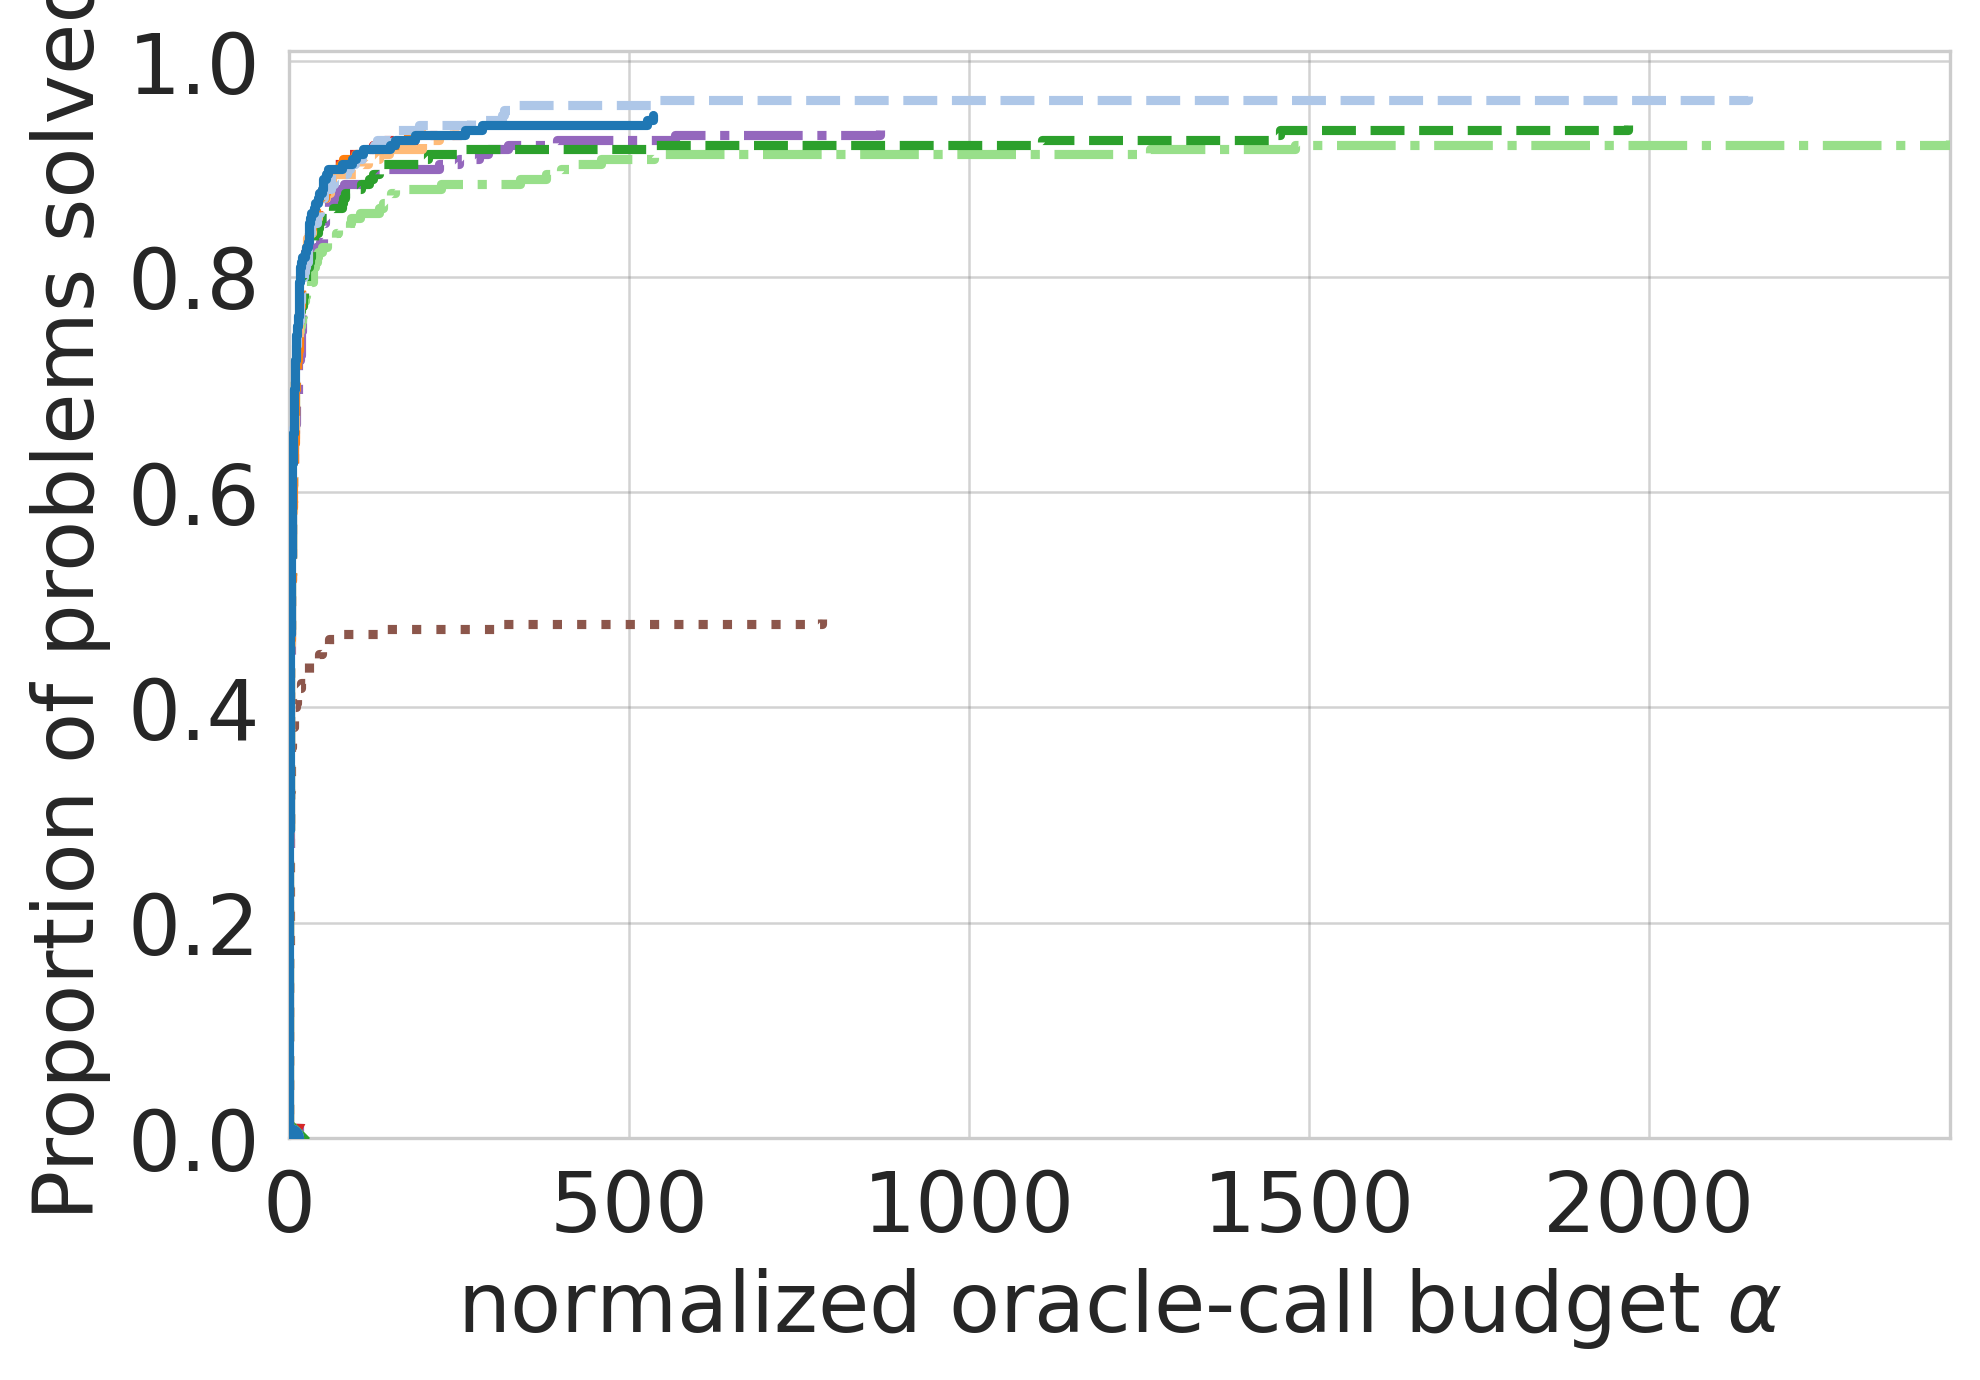

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),45.0,46.0,40.0,36.0,41.0,39.0,40.0,inf,inf
ALLINITU (seed=0),19.0,19.0,20.0,20.0,20.0,20.0,20.0,21.0,37.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,12.0,12.0,8.0,5.0,8.0
ARGLINB (seed=0),6.0,8.0,8.0,8.0,10.0,10.0,8.0,42.0,4.0
ARGLINC (seed=0),6.0,8.0,8.0,8.0,10.0,10.0,8.0,42.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),40.0,36.0,40.0,42.0,44.0,44.0,40.0,65.0,770.0
YATP1LS (seed=0),37.0,36.0,50.0,50.0,46.0,46.0,50.0,77.0,inf
YATP2LS (seed=0),38.0,35.0,46.0,48.0,49.0,49.0,46.0,26.0,inf
YFITU (seed=0),170.0,161.0,186.0,178.0,168.0,223.0,182.0,198.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,95.000000,27.727273
NTRQN-MS,96.818182,36.818182
Line,93.636364,14.545455
Line-MS,93.636364,15.454545
Reg,94.090909,10.454545
Reg-Sec,92.727273,10.000000
SciPy,93.636364,16.363636
NTQN,93.636364,20.454545
ASTR1-Adagrad,48.181818,15.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,219,1,0,31
NTRQN-MS,220,0,219,1,0,29
Line,220,0,219,1,0,53
Line-MS,220,0,219,1,0,50
Reg,220,0,217,3,0,36
Reg-Sec,220,0,217,3,0,44
SciPy,220,0,215,5,0,22
NTQN,220,0,214,6,0,7
ASTR1-Adagrad,220,0,217,3,0,181


flag,0,1,6
method,,,
NTQN,184,7,23


Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-03.pdf


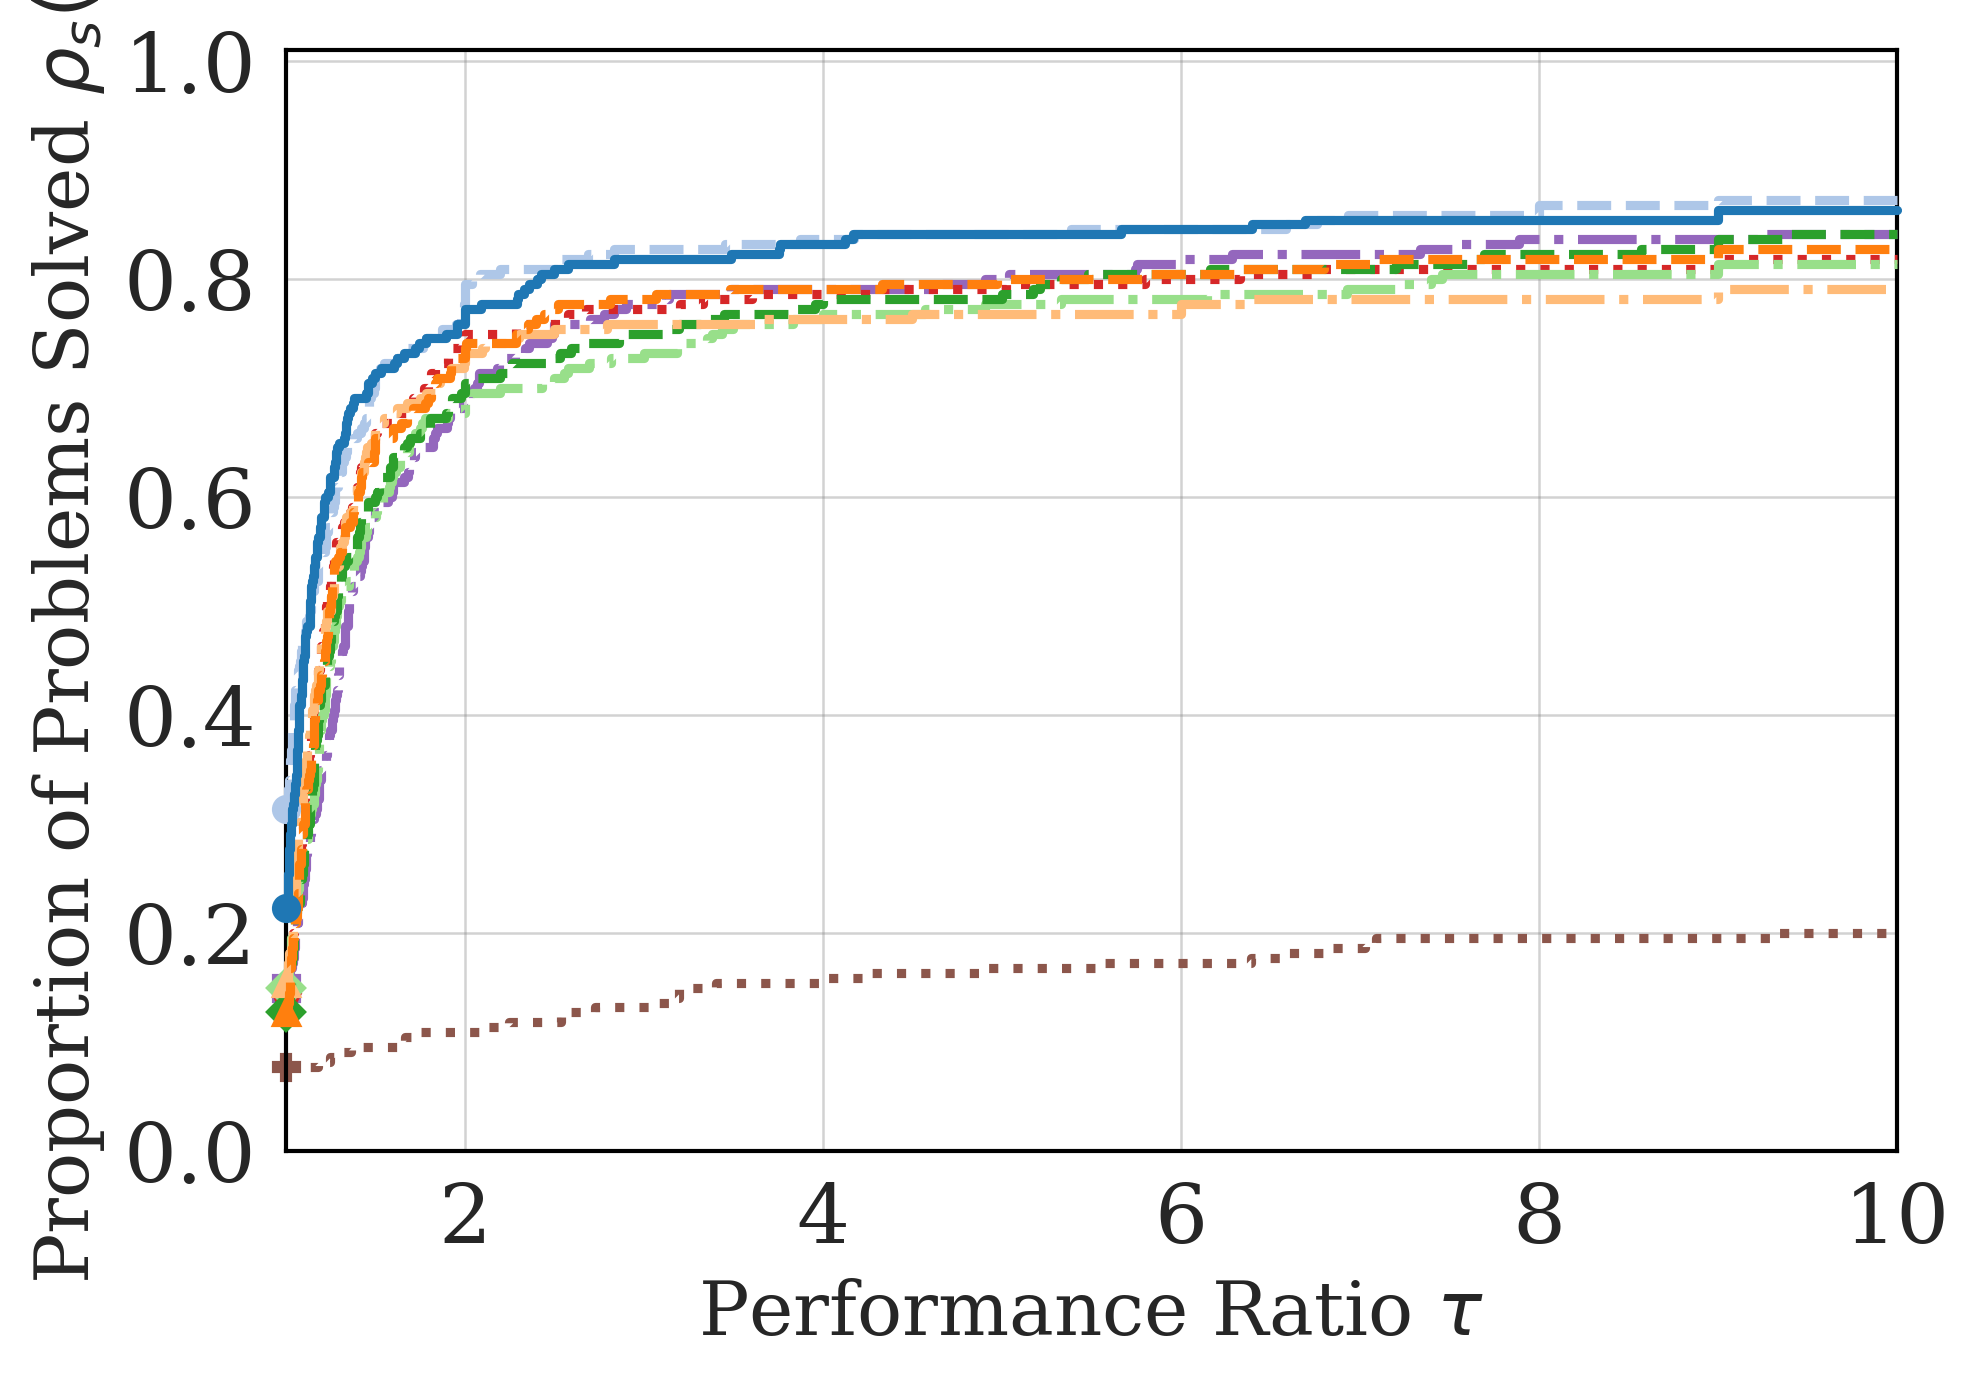

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-03.pdf


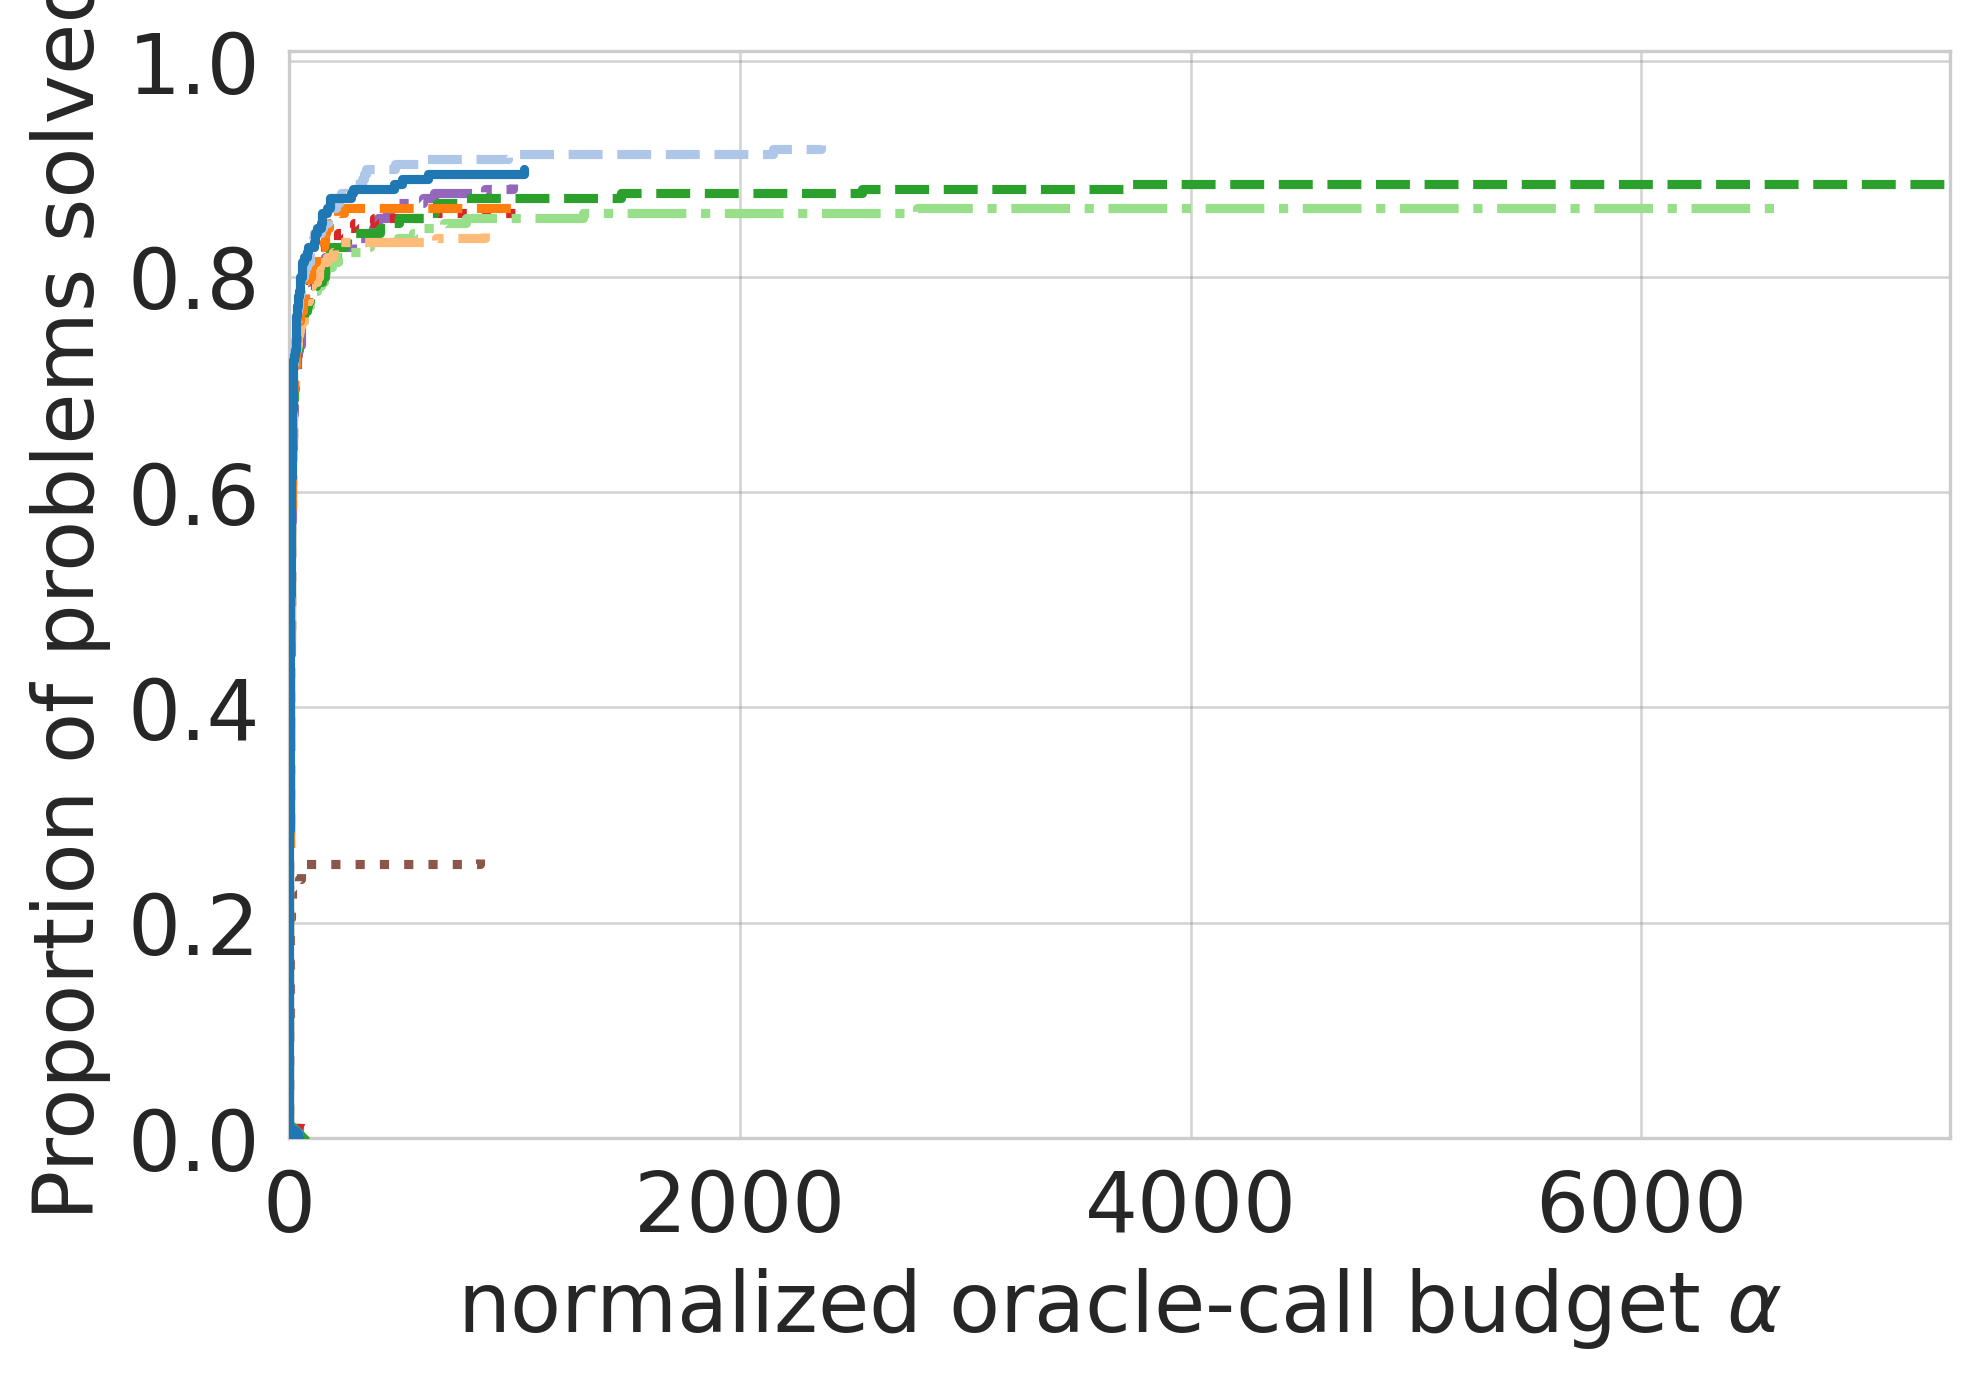

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),49.0,50.0,44.0,38.0,49.0,49.0,44.0,inf,inf
ALLINITU (seed=0),23.0,23.0,24.0,26.0,22.0,24.0,24.0,25.0,60.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,16.0,16.0,8.0,5.0,16.0
ARGLINB (seed=0),8.0,8.0,inf,inf,inf,12.0,inf,69.0,4.0
ARGLINC (seed=0),10.0,8.0,10.0,10.0,inf,10.0,inf,58.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),207.0,185.0,224.0,204.0,289.0,247.0,234.0,73.0,inf
YATP1LS (seed=0),41.0,36.0,54.0,52.0,46.0,46.0,54.0,79.0,inf
YATP2LS (seed=0),38.0,37.0,50.0,48.0,53.0,53.0,50.0,26.0,inf
YFITU (seed=0),176.0,165.0,190.0,182.0,315.0,260.0,188.0,204.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,90.000000,22.272727
NTRQN-MS,92.272727,31.363636
Line,86.818182,12.727273
Line-MS,84.090909,15.454545
Reg,89.090909,12.727273
Reg-Sec,86.818182,15.000000
SciPy,86.363636,13.181818
NTQN,88.636364,15.000000
ASTR1-Adagrad,25.909091,7.727273


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,219,1,0,31
NTRQN-MS,220,0,219,1,0,29
Line,220,0,219,1,0,53
Line-MS,220,0,219,1,0,50
Reg,220,0,217,3,0,36
Reg-Sec,220,0,217,3,0,44
SciPy,220,0,215,5,0,22
NTQN,220,0,214,6,0,7
ASTR1-Adagrad,220,0,217,3,0,181


flag,0,1,6
method,,,
NTQN,184,7,23


Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-05.pdf


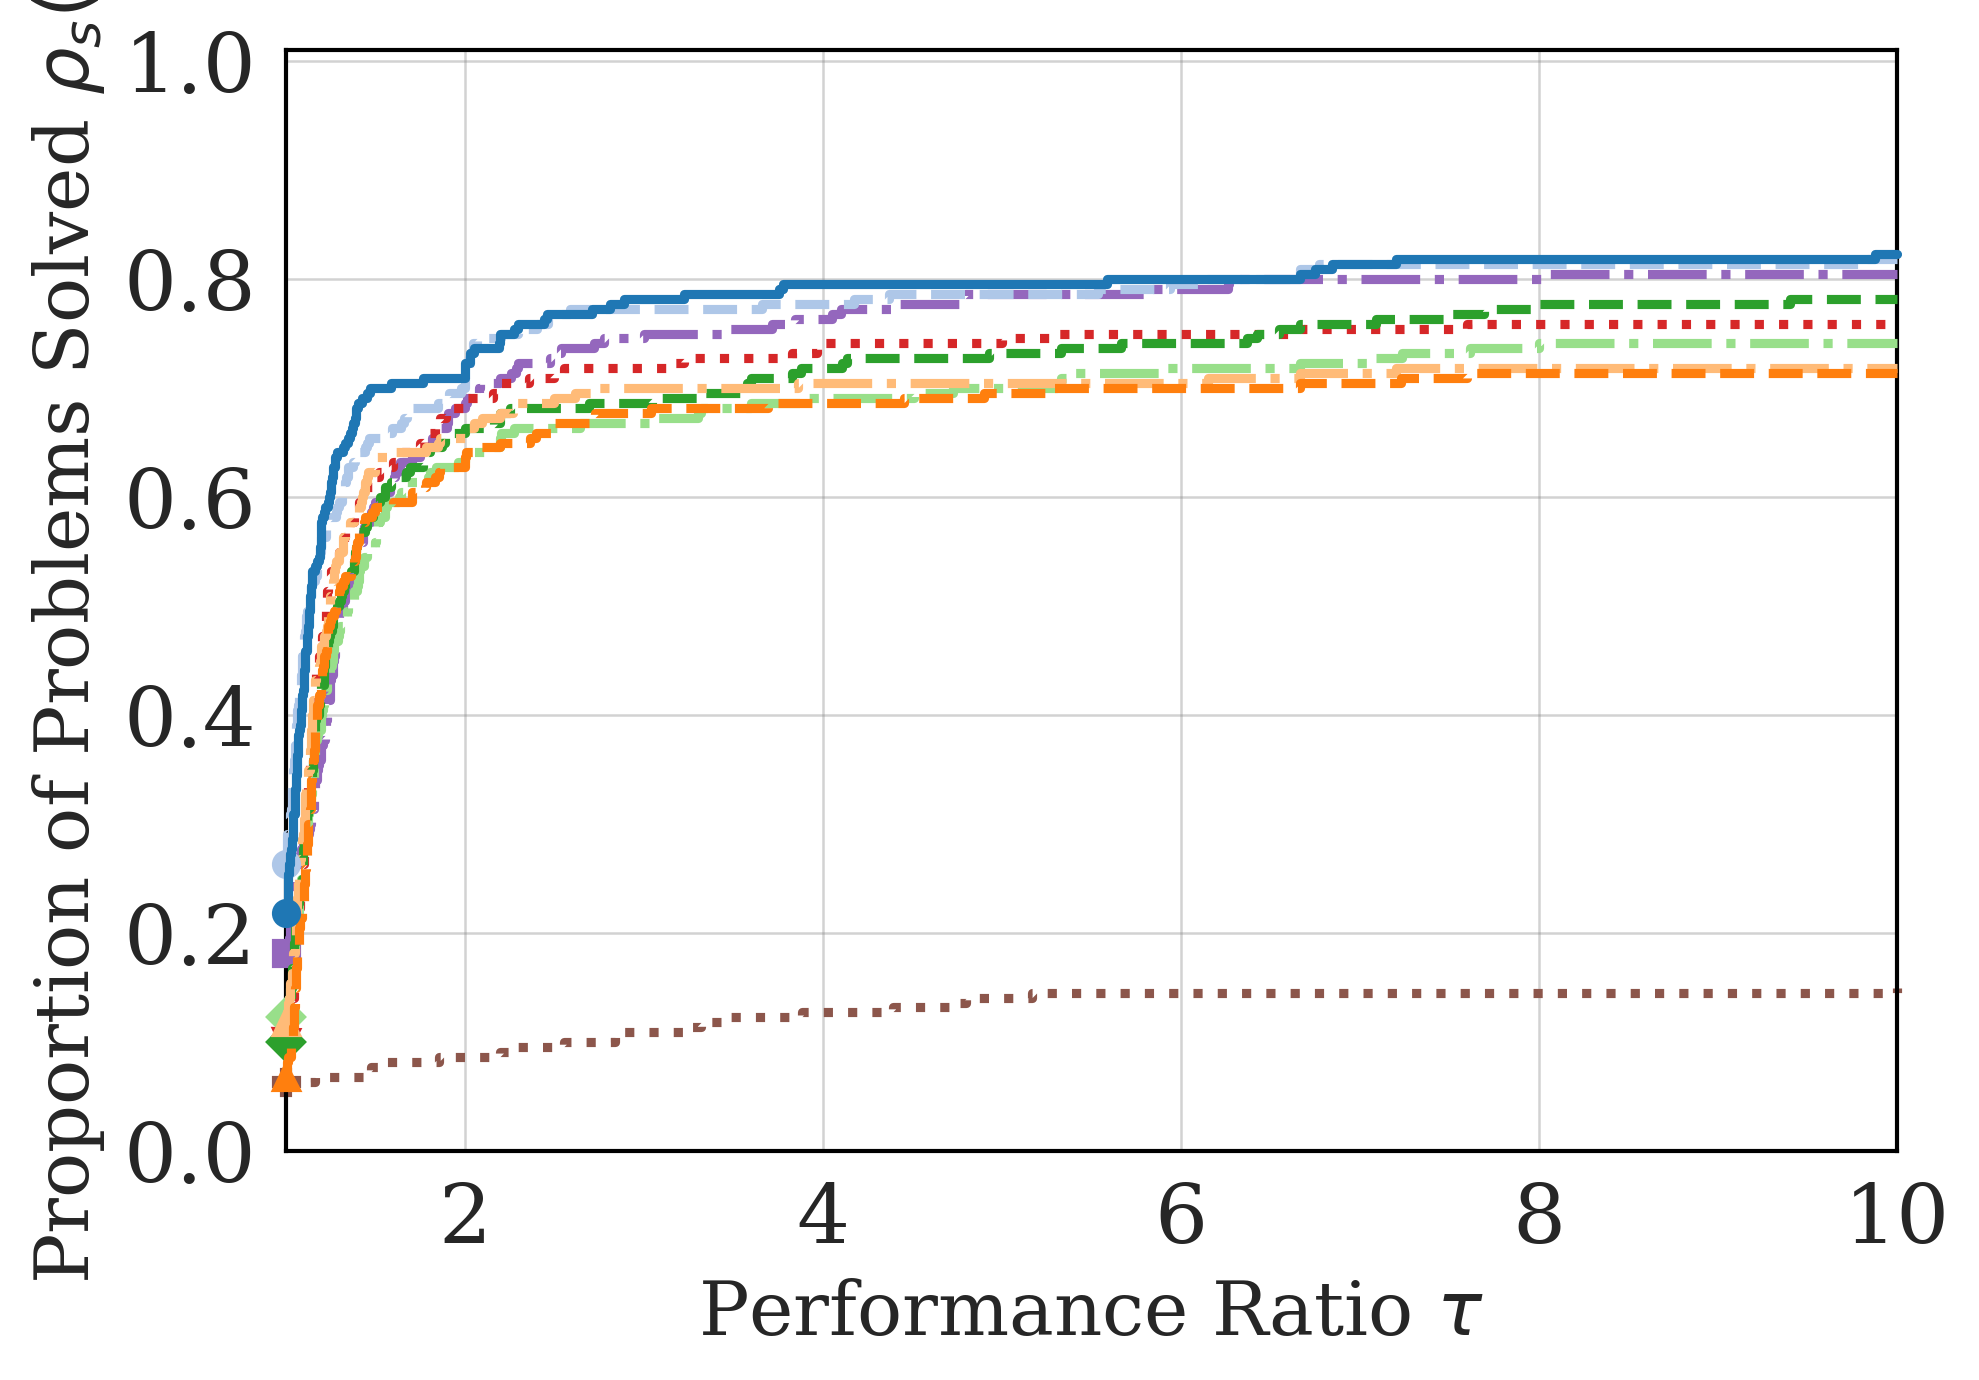

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-05.pdf


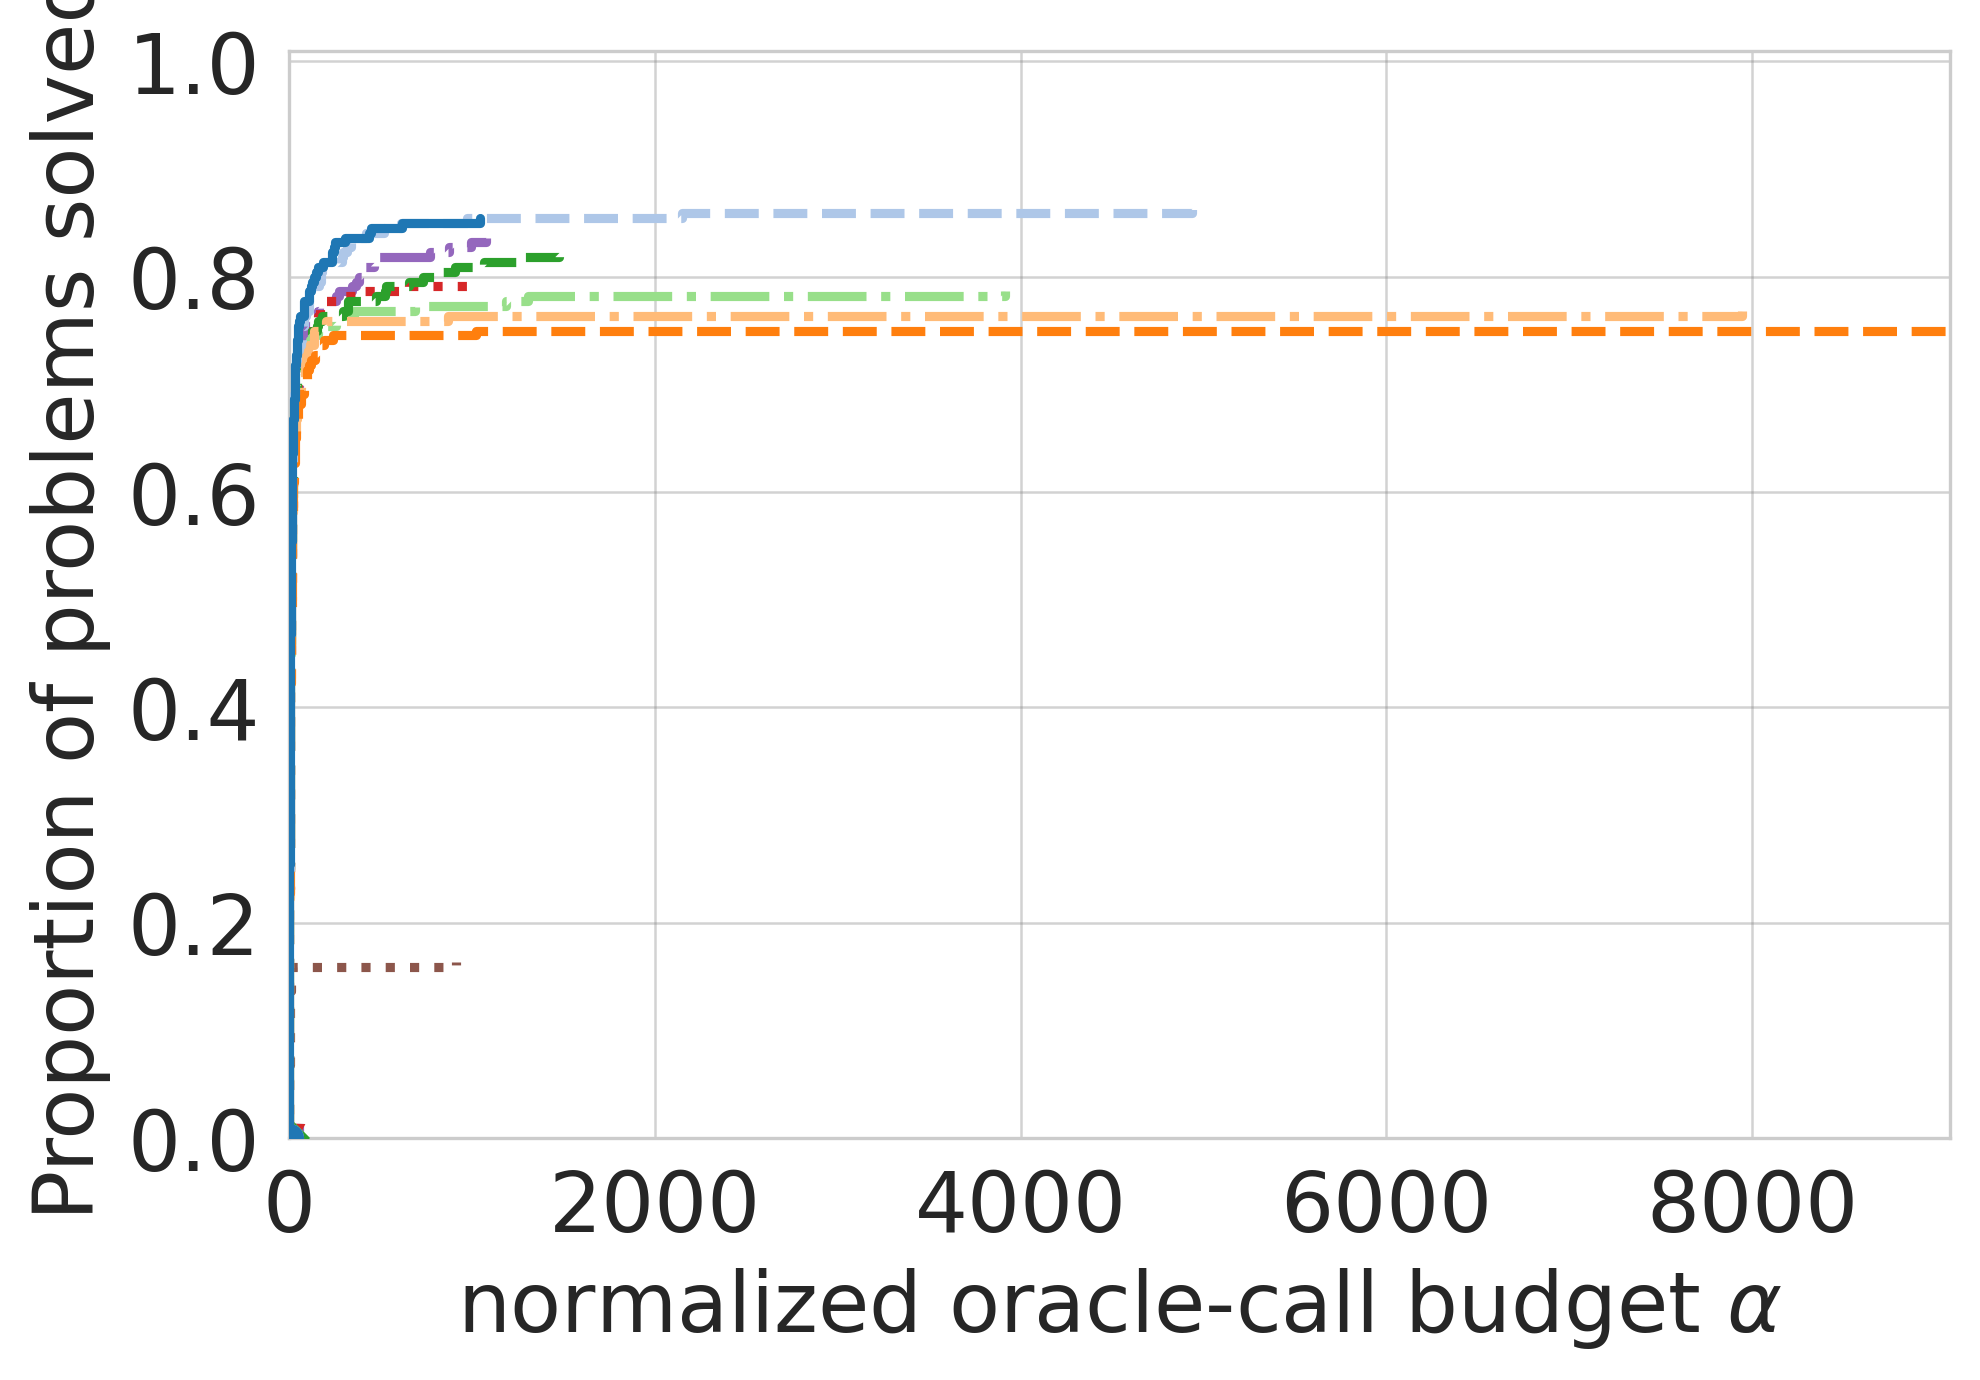

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),51.0,50.0,46.0,42.0,51.0,51.0,46.0,inf,inf
ALLINITU (seed=0),25.0,27.0,26.0,28.0,26.0,26.0,26.0,29.0,83.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,18.0,18.0,8.0,5.0,24.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,63.0,inf,inf,4.0
ARGLINC (seed=0),968.0,1214.0,inf,inf,inf,inf,inf,97.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),211.0,189.0,228.0,206.0,291.0,249.0,238.0,75.0,inf
YATP1LS (seed=0),43.0,38.0,54.0,54.0,48.0,48.0,54.0,79.0,inf
YATP2LS (seed=0),38.0,39.0,50.0,50.0,53.0,55.0,50.0,28.0,inf
YFITU (seed=0),182.0,167.0,196.0,190.0,323.0,262.0,190.0,206.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,85.454545,21.818182
NTRQN-MS,86.363636,26.363636
Line,75.454545,6.818182
Line-MS,76.818182,11.818182
Reg,82.272727,10.000000
Reg-Sec,78.636364,12.272727
SciPy,79.545455,10.000000
NTQN,83.636364,18.181818
ASTR1-Adagrad,16.363636,6.363636


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,219,1,0,31
NTRQN-MS,220,0,219,1,0,29
Line,220,0,219,1,0,53
Line-MS,220,0,219,1,0,50
Reg,220,0,217,3,0,36
Reg-Sec,220,0,217,3,0,44
SciPy,220,0,215,5,0,22
NTQN,220,0,214,6,0,7
ASTR1-Adagrad,220,0,217,3,0,181


flag,0,1,6
method,,,
NTQN,184,7,23


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-01.pdf


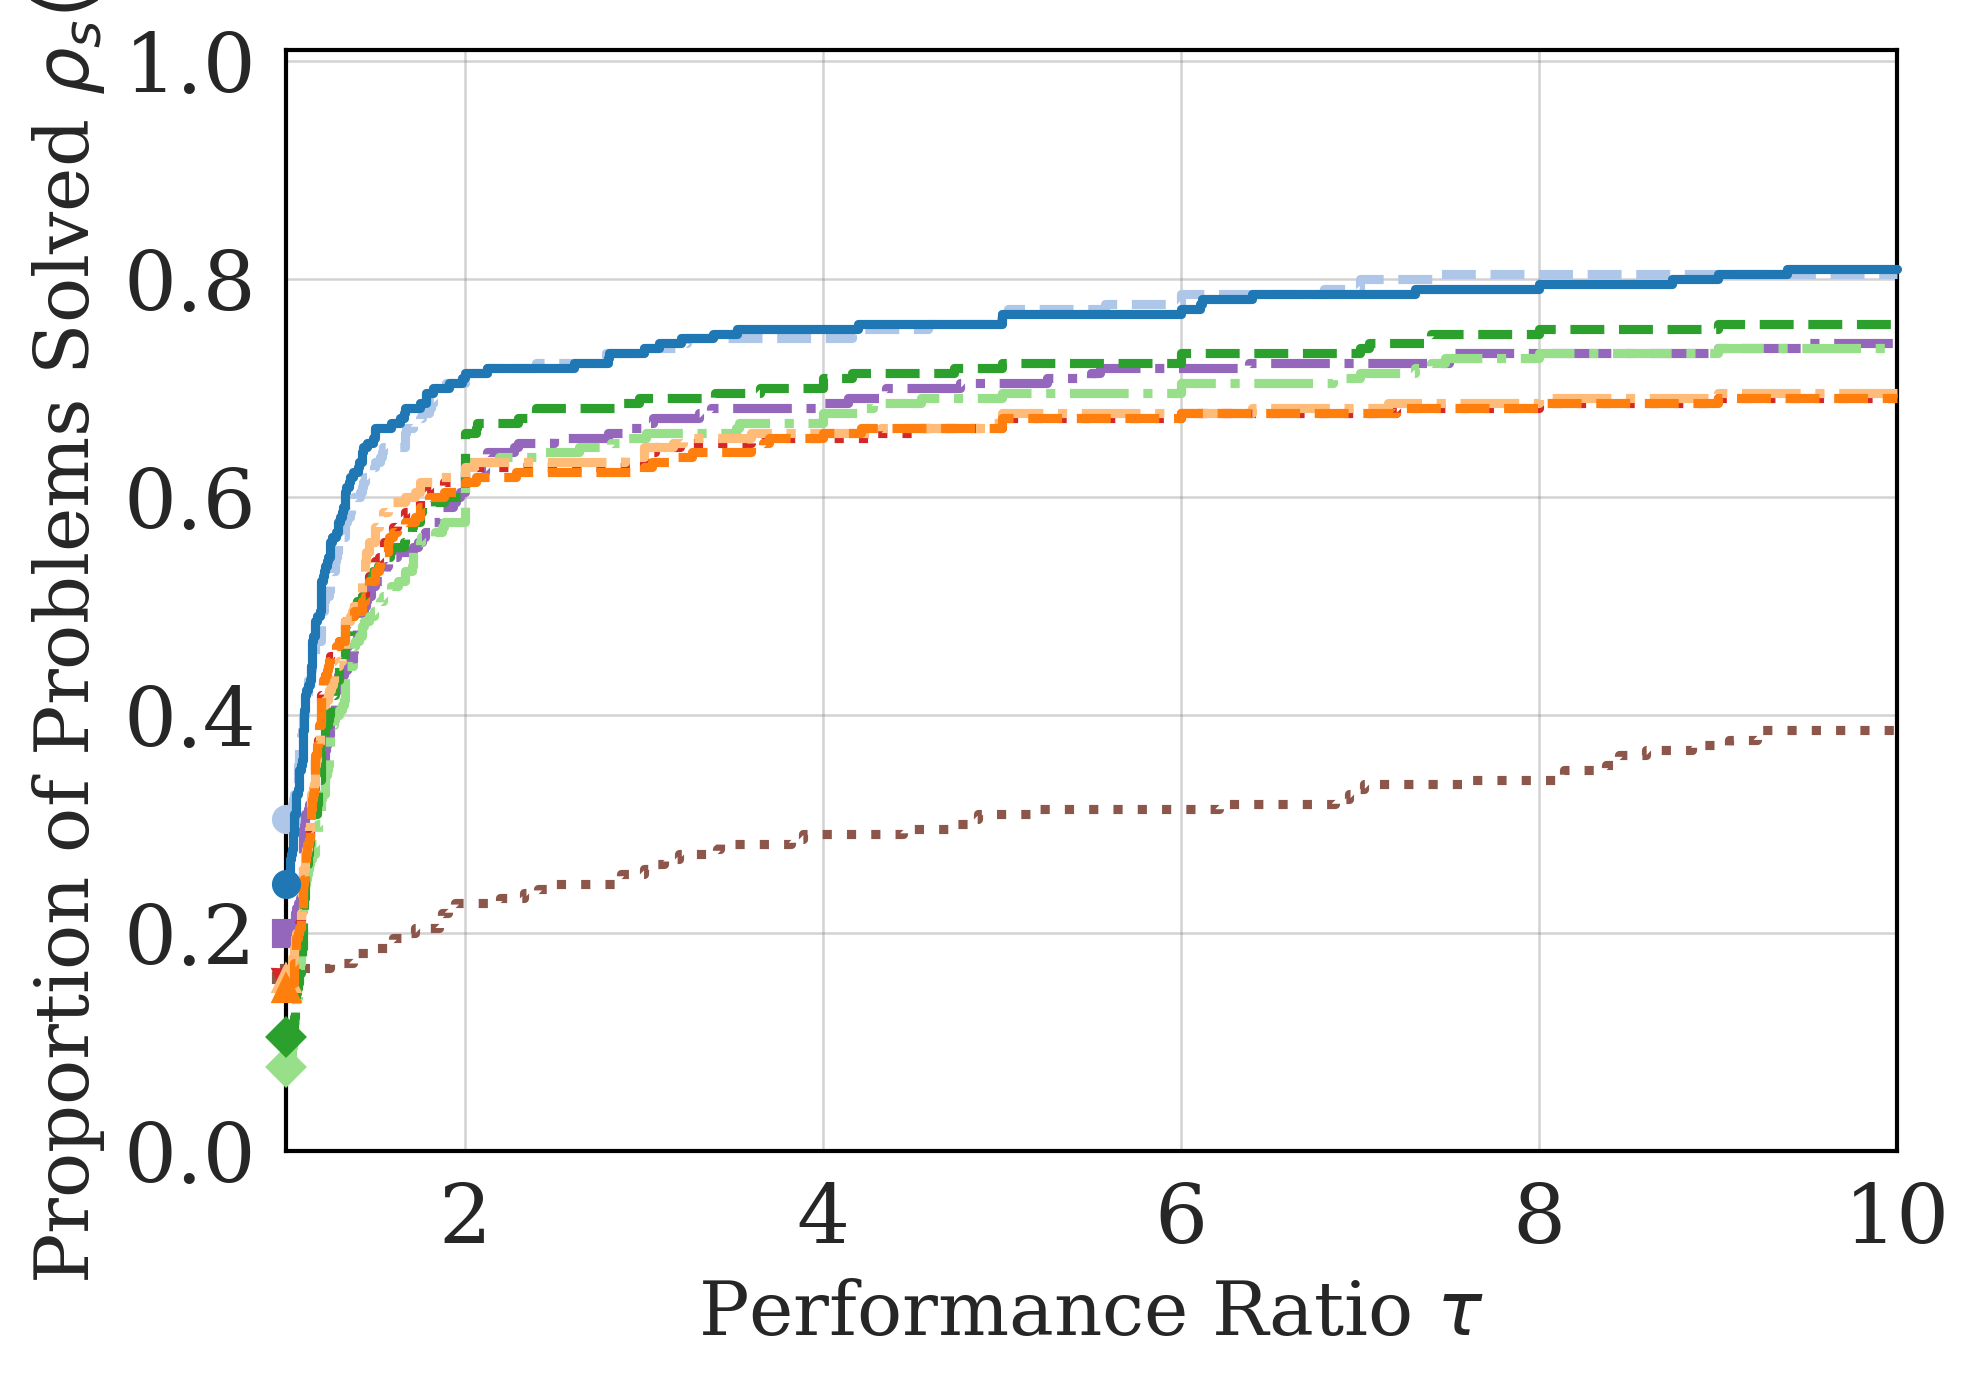

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-01.pdf


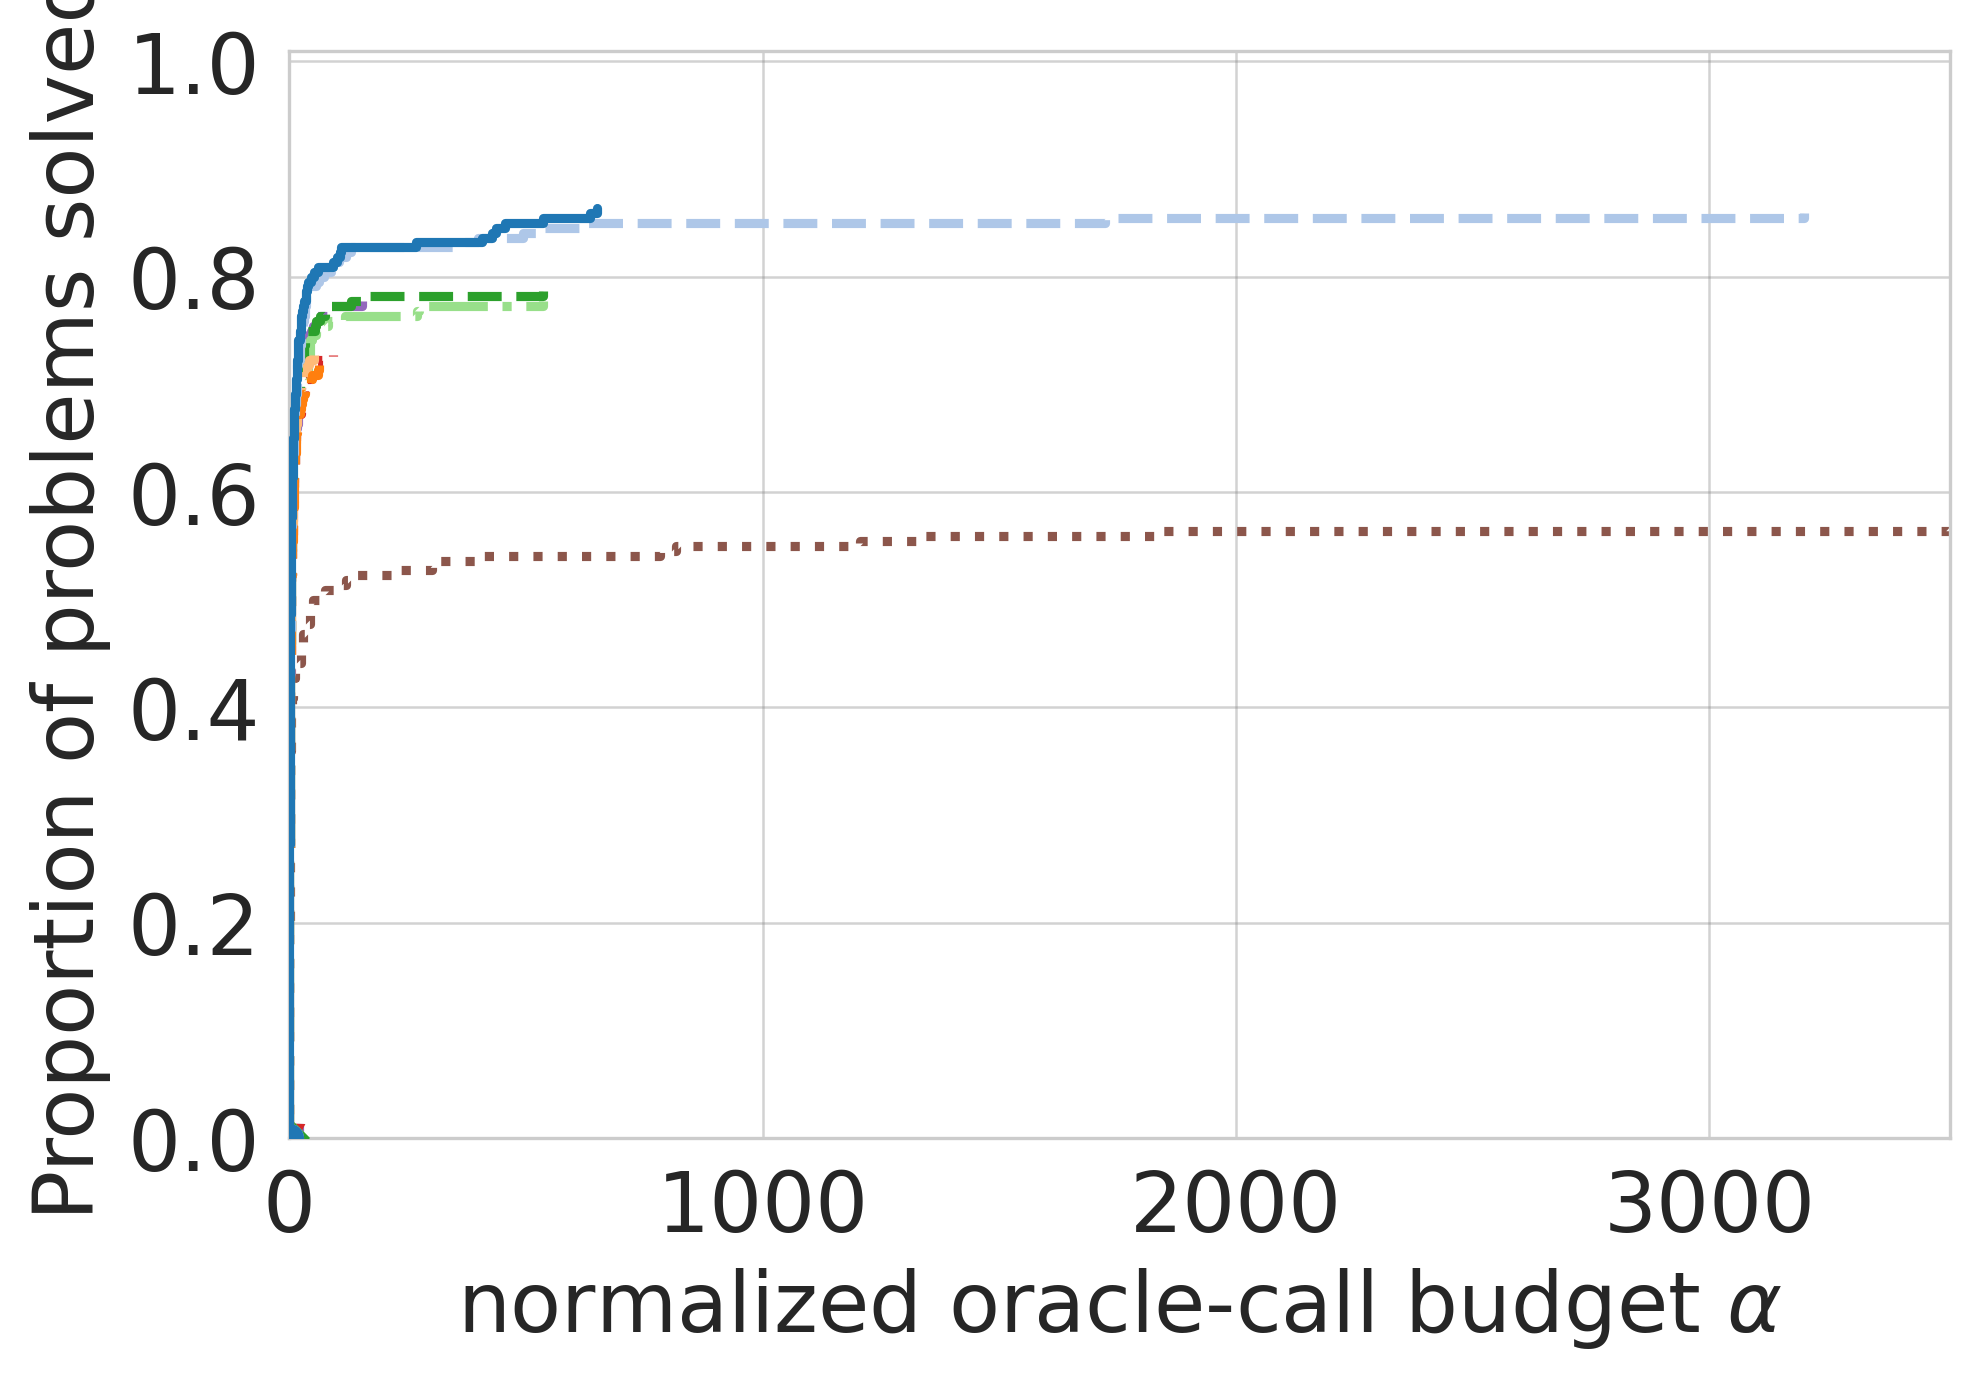

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),45.0,46.0,40.0,36.0,41.0,39.0,40.0,inf,3615.0
ALLINITU (seed=0),19.0,19.0,20.0,20.0,20.0,20.0,20.0,21.0,37.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,12.0,12.0,8.0,5.0,8.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,4.0
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,5.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),40.0,36.0,40.0,42.0,44.0,44.0,40.0,65.0,770.0
YATP1LS (seed=0),43.0,39.0,50.0,50.0,44.0,48.0,50.0,77.0,inf
YATP2LS (seed=0),244.0,inf,46.0,48.0,49.0,49.0,46.0,26.0,inf
YFITU (seed=0),154.0,148.0,192.0,168.0,259.0,221.0,192.0,183.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,86.363636,24.545455
NTRQN-MS,85.909091,30.454545
Line,71.818182,15.000000
Line-MS,72.727273,15.909091
Reg,78.636364,10.454545
Reg-Sec,77.727273,7.727273
SciPy,72.727273,15.454545
NTQN,77.727273,20.000000
ASTR1-Adagrad,56.818182,15.909091


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,215,5,0,99
NTRQN-MS,220,0,214,6,0,99
Line,220,0,220,0,0,155
Line-MS,220,0,220,0,0,154
Reg,220,0,217,1,2,120
Reg-Sec,220,0,219,1,0,125
SciPy,220,0,220,0,0,18
NTQN,220,0,217,3,0,2
ASTR1-Adagrad,220,0,216,4,0,173


flag,0,1,2,6
method,,,,
NTQN,108,1,1,107


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-03.pdf


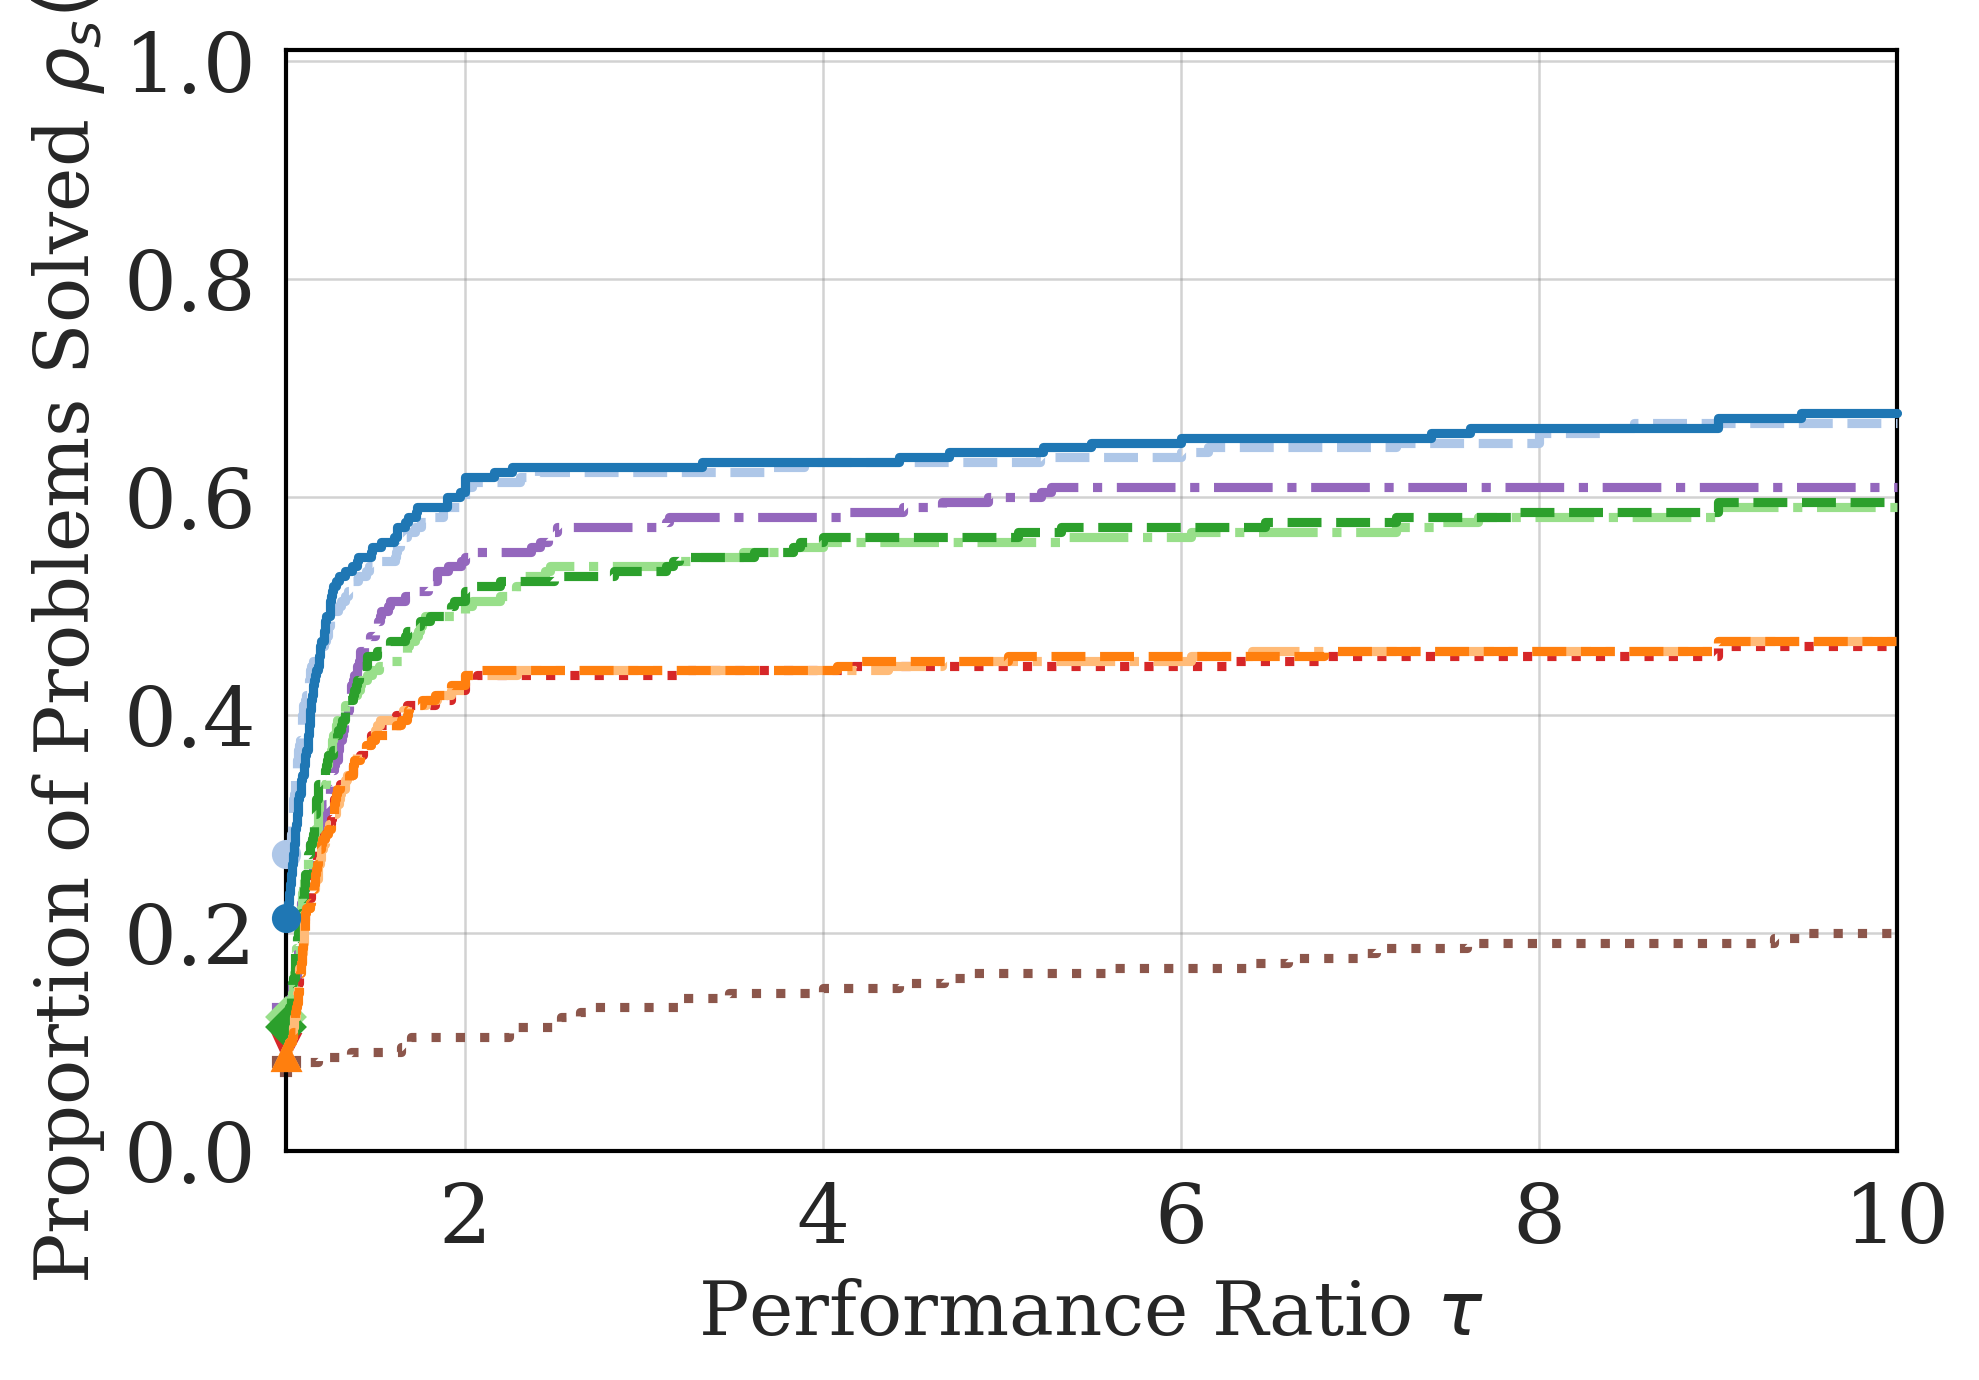

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-03.pdf


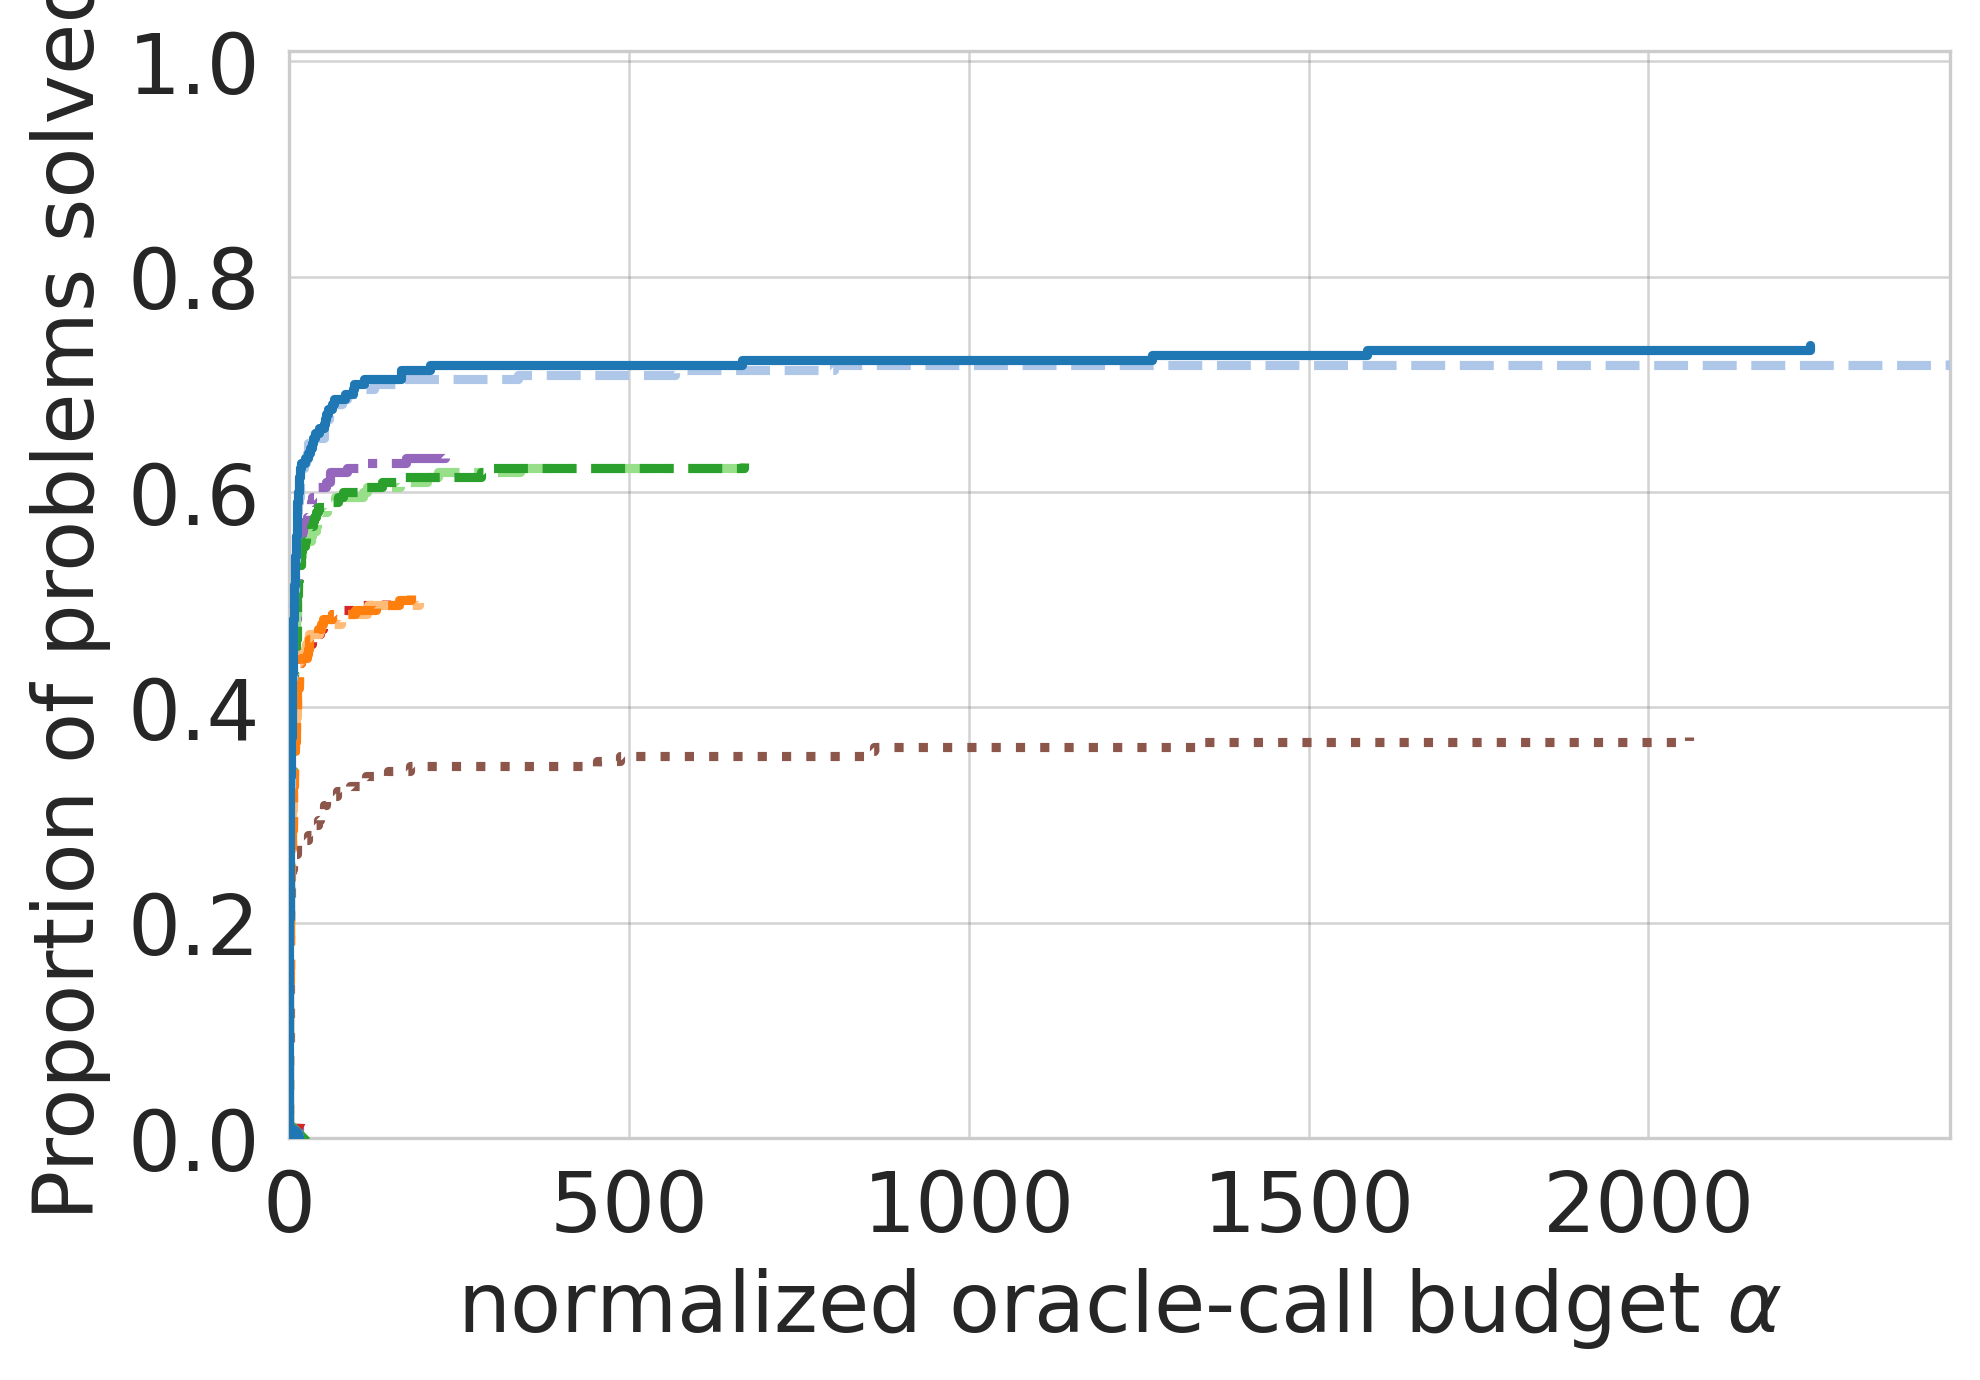

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),47.0,50.0,inf,inf,49.0,49.0,inf,inf,6179.0
ALLINITU (seed=0),27.0,27.0,24.0,26.0,22.0,24.0,24.0,25.0,60.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,16.0,16.0,8.0,5.0,16.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),323.0,270.0,inf,inf,264.0,240.0,inf,73.0,inf
YATP1LS (seed=0),inf,inf,inf,inf,44.0,inf,inf,inf,inf
YATP2LS (seed=0),246.0,inf,50.0,48.0,53.0,53.0,50.0,26.0,inf
YFITU (seed=0),204.0,204.0,198.0,172.0,287.0,255.0,198.0,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,73.636364,21.363636
NTRQN-MS,72.272727,27.272727
Line,50.454545,8.636364
Line-MS,50.000000,8.636364
Reg,62.727273,11.363636
Reg-Sec,62.727273,12.272727
SciPy,50.000000,9.545455
NTQN,63.636364,12.272727
ASTR1-Adagrad,37.272727,8.181818


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,215,5,0,99
NTRQN-MS,220,0,214,6,0,99
Line,220,0,220,0,0,155
Line-MS,220,0,220,0,0,154
Reg,220,0,217,1,2,120
Reg-Sec,220,0,219,1,0,125
SciPy,220,0,220,0,0,18
NTQN,220,0,217,3,0,2
ASTR1-Adagrad,220,0,216,4,0,173


flag,0,1,2,6
method,,,,
NTQN,108,1,1,107


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-05.pdf


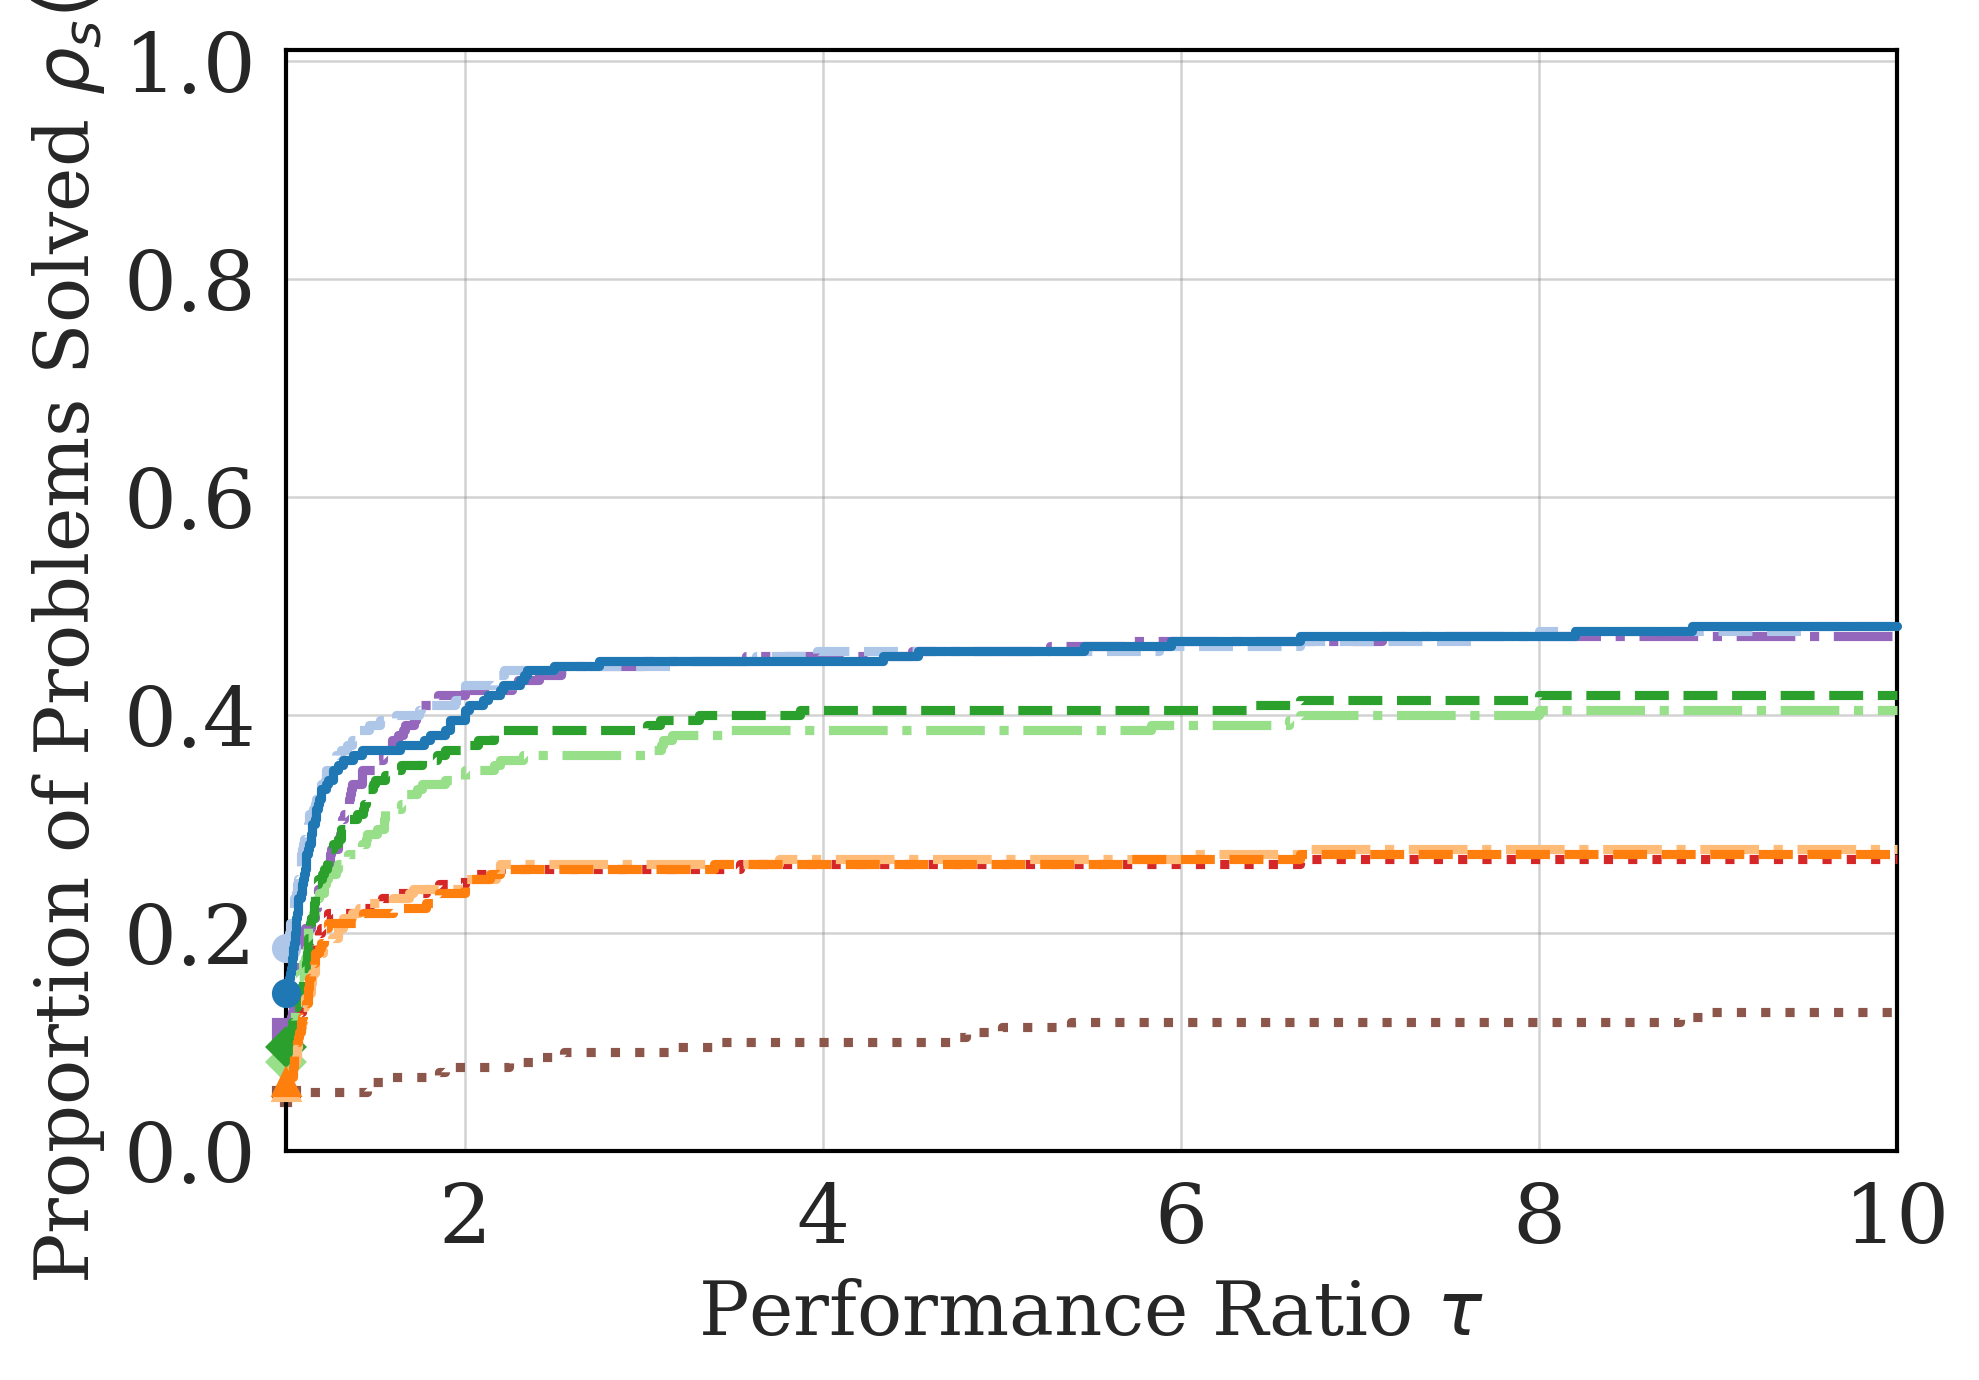

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-05.pdf


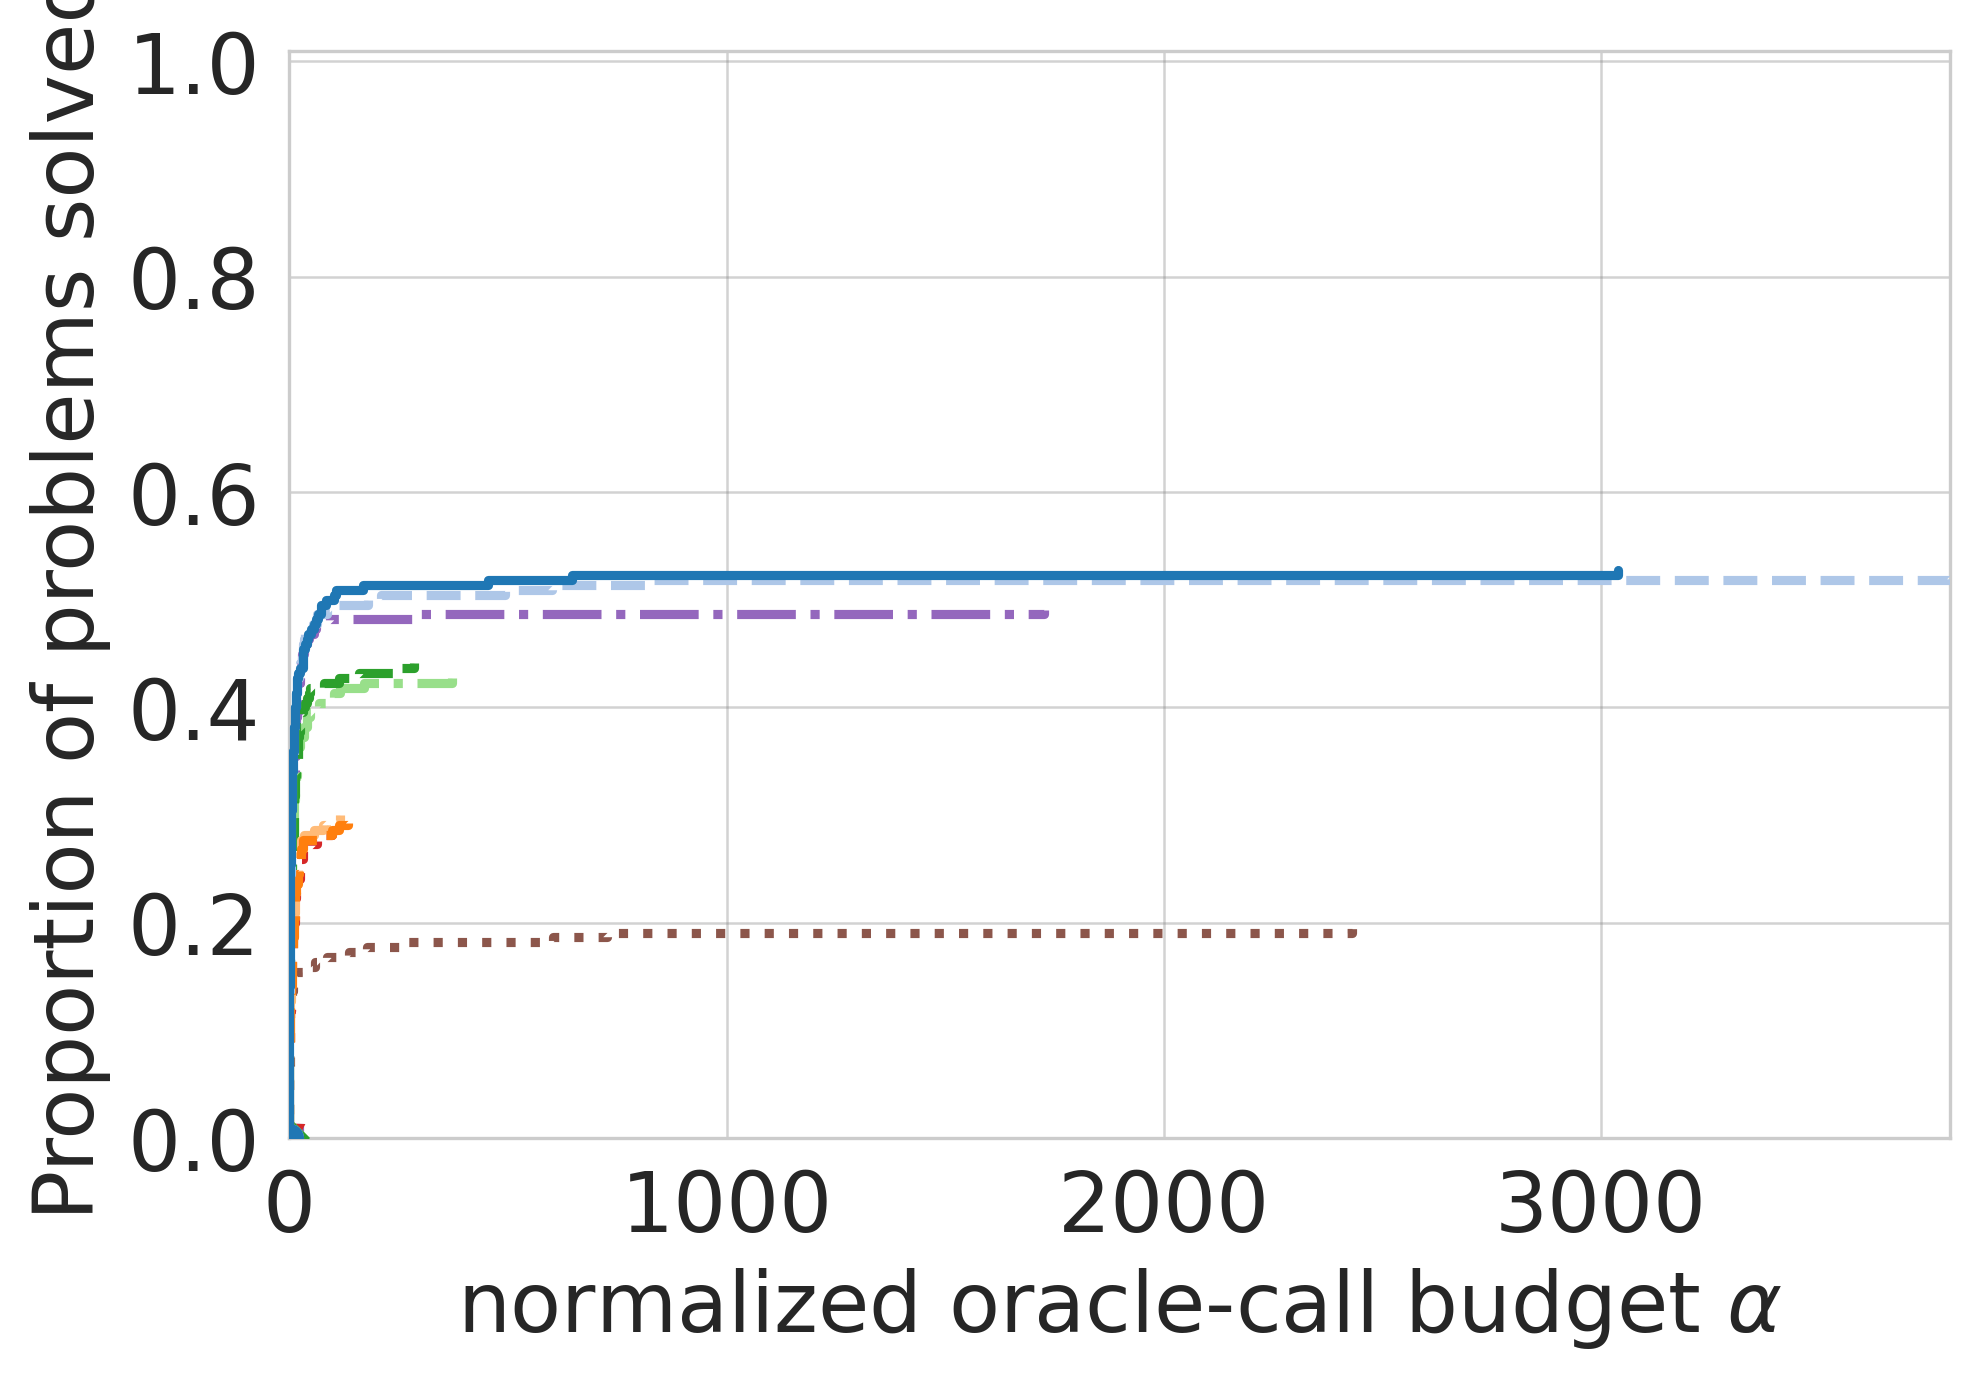

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),51.0,52.0,inf,inf,51.0,51.0,inf,inf,7289.0
ALLINITU (seed=0),29.0,29.0,inf,inf,26.0,26.0,inf,43.0,83.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,inf,inf,8.0,5.0,24.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),367.0,294.0,inf,inf,268.0,256.0,inf,81.0,inf
YATP1LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
YATP2LS (seed=0),248.0,inf,50.0,48.0,53.0,53.0,50.0,28.0,inf
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,52.727273,14.545455
NTRQN-MS,52.272727,18.636364
Line,29.545455,6.363636
Line-MS,30.000000,5.909091
Reg,44.090909,9.545455
Reg-Sec,42.727273,8.181818
SciPy,28.636364,7.272727
NTQN,49.090909,10.909091
ASTR1-Adagrad,19.545455,5.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,215,5,0,99
NTRQN-MS,220,0,214,6,0,99
Line,220,0,220,0,0,155
Line-MS,220,0,220,0,0,154
Reg,220,0,217,1,2,120
Reg-Sec,220,0,219,1,0,125
SciPy,220,0,220,0,0,18
NTQN,220,0,217,3,0,2
ASTR1-Adagrad,220,0,216,4,0,173


flag,0,1,2,6
method,,,,
NTQN,108,1,1,107


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-01.pdf


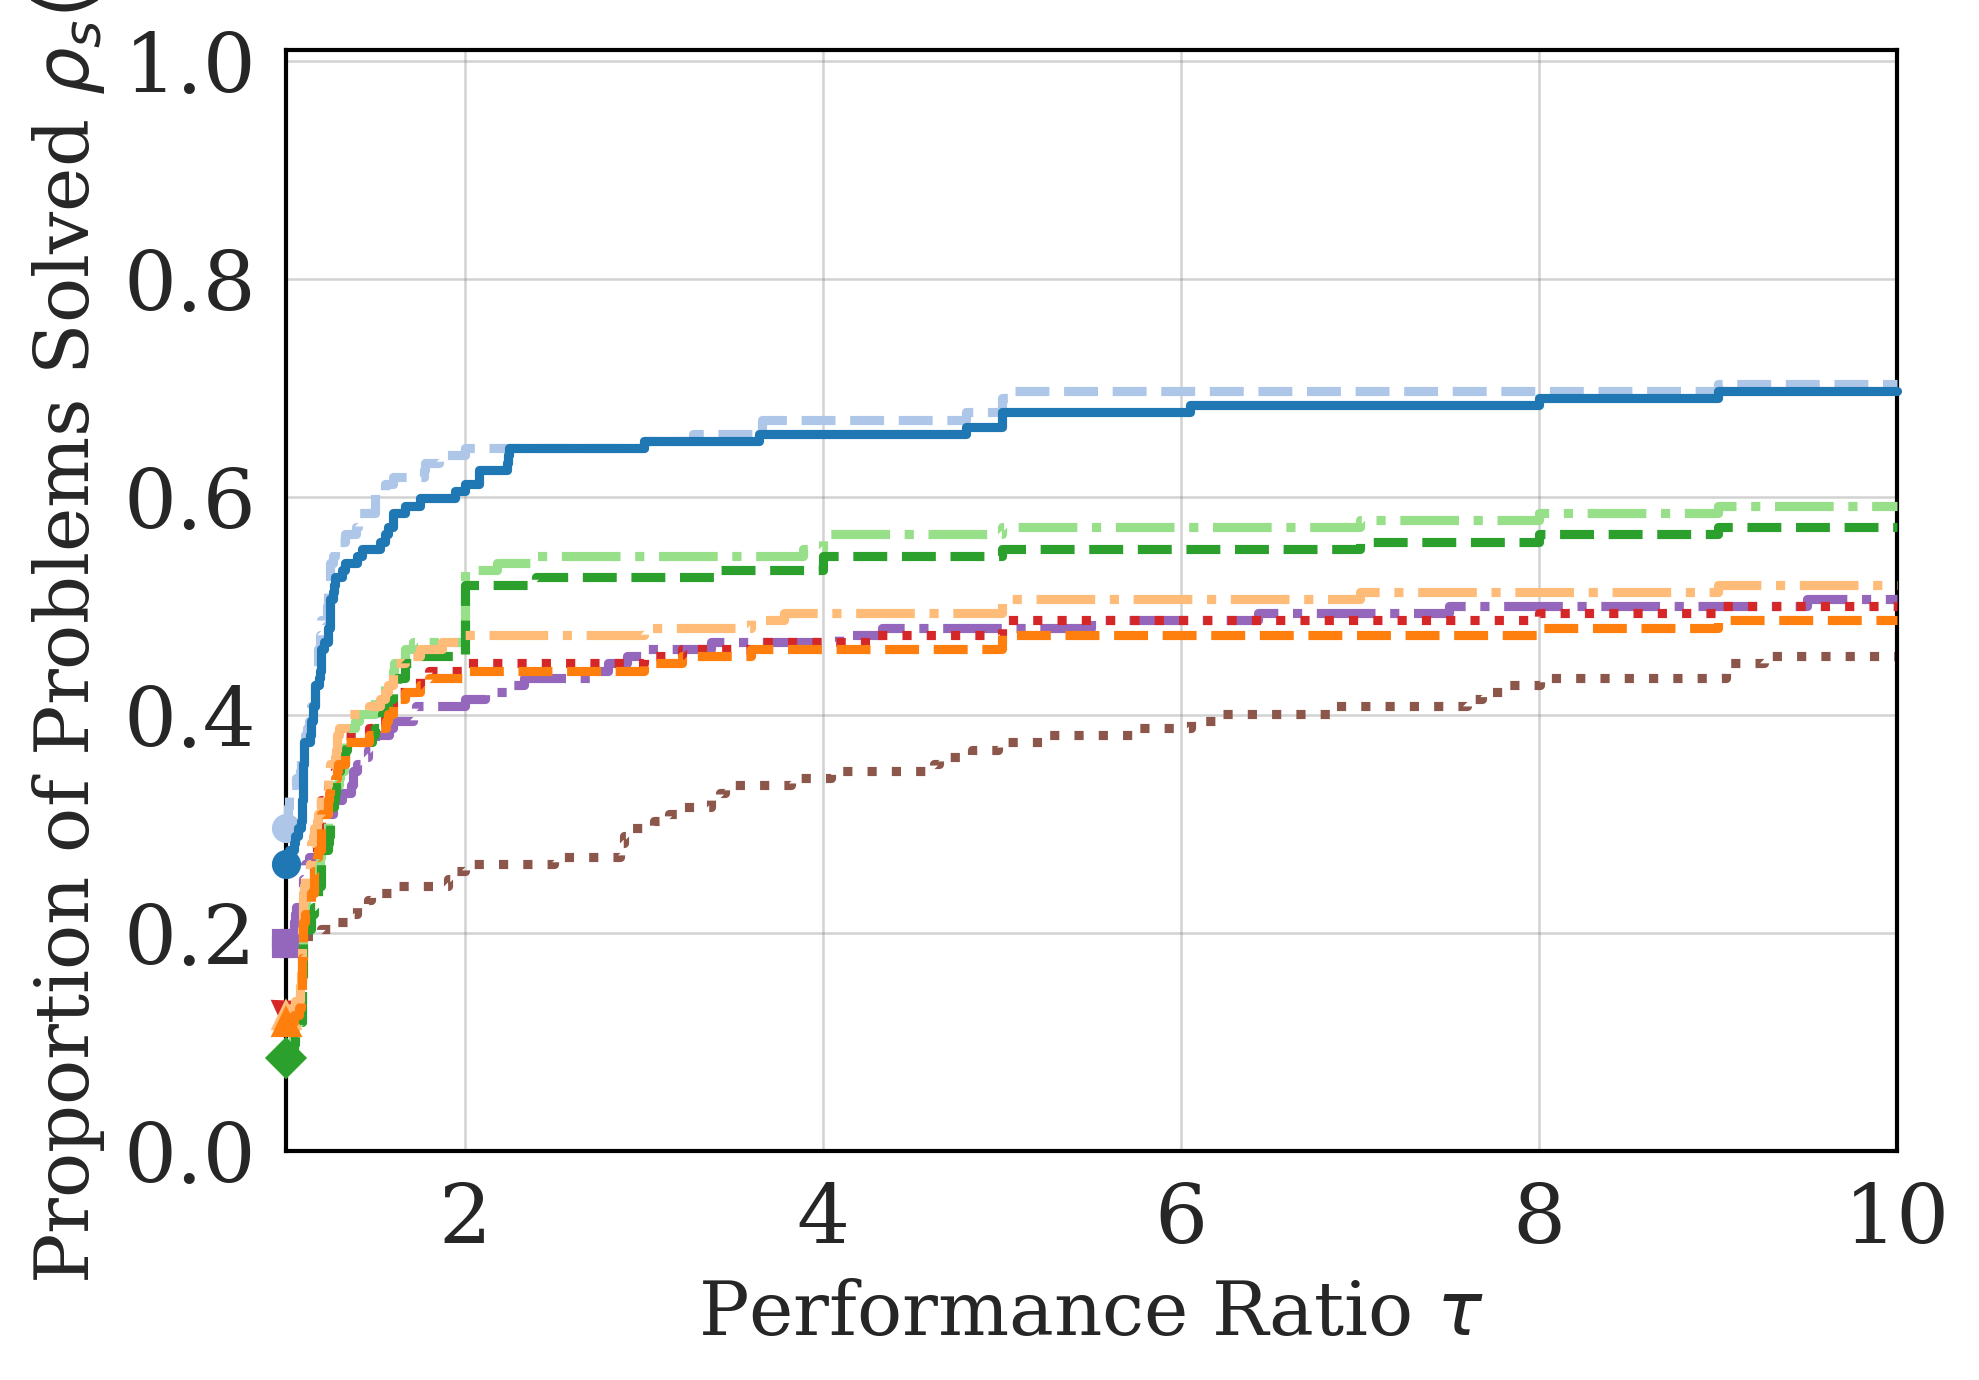

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-01.pdf


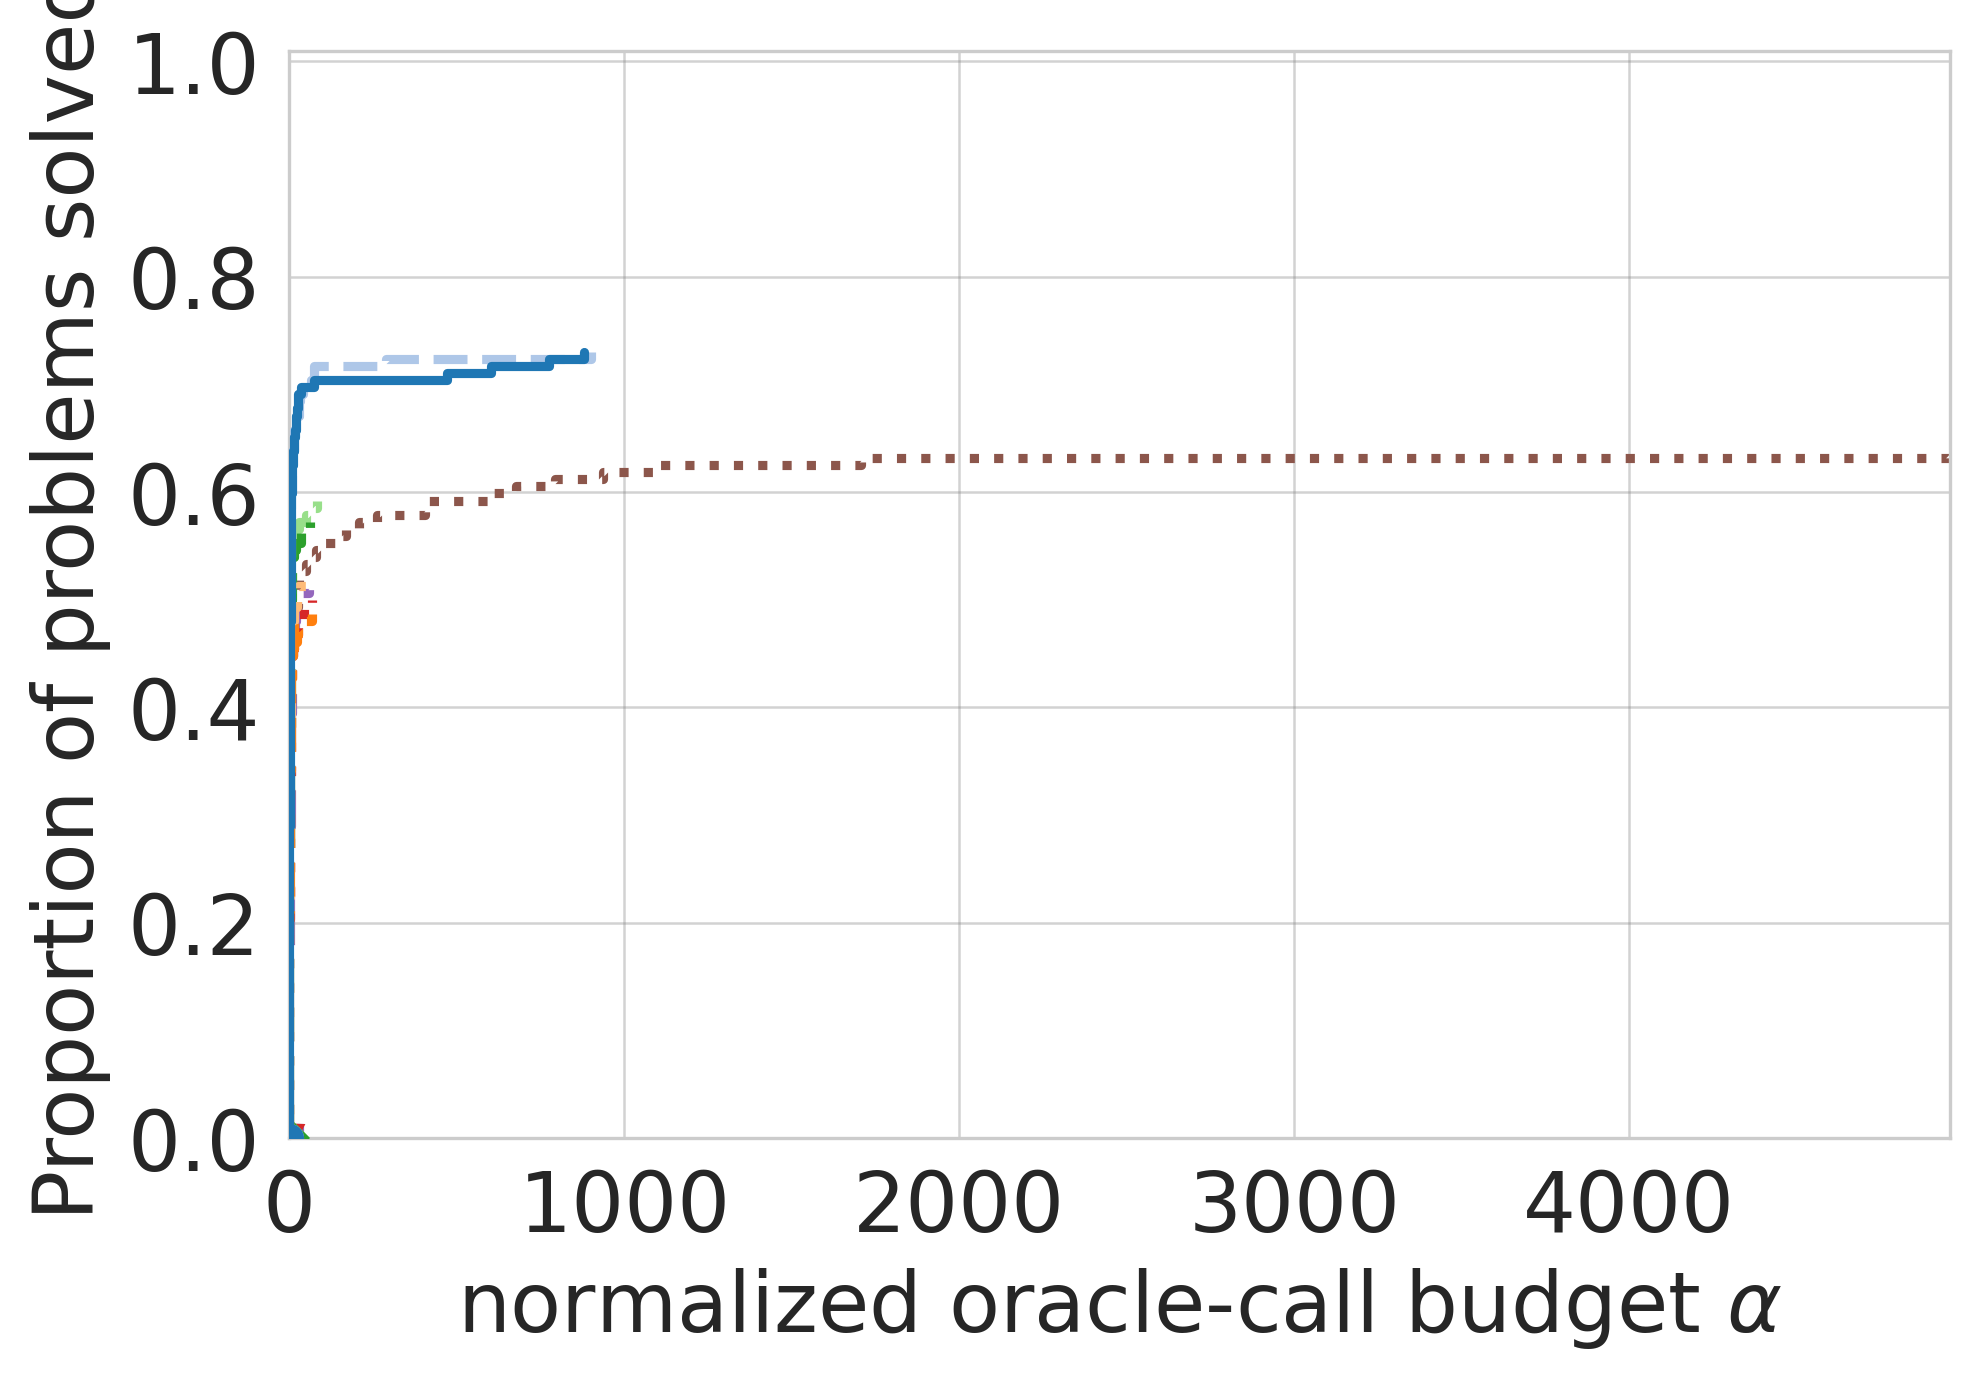

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),43.0,39.0,inf,inf,inf,inf,inf,inf,2811.0
ALLINITU (seed=0),21.0,19.0,inf,20.0,20.0,20.0,inf,24.0,37.0
ARGLINA (seed=0),8.0,8.0,8.0,8.0,12.0,12.0,8.0,5.0,8.0
ARGTRIGLS (seed=0),147.0,175.0,158.0,188.0,154.0,158.0,158.0,174.0,inf
ARWHEAD (seed=0),10.0,8.0,8.0,8.0,8.0,8.0,8.0,27.0,16.0
...,...,...,...,...,...,...,...,...,...
WATSON (seed=0),42.0,53.0,38.0,42.0,38.0,38.0,38.0,65.0,1993.0
WOODS (seed=0),43.0,50.0,inf,inf,48.0,48.0,inf,inf,810.0
YATP2LS (seed=0),inf,inf,54.0,54.0,42.0,42.0,inf,inf,1167.0
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,73.026316,26.315789
NTRQN-MS,73.026316,29.605263
Line,48.684211,11.842105
Line-MS,51.973684,12.500000
Reg,57.236842,8.552632
Reg-Sec,59.210526,8.552632
SciPy,50.000000,12.500000
NTQN,51.315789,19.078947
ASTR1-Adagrad,63.815789,19.078947


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,152,0,150,2,0,106
NTRQN-MS,152,0,150,2,0,106
Line,152,0,152,0,0,140
Line-MS,152,0,152,0,0,143
Reg,152,0,146,1,5,122
Reg-Sec,152,0,151,1,0,125
SciPy,152,0,151,1,0,83
NTQN,152,0,152,0,0,0
ASTR1-Adagrad,152,0,150,2,0,123


flag,0,6
method,,
NTQN,25,127


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-03.pdf


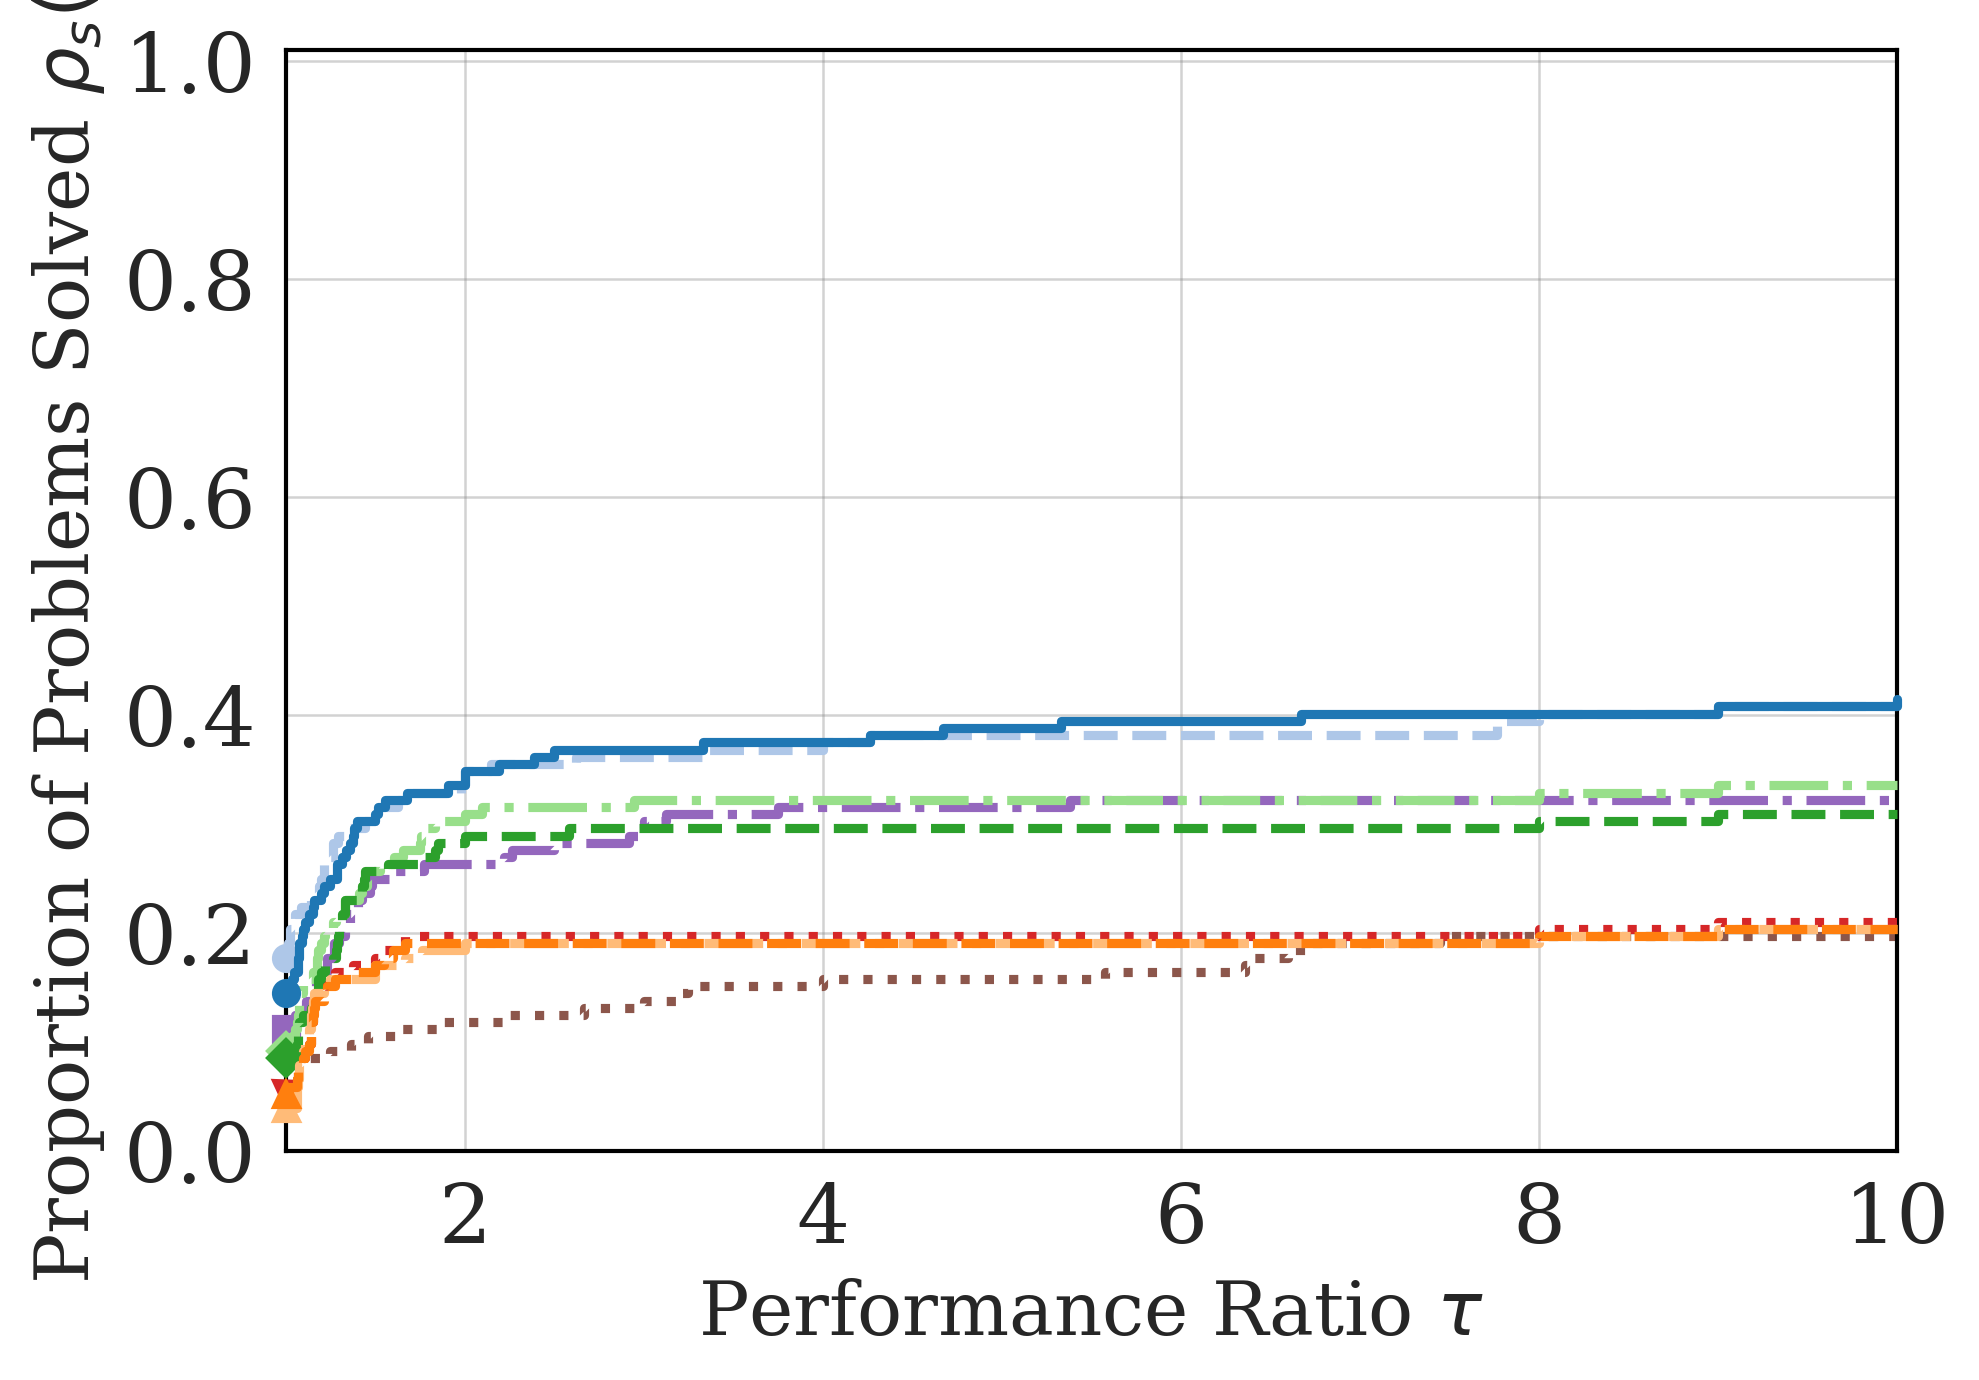

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-03.pdf


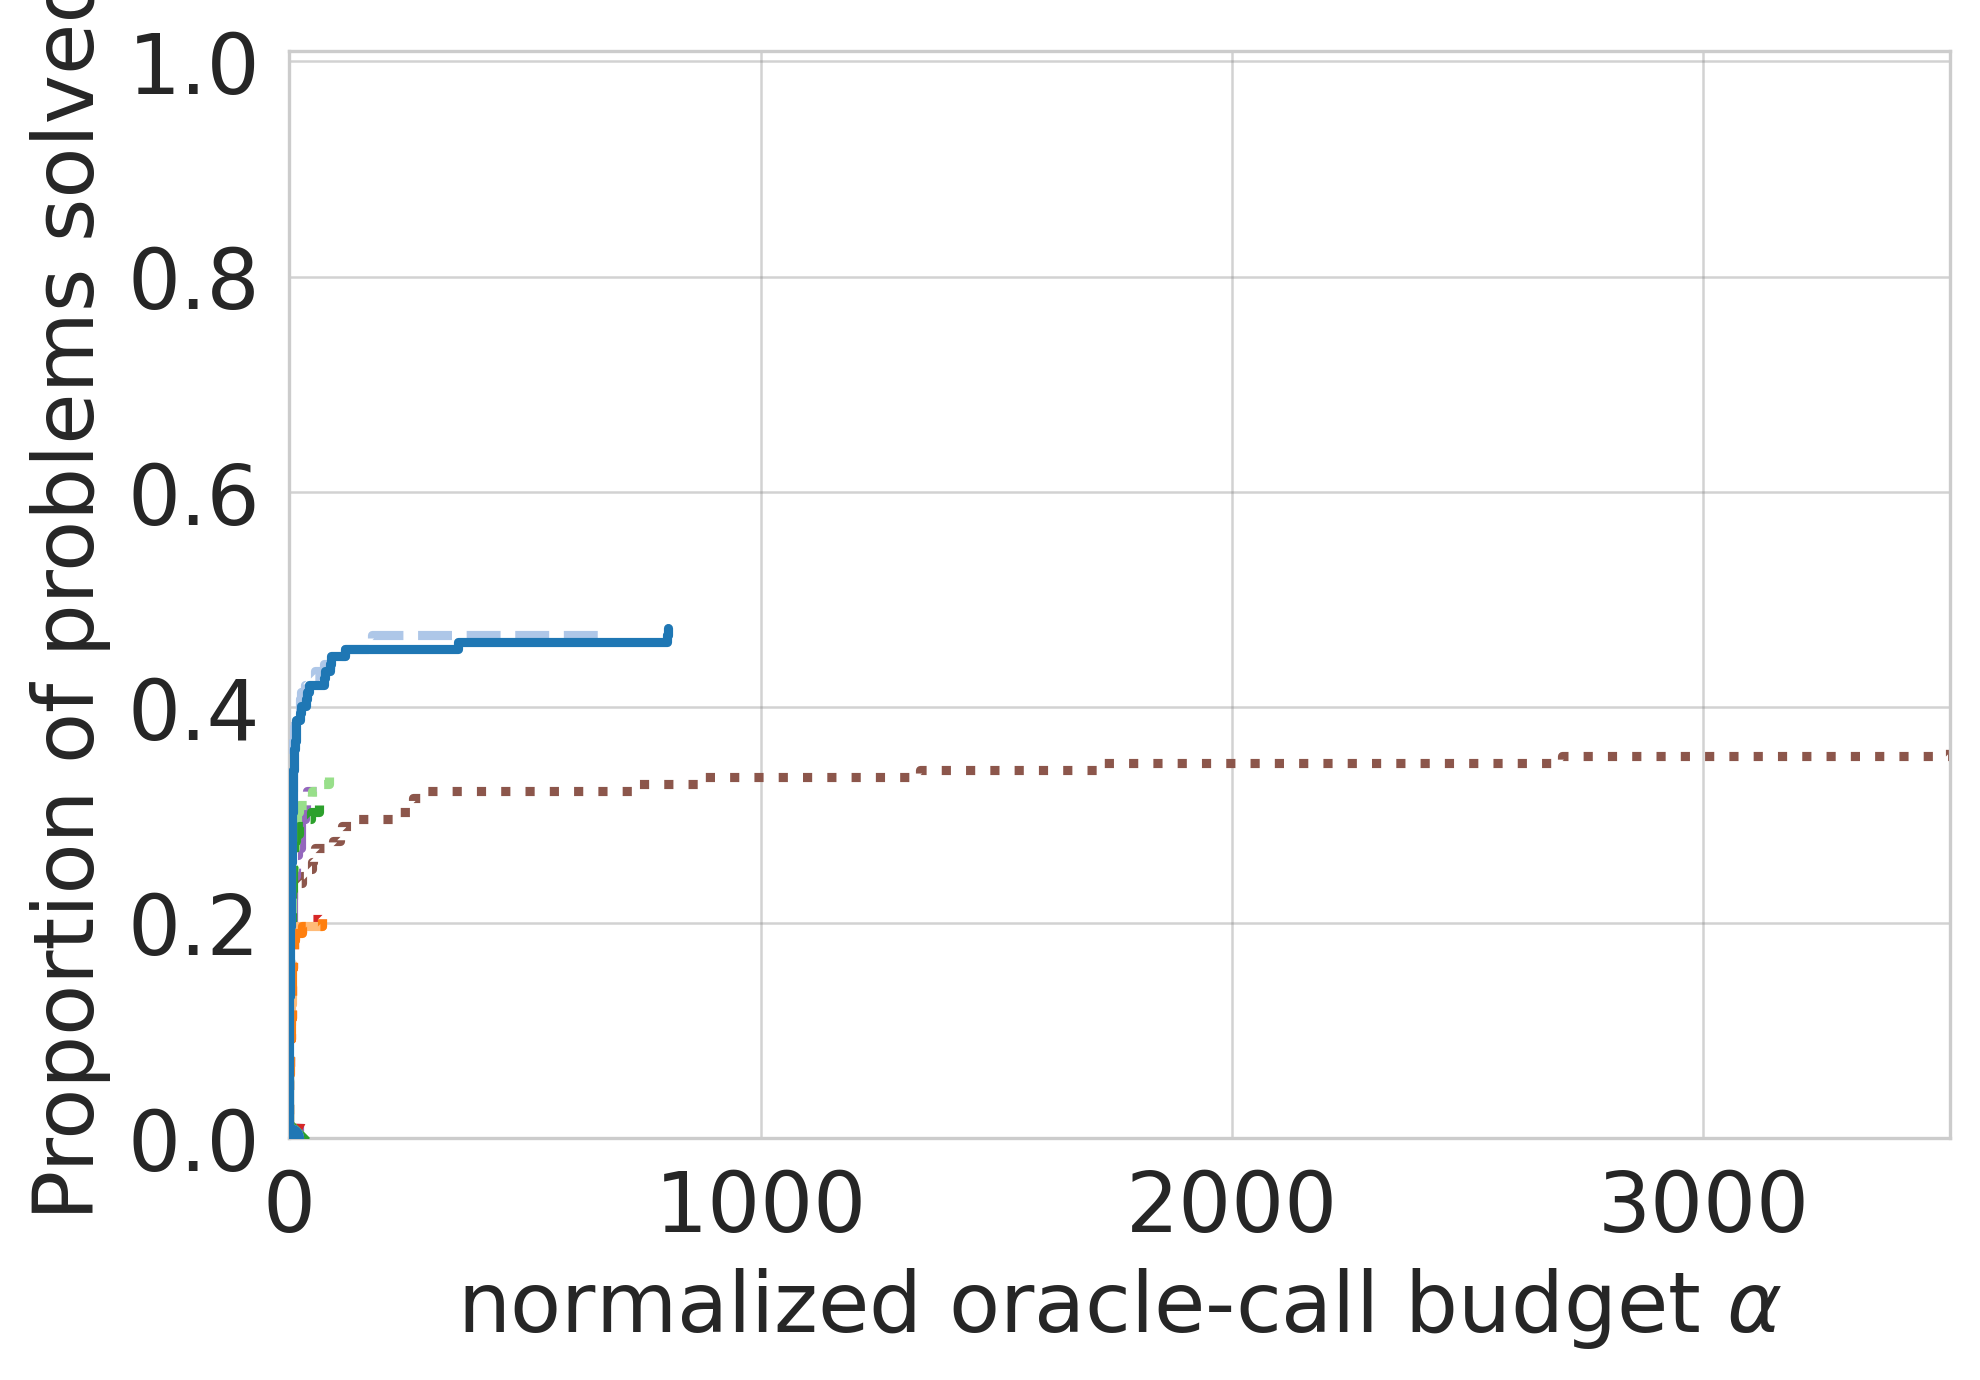

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINA (seed=0),10.0,10.0,8.0,10.0,inf,inf,8.0,5.0,15.0
ARGTRIGLS (seed=0),1295.0,1365.0,inf,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),12.0,8.0,inf,inf,8.0,8.0,inf,30.0,26.0
...,...,...,...,...,...,...,...,...,...
WATSON (seed=0),inf,8593.0,inf,inf,inf,inf,inf,454.0,inf
WOODS (seed=0),inf,4911.0,inf,inf,inf,inf,inf,inf,inf
YATP2LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,47.368421,14.473684
NTRQN-MS,47.368421,17.763158
Line,20.394737,5.263158
Line-MS,20.394737,3.947368
Reg,30.921053,8.552632
Reg-Sec,33.552632,9.210526
SciPy,21.052632,5.263158
NTQN,32.894737,11.184211
ASTR1-Adagrad,36.184211,8.552632


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,152,0,150,2,0,106
NTRQN-MS,152,0,150,2,0,106
Line,152,0,152,0,0,140
Line-MS,152,0,152,0,0,143
Reg,152,0,146,1,5,122
Reg-Sec,152,0,151,1,0,125
SciPy,152,0,151,1,0,83
NTQN,152,0,152,0,0,0
ASTR1-Adagrad,152,0,150,2,0,123


flag,0,6
method,,
NTQN,25,127


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-05.pdf


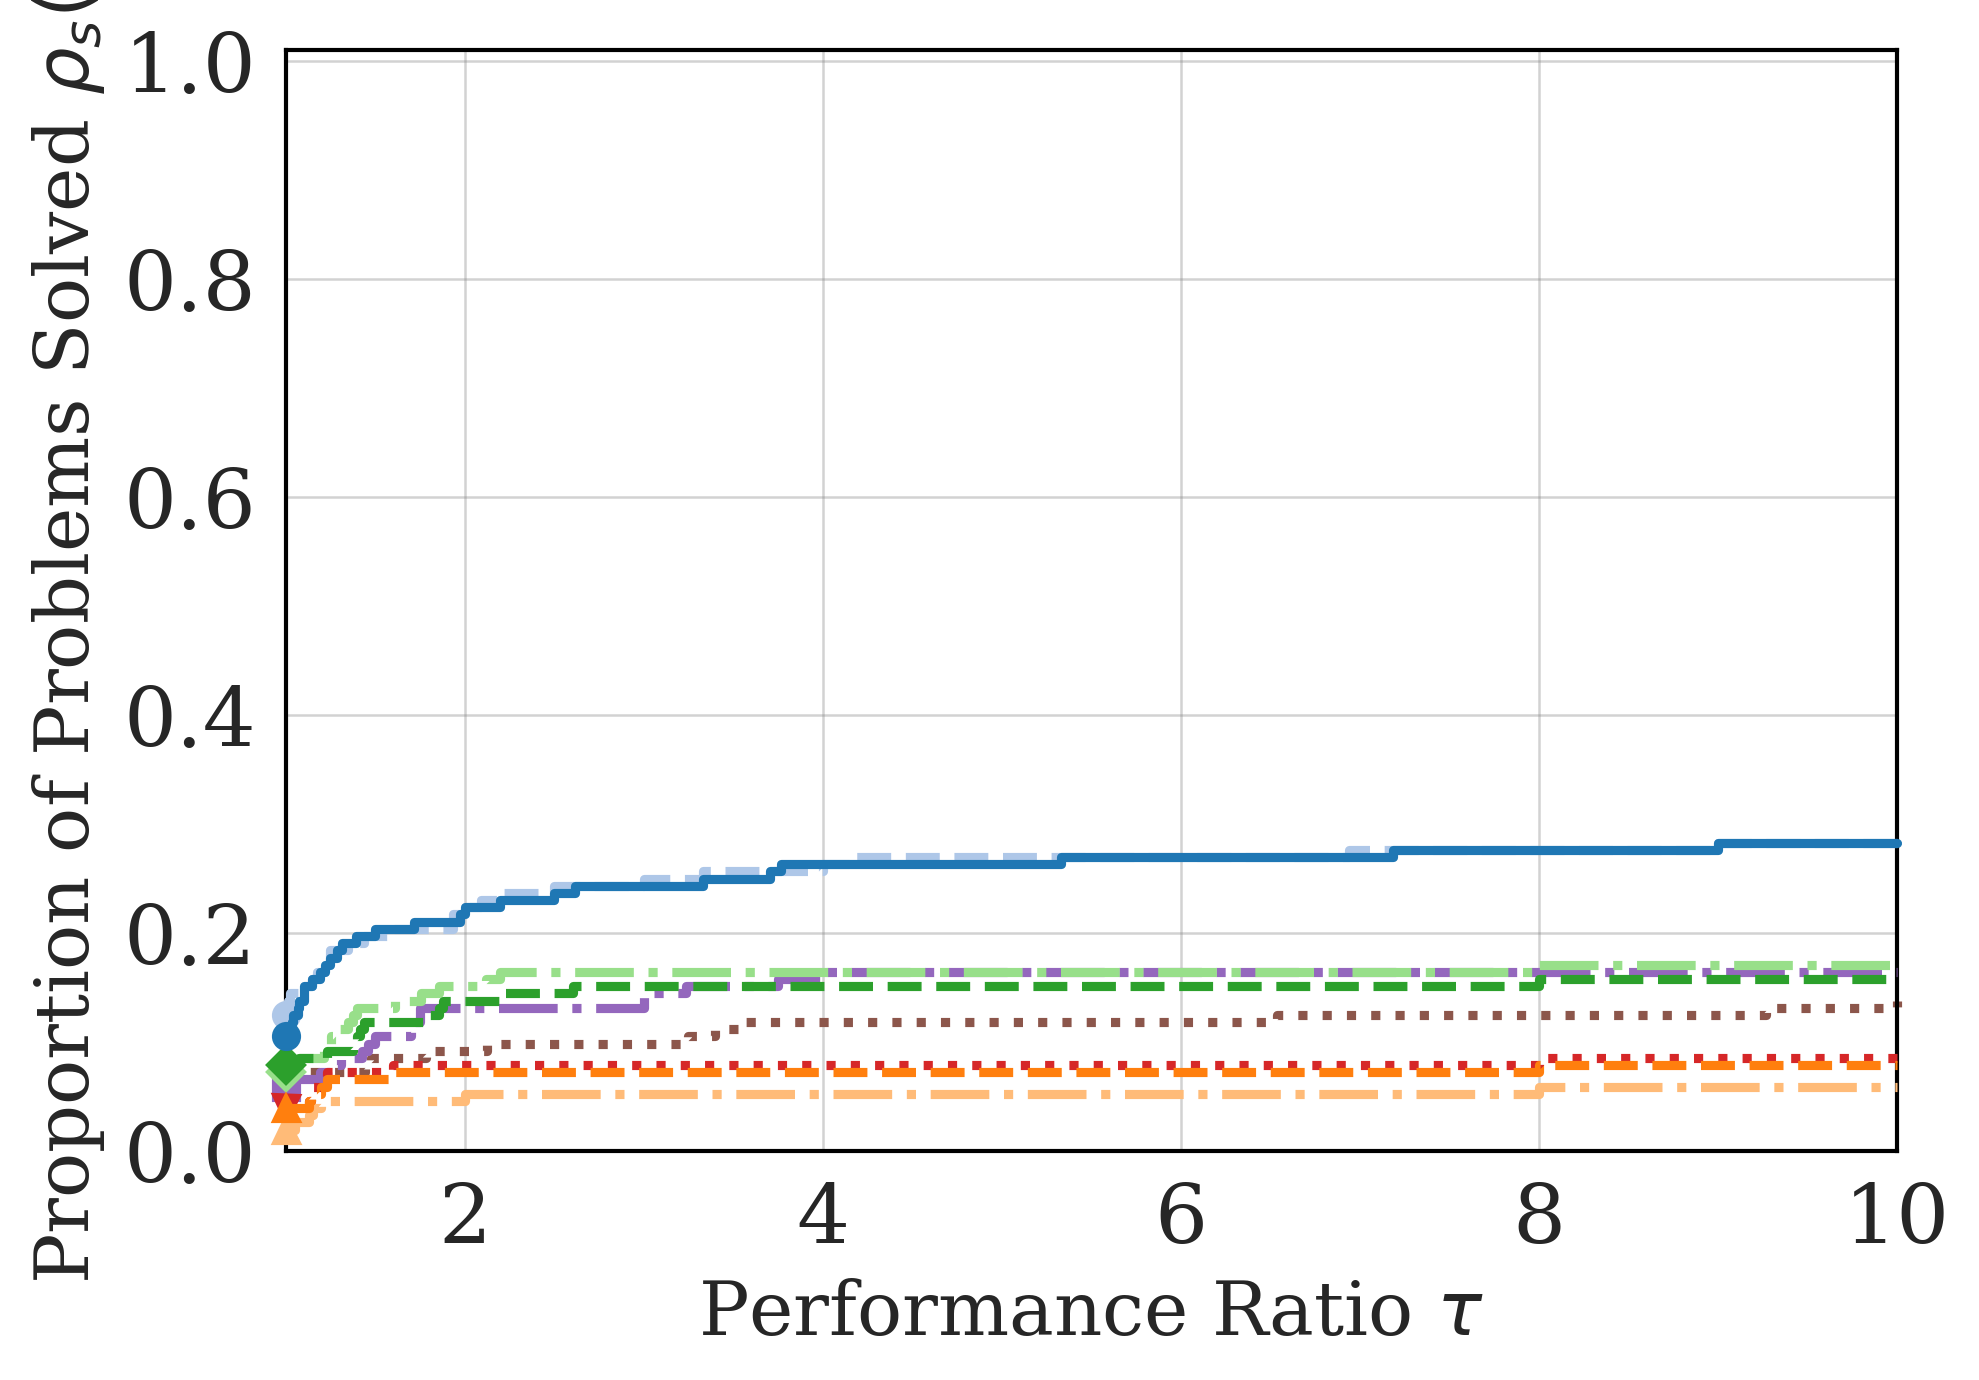

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-05.pdf


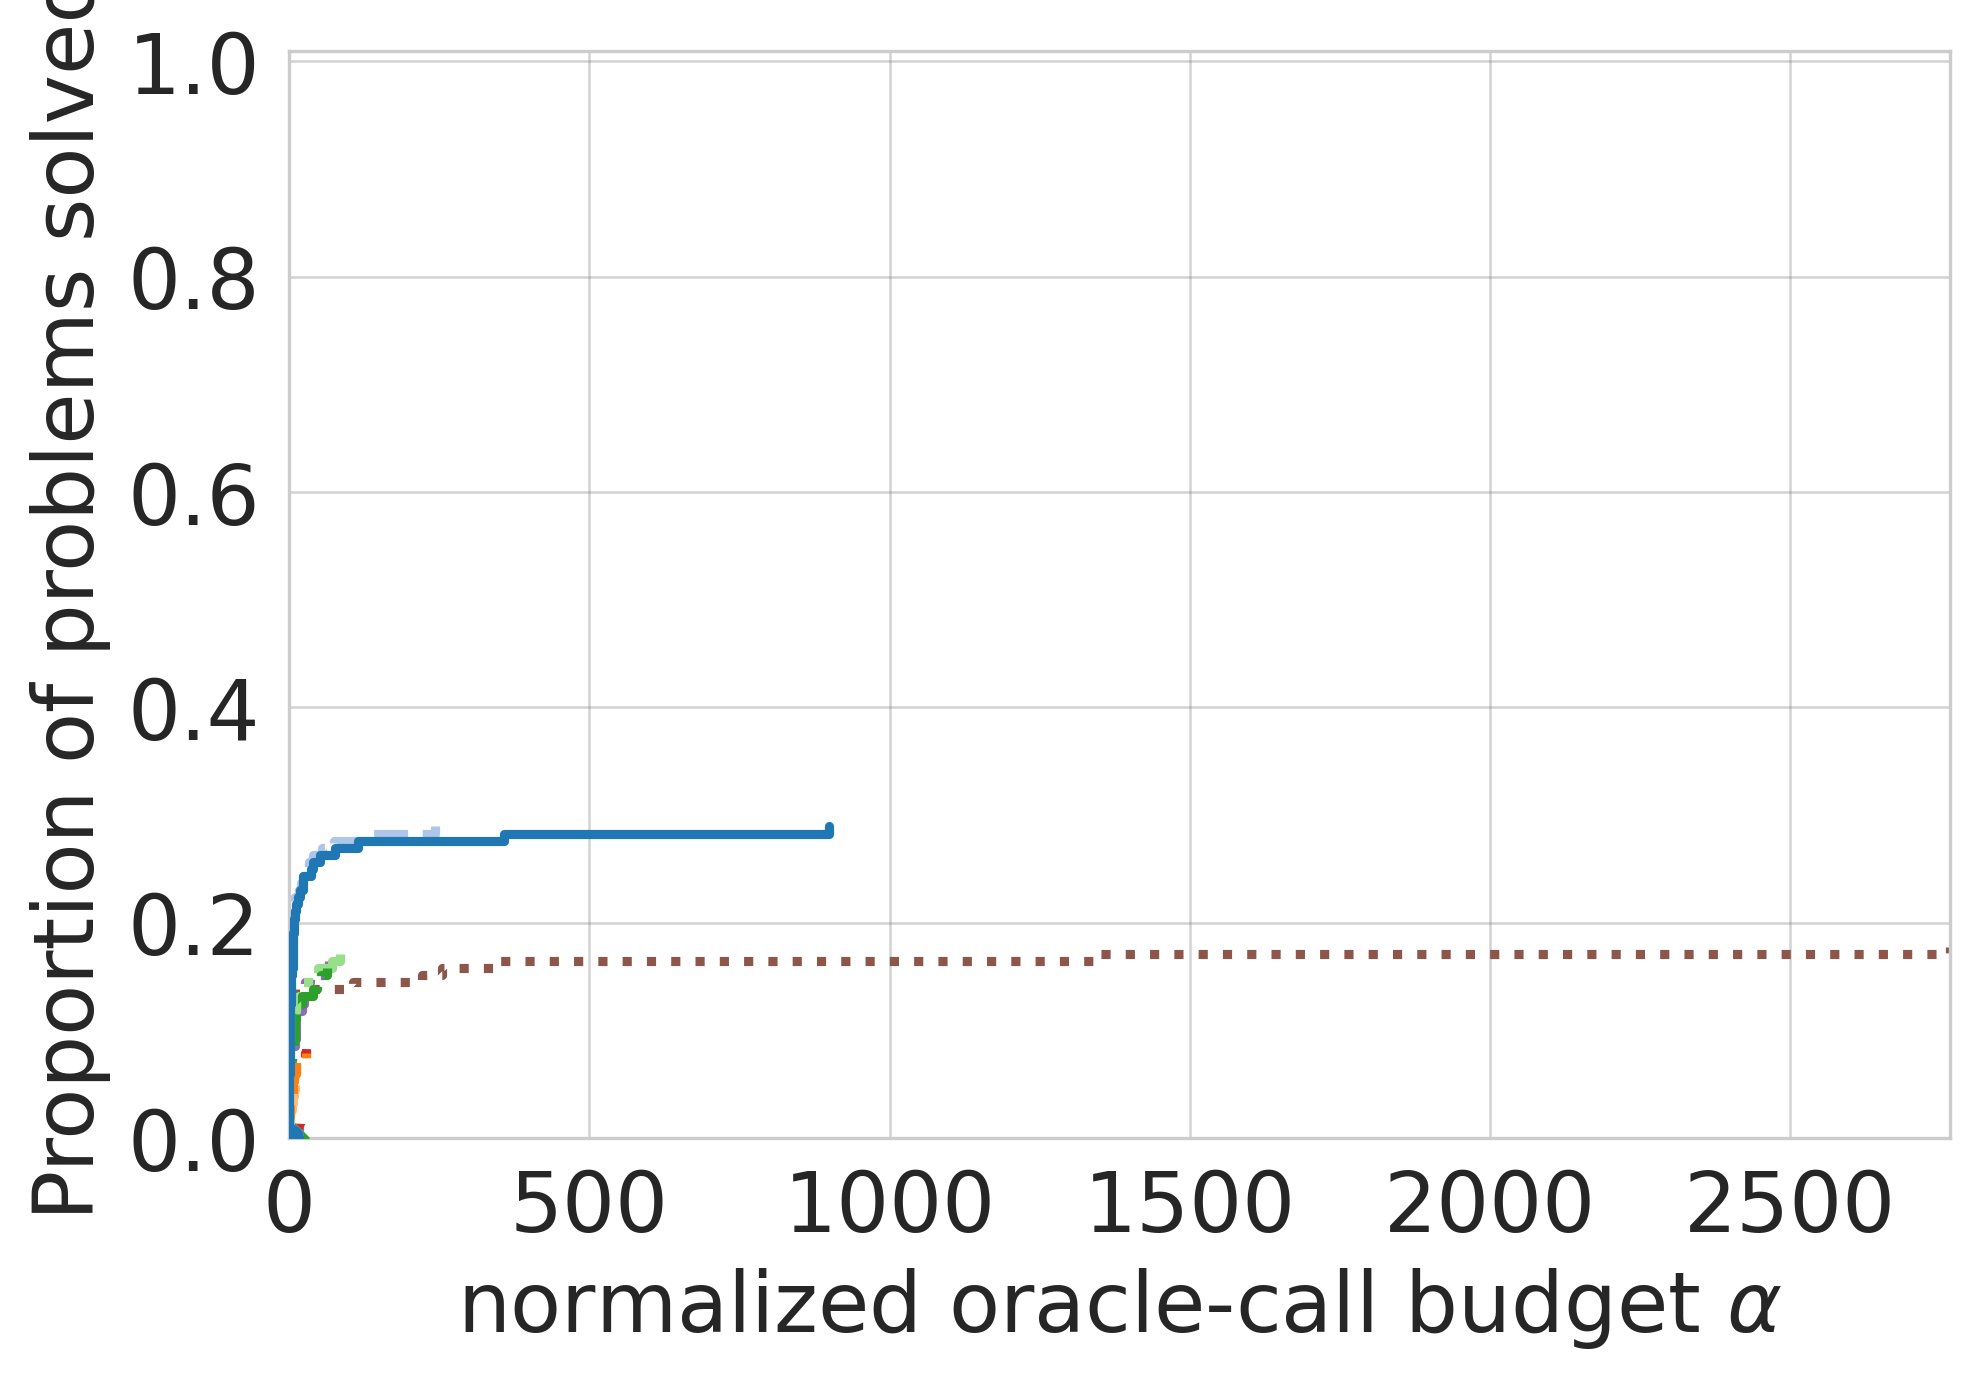

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINA (seed=0),10.0,10.0,8.0,10.0,inf,inf,8.0,5.0,17.0
ARGTRIGLS (seed=0),3680.0,3343.0,inf,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),12.0,8.0,inf,inf,8.0,8.0,inf,30.0,26.0
...,...,...,...,...,...,...,...,...,...
WATSON (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
WOODS (seed=0),inf,4911.0,inf,inf,inf,inf,inf,inf,inf
YATP2LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,28.947368,10.526316
NTRQN-MS,28.947368,12.500000
Line,7.894737,3.947368
Line-MS,5.921053,1.973684
Reg,15.789474,7.894737
Reg-Sec,17.105263,7.236842
SciPy,8.552632,3.947368
NTQN,16.447368,5.921053
ASTR1-Adagrad,17.763158,7.236842


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,152,0,150,2,0,106
NTRQN-MS,152,0,150,2,0,106
Line,152,0,152,0,0,140
Line-MS,152,0,152,0,0,143
Reg,152,0,146,1,5,122
Reg-Sec,152,0,151,1,0,125
SciPy,152,0,151,1,0,83
NTQN,152,0,152,0,0,0
ASTR1-Adagrad,152,0,150,2,0,123


flag,0,6
method,,
NTQN,25,127


Saved figure to doc/imgs/compare/_pp_function_only_gtol1e-02.pdf


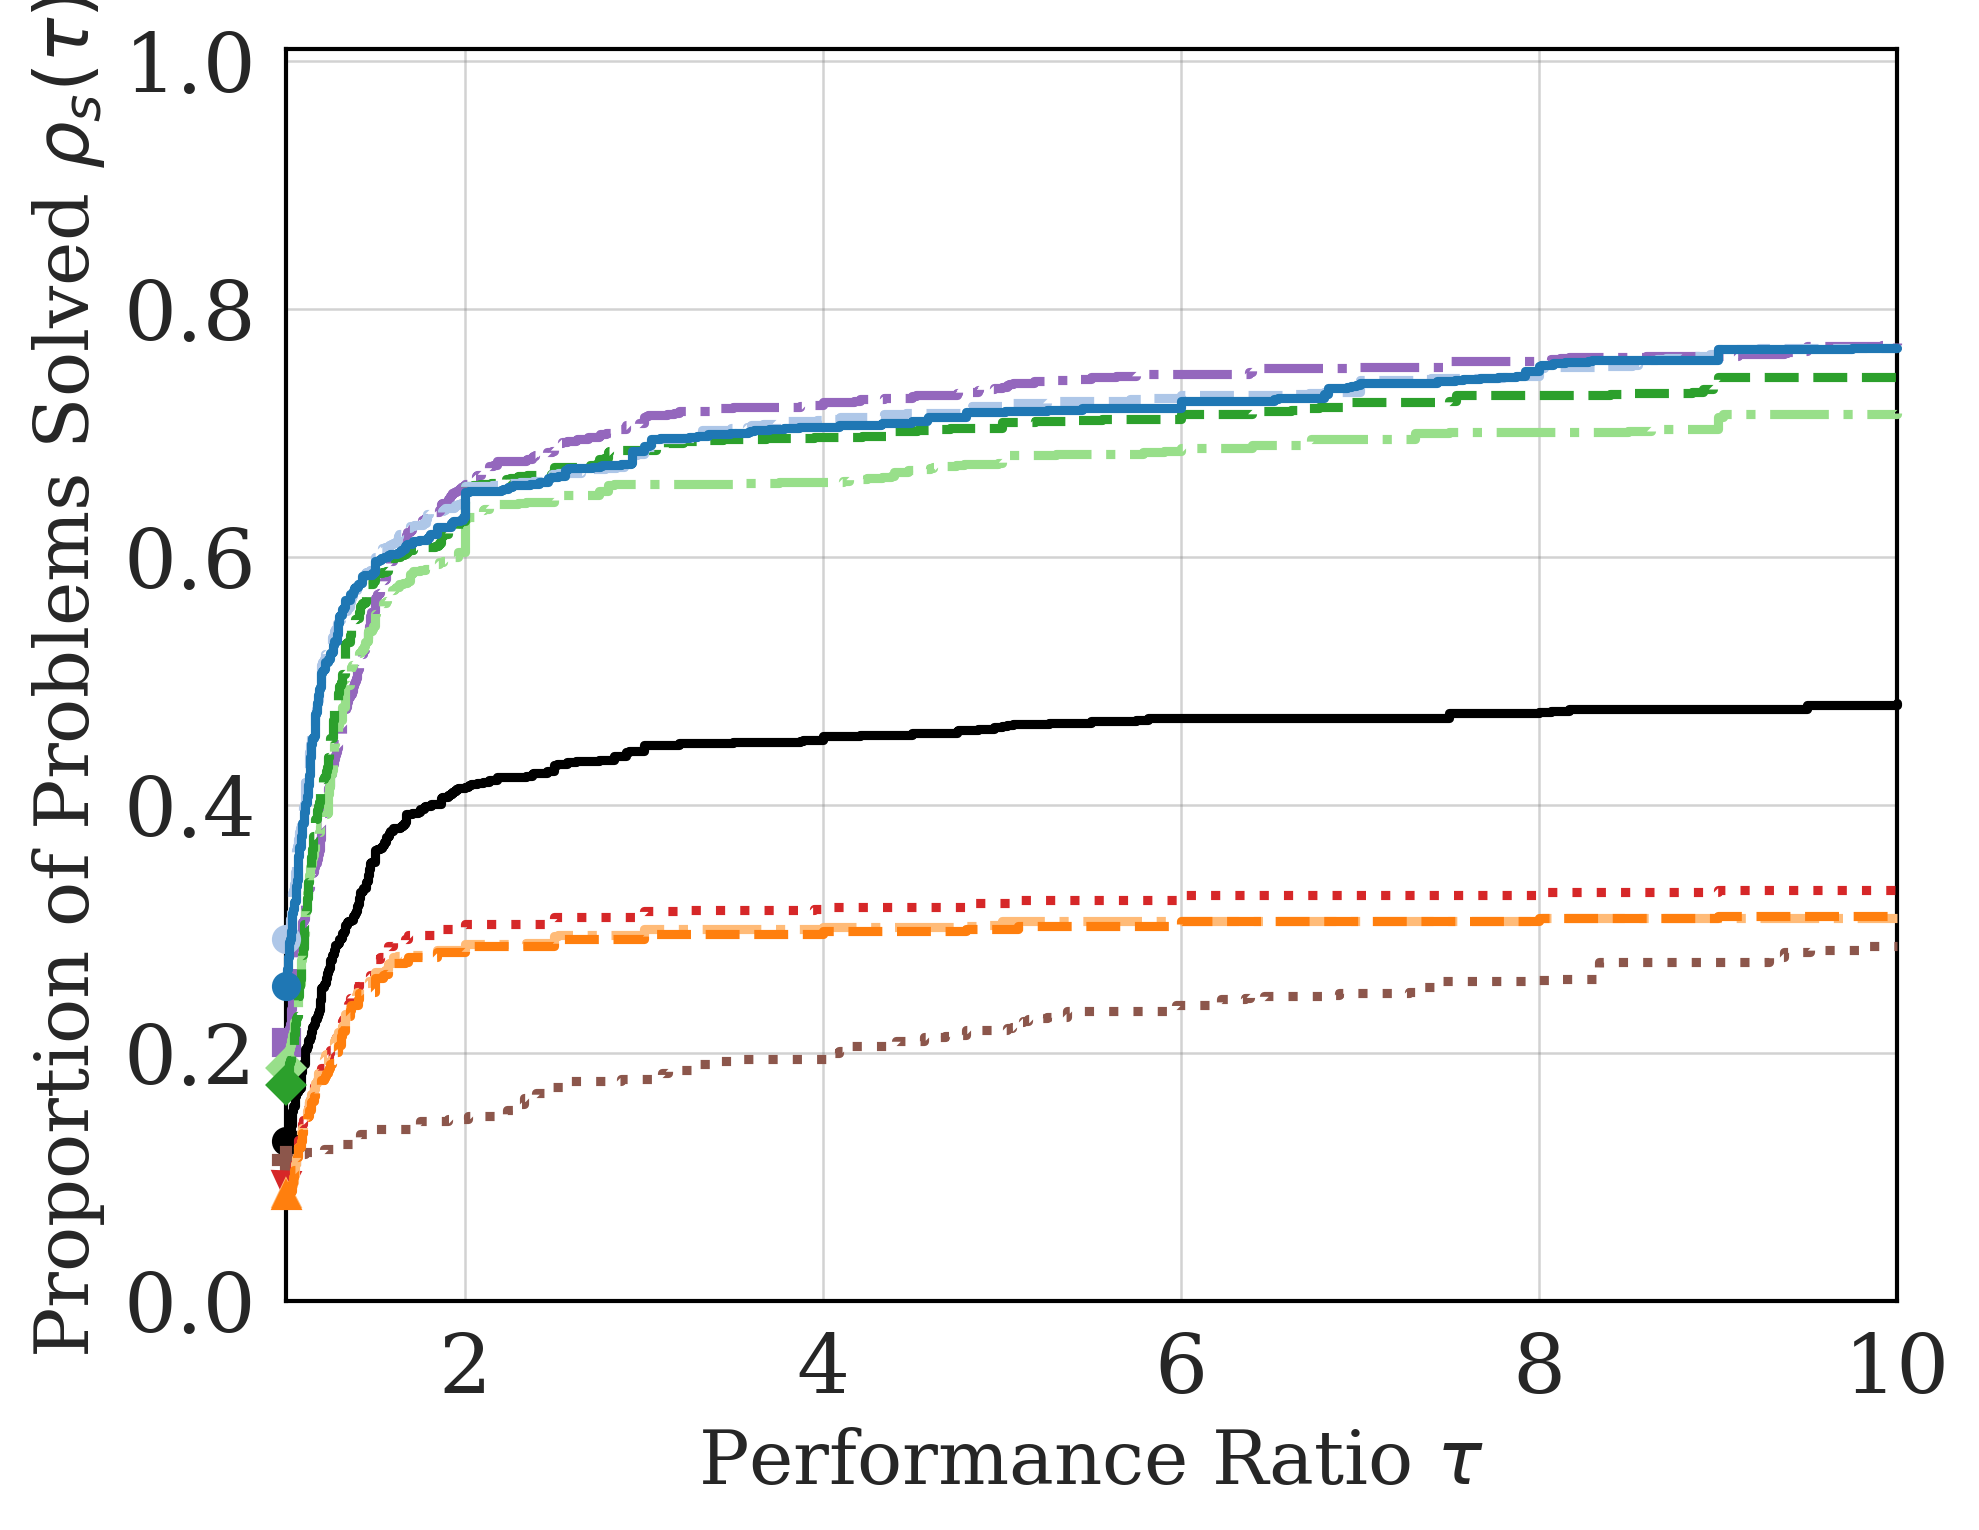

Saved figure to doc/imgs/compare/_dp_function_only_gtol1e-02.pdf


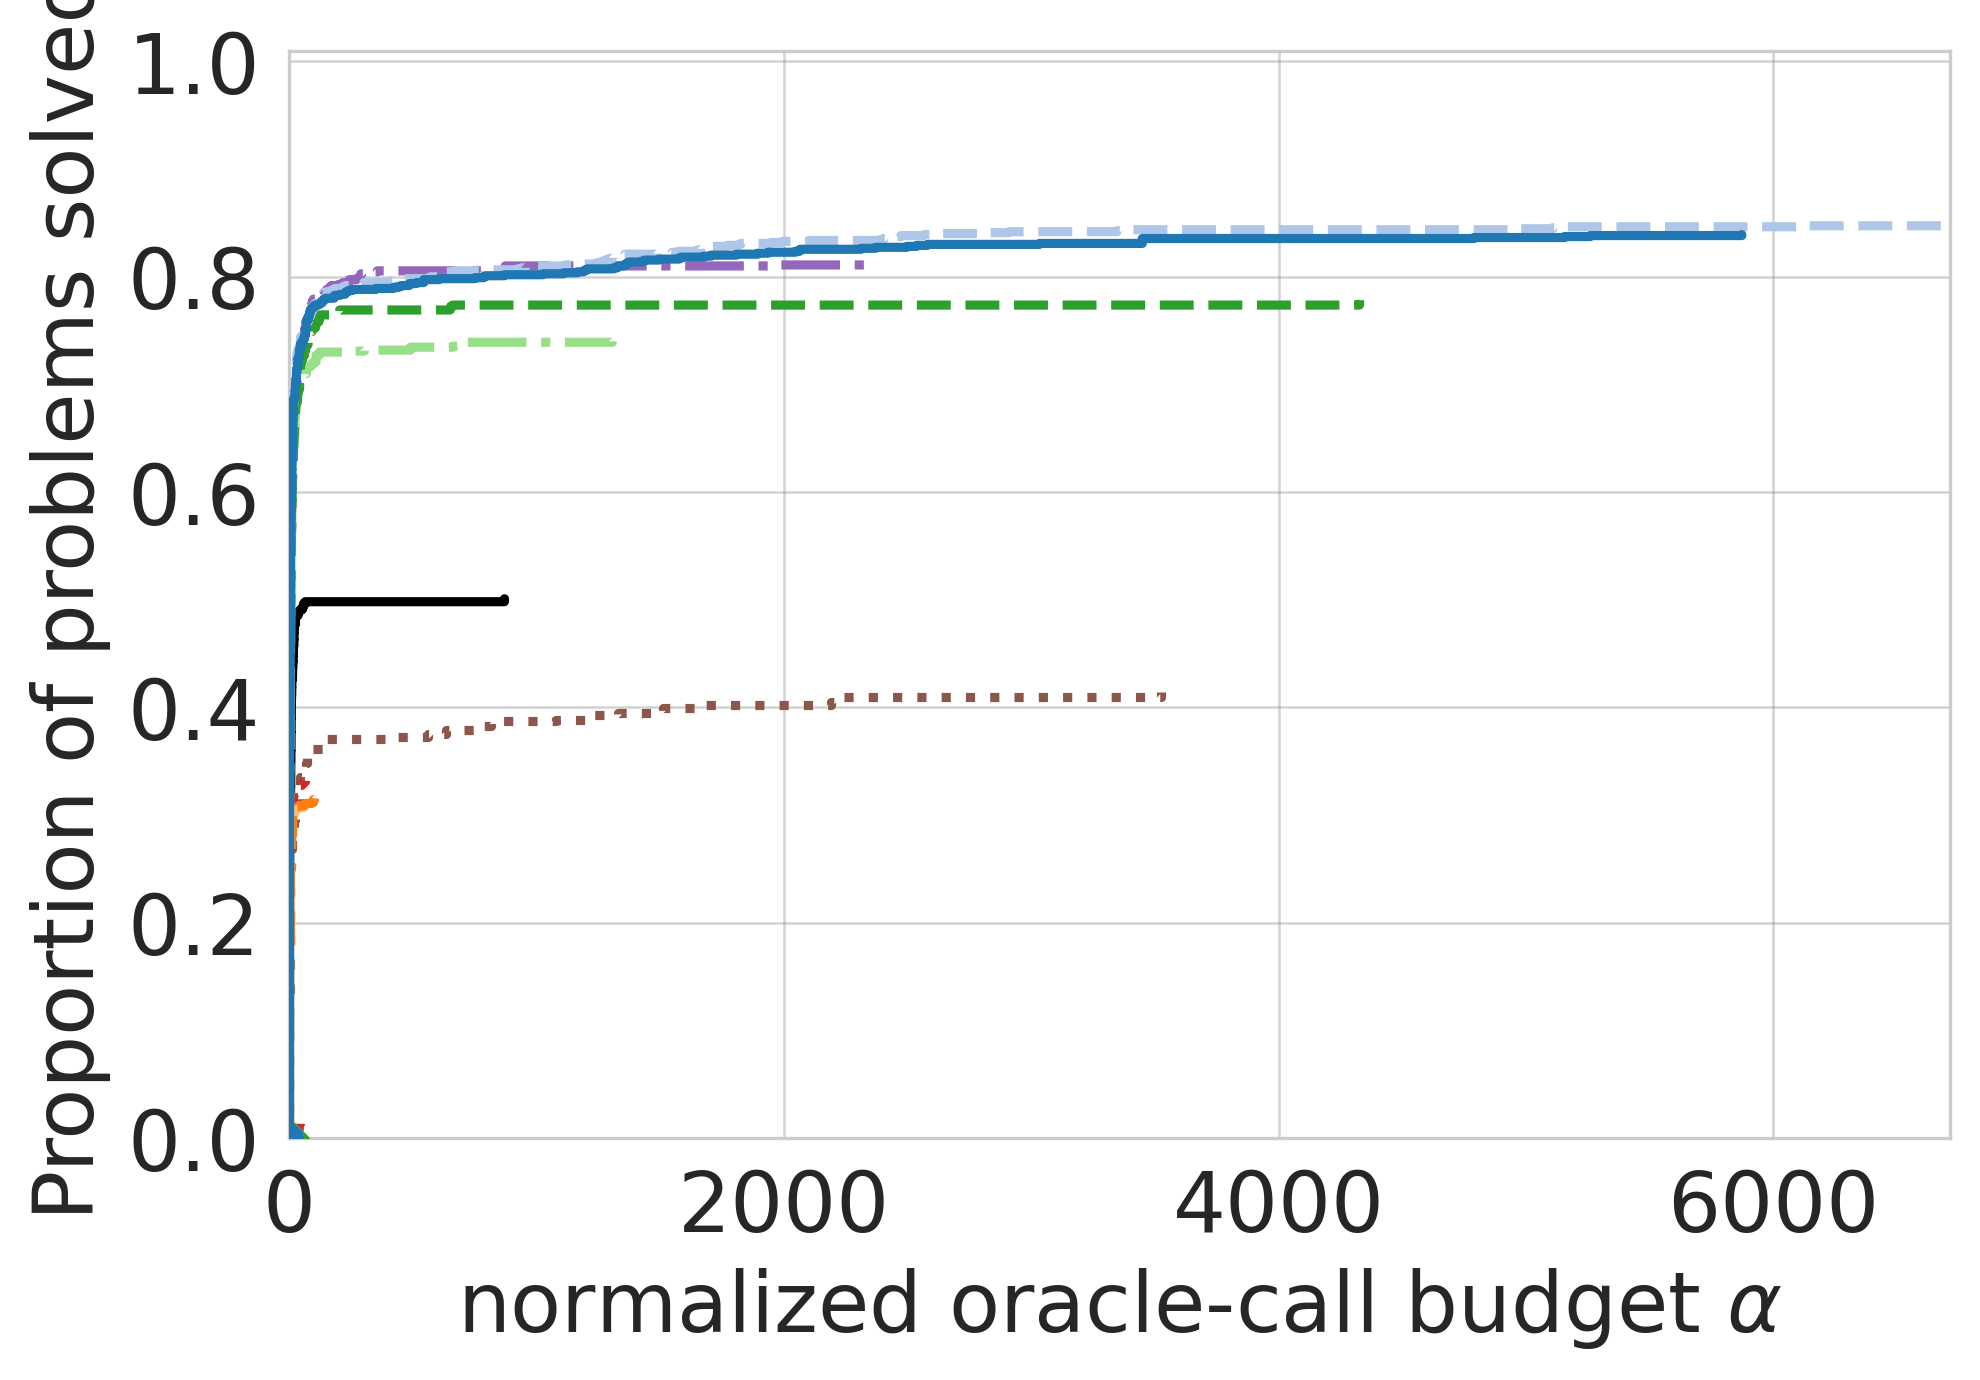

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad,NTQN-Default-Termination
AKIVA (seed=0),35.0,49.0,inf,inf,47.0,47.0,inf,inf,4924.0,inf
ALLINITU (seed=0),23.0,25.0,22.0,24.0,20.0,22.0,22.0,23.0,49.0,23.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,14.0,14.0,8.0,5.0,12.0,5.0
ARGLINB (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0,42.0
ARGLINC (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0,42.0
...,...,...,...,...,...,...,...,...,...,...
WOODS (seed=4),42.0,38.0,inf,inf,48.0,48.0,58.0,71.0,inf,71.0
YATP1LS (seed=4),140.0,153.0,inf,inf,46.0,46.0,inf,77.0,inf,77.0
YATP2LS (seed=4),inf,inf,48.0,48.0,51.0,51.0,48.0,26.0,inf,26.0
YFITU (seed=4),262.0,150.0,inf,inf,192.0,257.0,inf,206.0,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,83.909091,25.454545
NTRQN-MS,84.818182,29.181818
Line,31.545455,8.545455
Line-MS,31.272727,8.727273
Reg,77.818182,17.454545
Reg-Sec,74.000000,18.818182
SciPy,33.636364,9.363636
NTQN,81.181818,20.909091
ASTR1-Adagrad,41.454545,11.363636
NTQN-Default-Termination,50.090909,12.909091


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,1100,0,1090,10,0,167
NTRQN-MS,1100,0,1090,10,0,157
Line,1100,0,1100,0,0,753
Line-MS,1100,0,1100,0,0,757
Reg,1100,0,1088,5,7,232
Reg-Sec,1100,0,1096,4,0,282
SciPy,1100,0,1100,0,0,0
NTQN,1100,0,1095,5,0,5
ASTR1-Adagrad,1100,0,1083,17,0,627


flag,0,2,4,6
method,,,,
NTQN,892,5,0,198
NTQN-Default-Termination,450,0,619,31


,mean solved fraction,std. dev. across seeds
NTRQN,0.839091,0.005183
NTRQN-MS,0.848182,0.008257
Line,0.315455,0.010464
Line-MS,0.312727,0.015548
Reg,0.778182,0.011318
Reg-Sec,0.740000,0.008743
SciPy,0.336364,0.007187
NTQN,0.811818,0.014938
ASTR1-Adagrad,0.414545,0.012613
NTQN-Default-Termination,0.500909,0.006742


Saved figure to doc/imgs/compare/_pp_function_only_restart_gtol1e-02.pdf


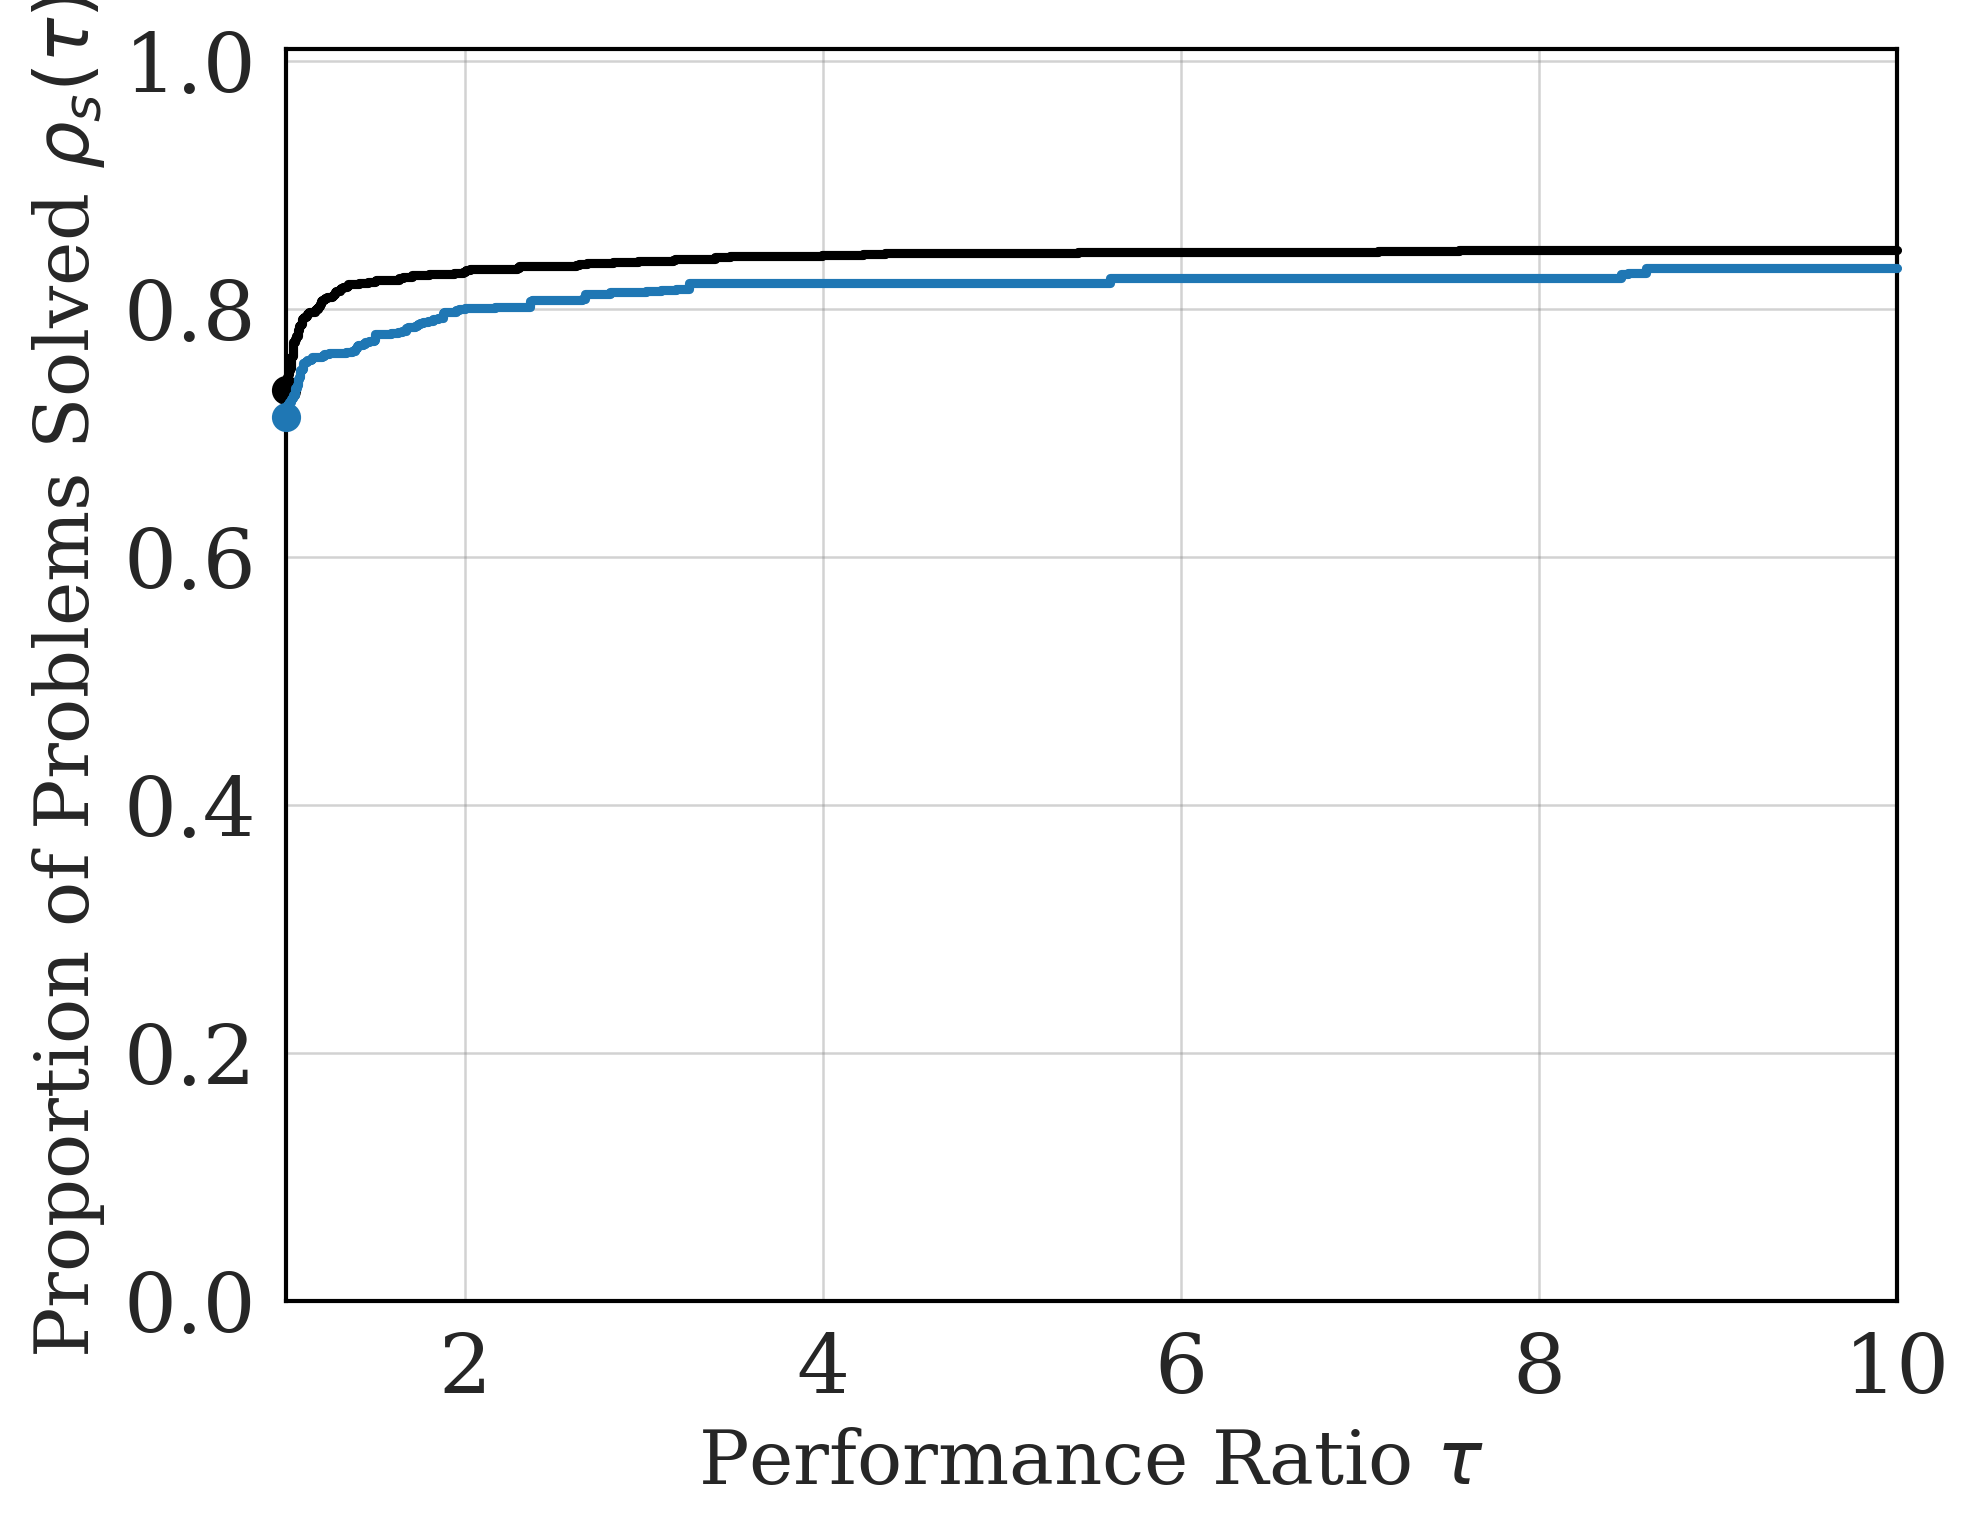

Saved figure to doc/imgs/compare/_dp_function_only_restart_gtol1e-02.pdf


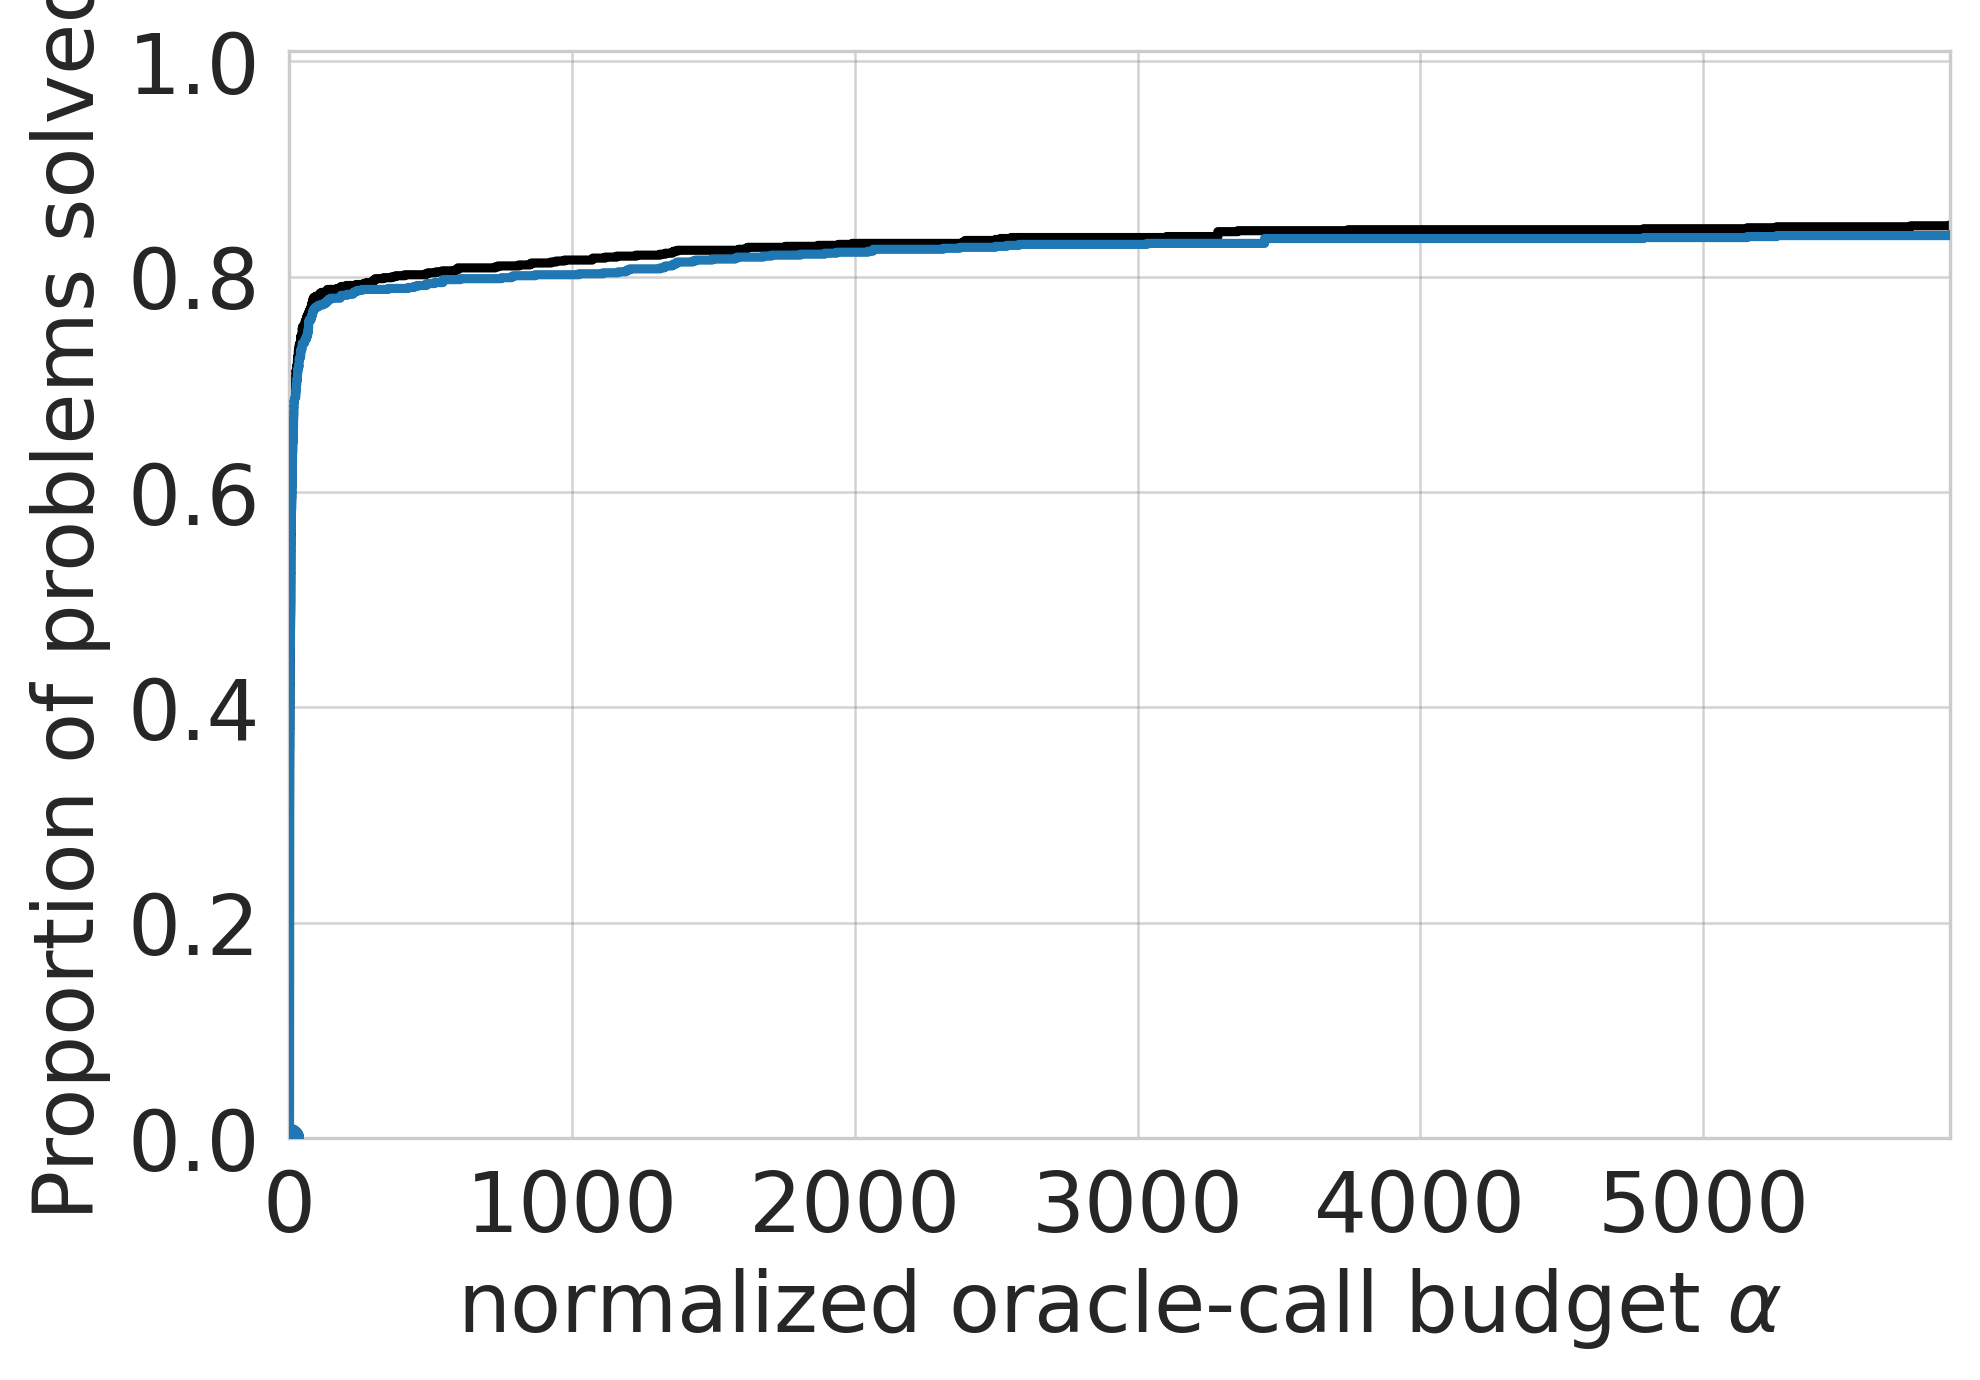

,solved (percent),"fastest, ties included (percent)"
NTRQN,83.909091,71.272727
NTRQN-Restart,84.818182,73.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,1100,0,1090,10,0,167
NTRQN-Restart,1100,0,1090,10,0,157


,mean,median,maximum,cap reached
method,,,,
NTRQN-Restart,1.53,0.0,10,65


Saved figure to doc/imgs/compare/_pp_noise0.001_gtol1e-02.pdf


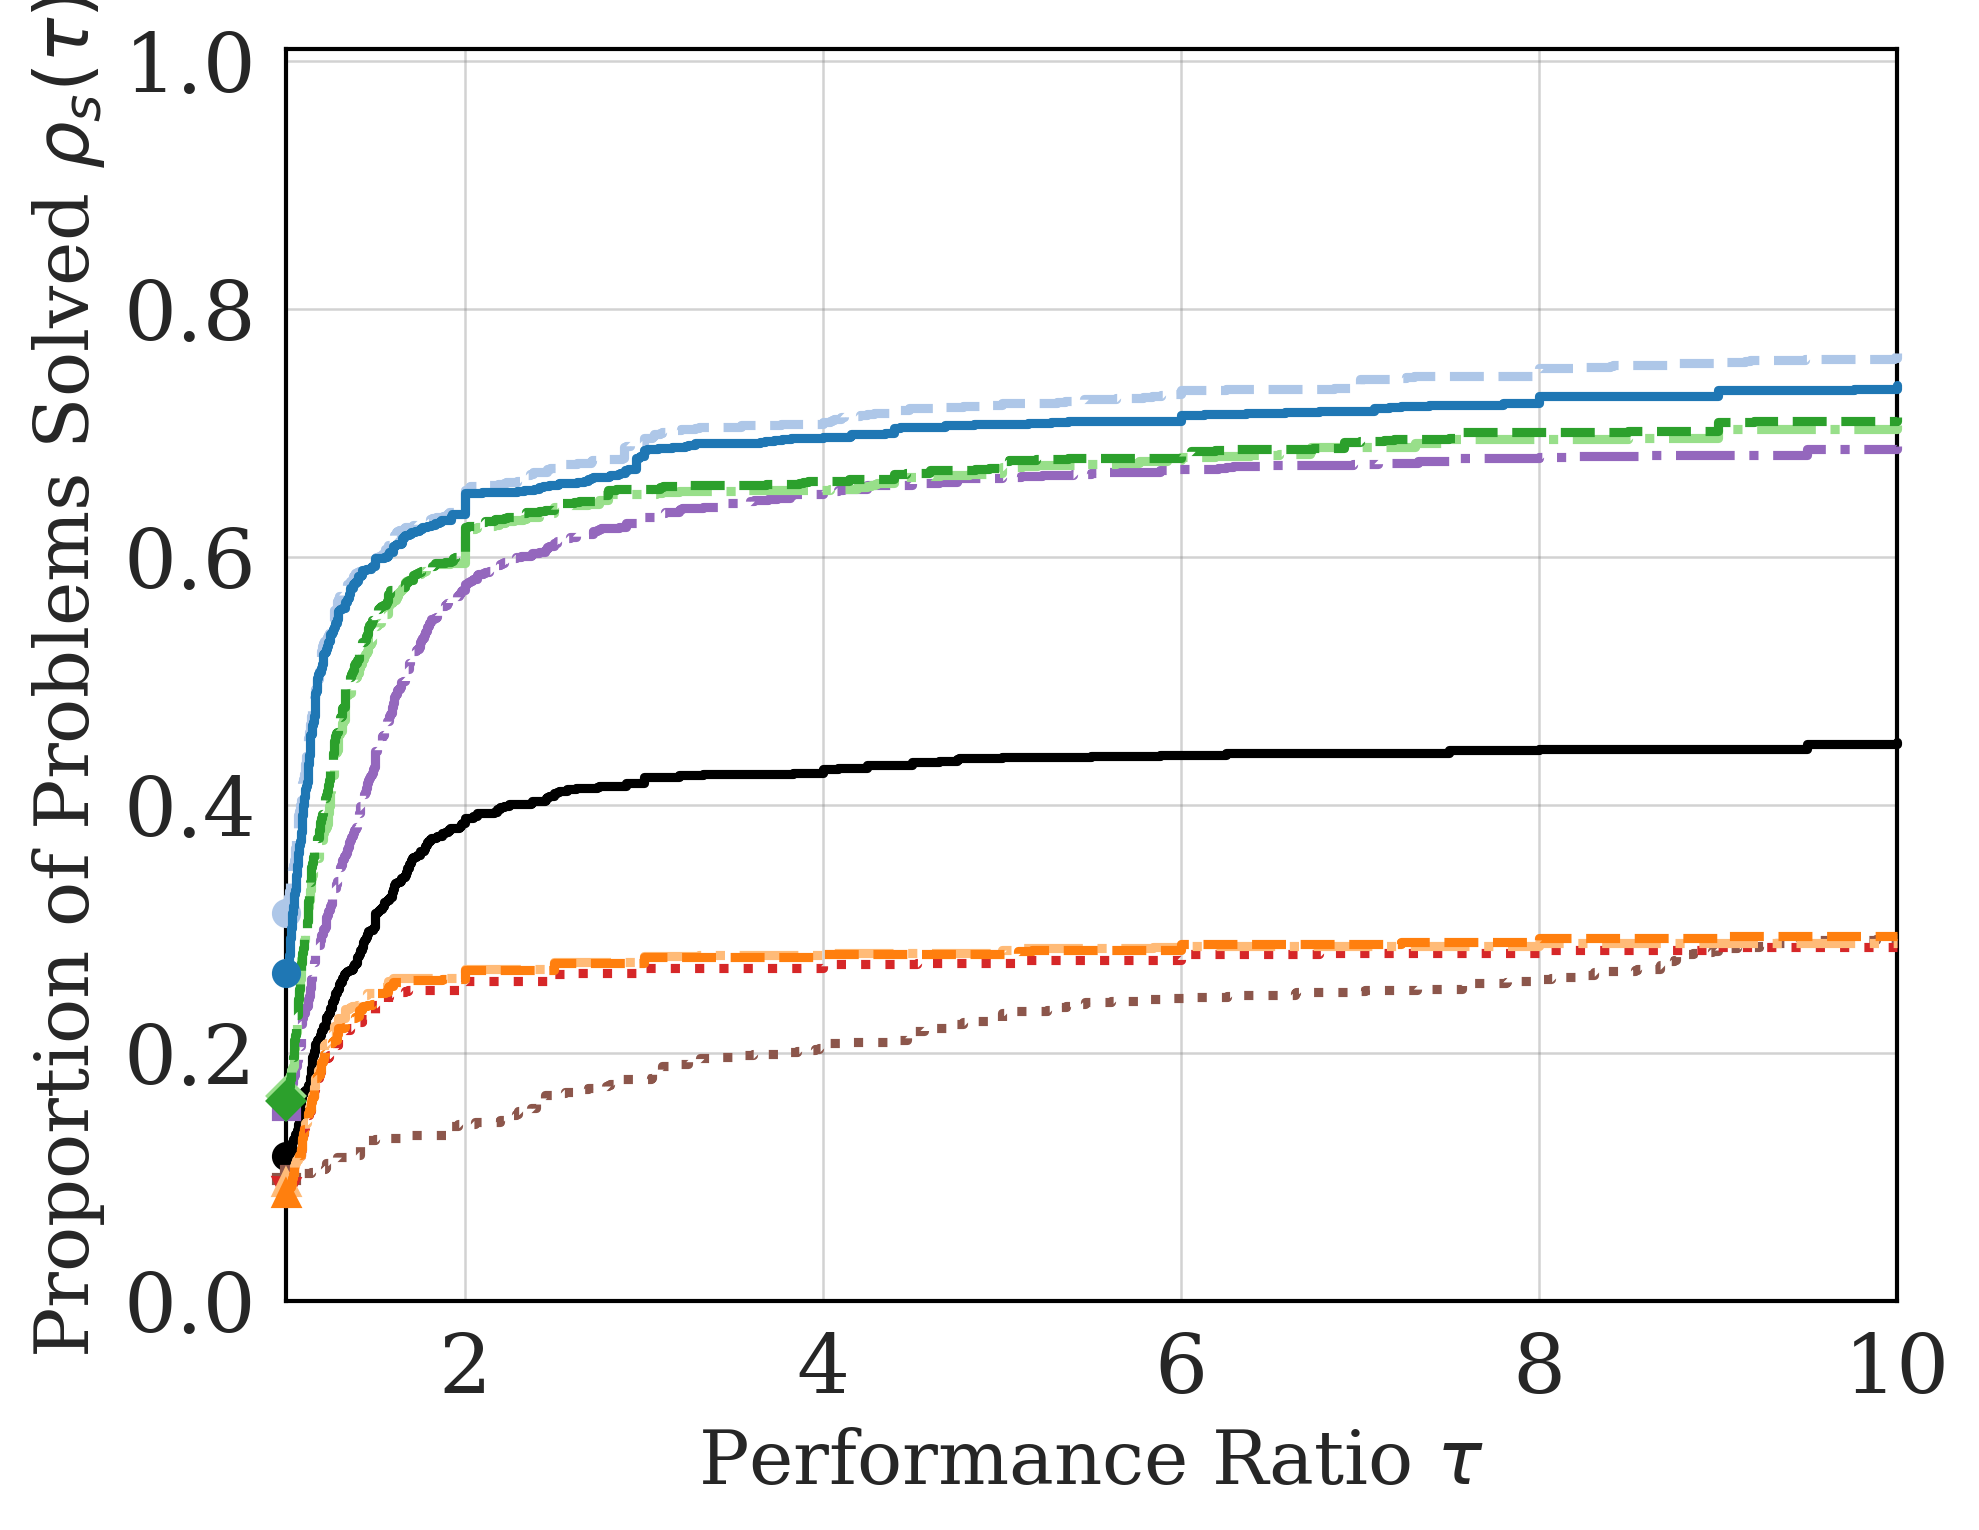

Saved figure to doc/imgs/compare/_dp_joint_noise_gtol1e-02.pdf


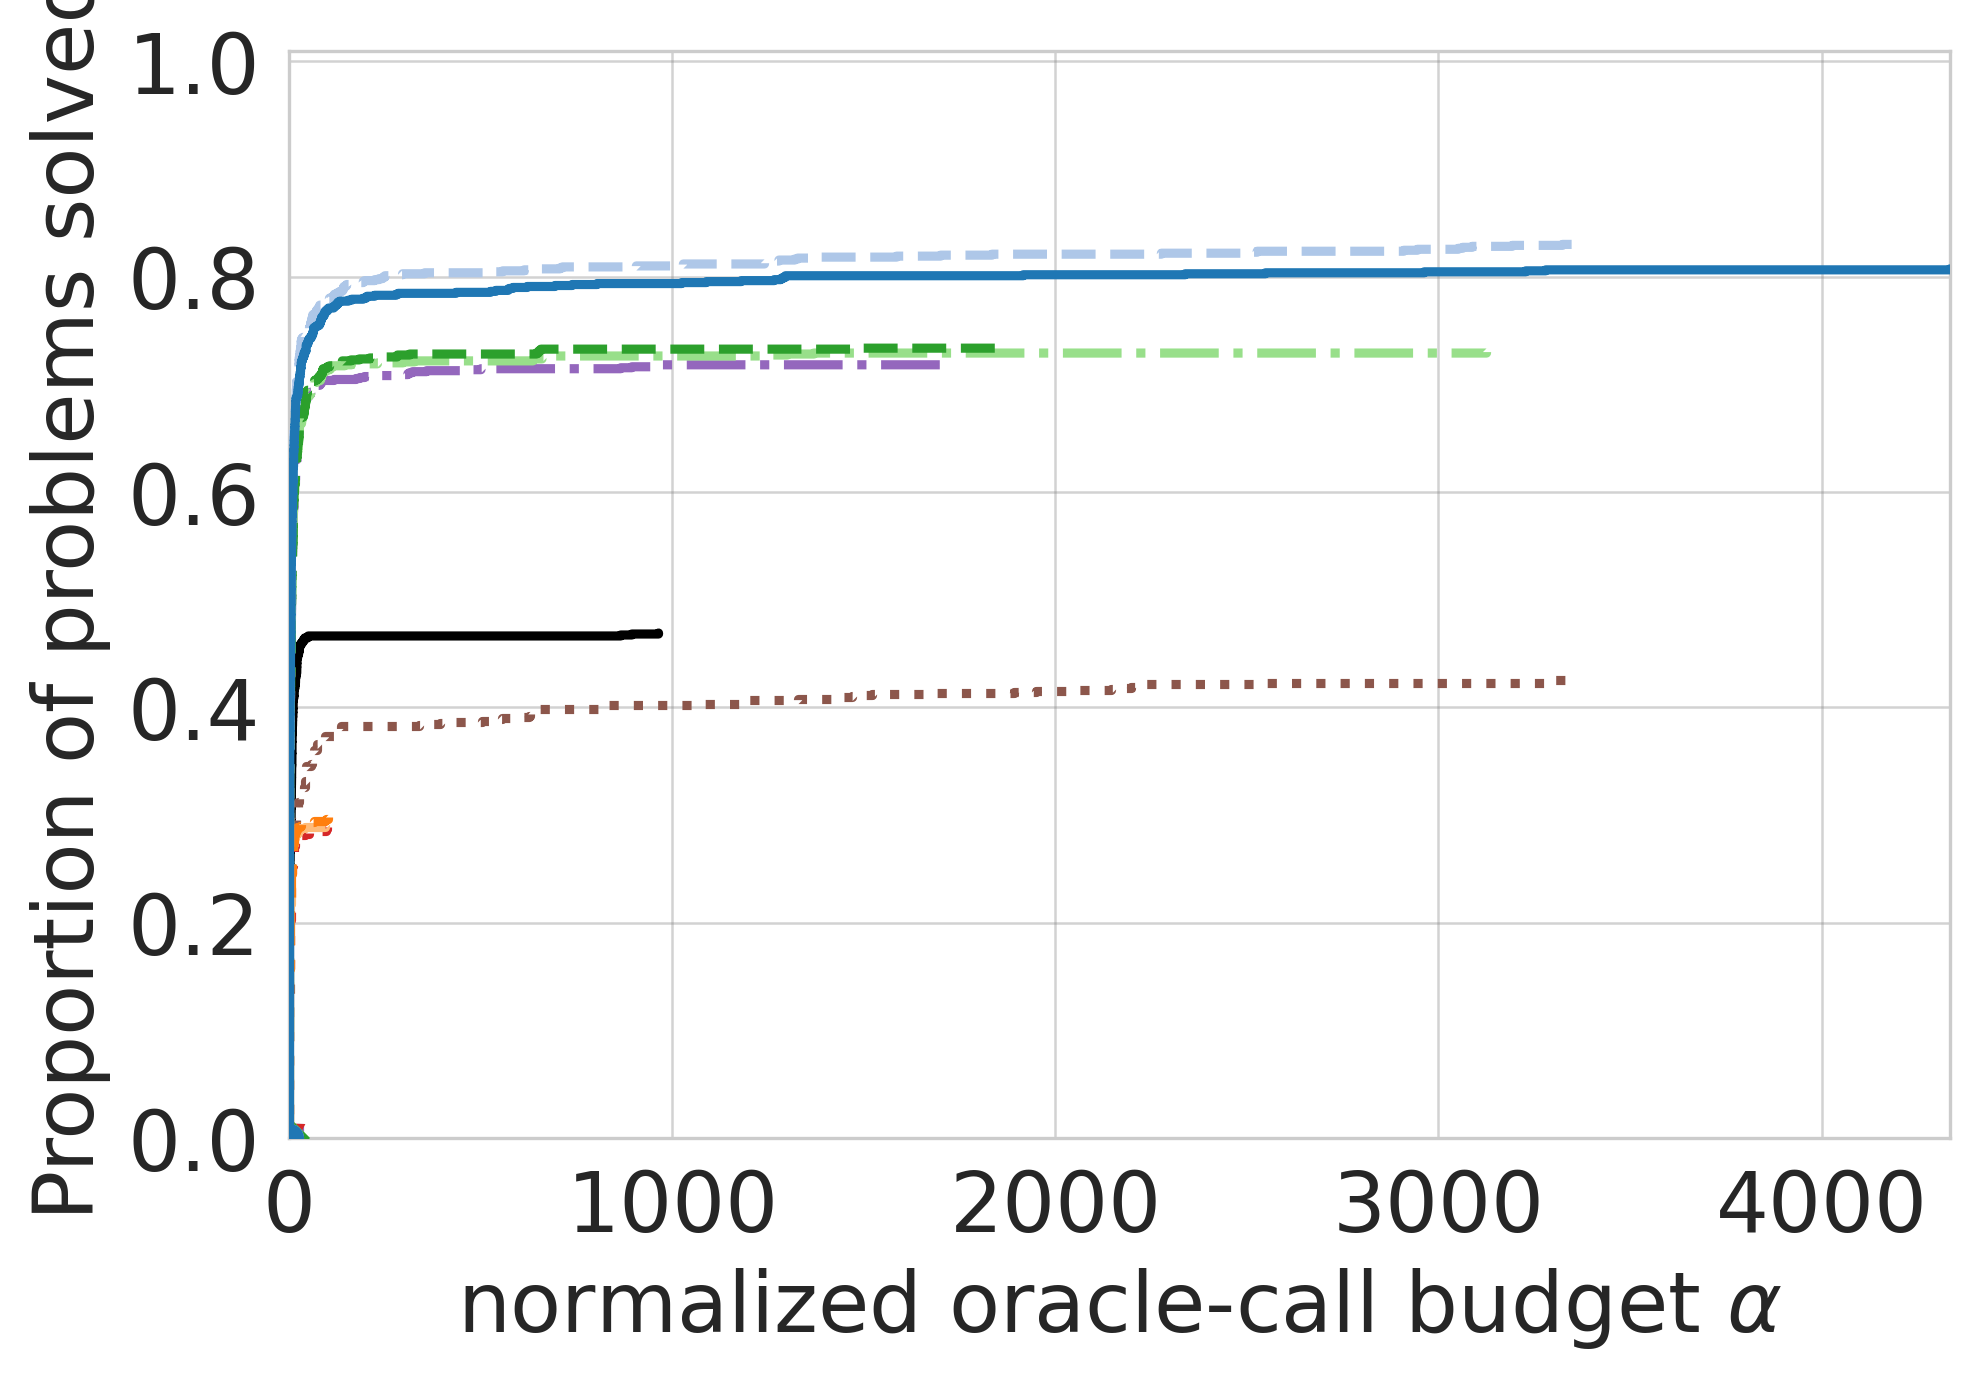

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad,NTQN-Default-Termination
AKIVA (seed=0),41.0,49.0,inf,inf,47.0,45.0,inf,inf,4560.0,inf
ALLINITU (seed=0),23.0,23.0,22.0,24.0,20.0,22.0,22.0,23.0,49.0,23.0
ARGLINA (seed=0),8.0,8.0,10.0,10.0,14.0,14.0,10.0,5.0,12.0,5.0
ARGLINB (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0,42.0
ARGLINC (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0,42.0
...,...,...,...,...,...,...,...,...,...,...
WOODS (seed=4),46.0,38.0,inf,44.0,50.0,50.0,inf,93.0,1222.0,93.0
YATP1LS (seed=4),inf,2577.0,inf,inf,50.0,66.0,inf,123.0,inf,inf
YATP2LS (seed=4),inf,inf,inf,inf,161.0,133.0,inf,26.0,1221.0,26.0
YFITU (seed=4),116.0,156.0,inf,inf,219.0,264.0,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,80.727273,26.454545
NTRQN-MS,83.090909,31.272727
Line,29.818182,8.727273
Line-MS,29.363636,9.636364
Reg,73.454545,16.181818
Reg-Sec,73.000000,16.545455
SciPy,28.909091,8.909091
NTQN,71.909091,15.727273
ASTR1-Adagrad,42.818182,9.818182
NTQN-Default-Termination,46.909091,11.727273


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,1100,0,1081,19,0,193
NTRQN-MS,1100,0,1085,15,0,171
Line,1100,0,1100,0,0,775
Line-MS,1100,0,1100,0,0,778
Reg,1100,0,1092,4,4,345
Reg-Sec,1100,0,1095,5,0,340
SciPy,1100,0,1100,0,0,0
NTQN,1100,0,1075,25,0,5
ASTR1-Adagrad,1100,0,1080,20,0,609


flag,0,2,4,5,6
method,,,,,
NTQN,789,5,0,0,281
NTQN-Default-Termination,298,0,761,5,30


,mean solved fraction,std. dev. across seeds
NTRQN,0.807273,0.006098
NTRQN-MS,0.830909,0.007469
Line,0.298182,0.016262
Line-MS,0.293636,0.018906
Reg,0.734545,0.013484
Reg-Sec,0.730000,0.013484
SciPy,0.289091,0.014938
NTQN,0.719091,0.003803
ASTR1-Adagrad,0.428182,0.009315
NTQN-Default-Termination,0.469091,0.010365


Saved figure to doc/imgs/compare/_pp_eps_under_gtol1e-02.pdf


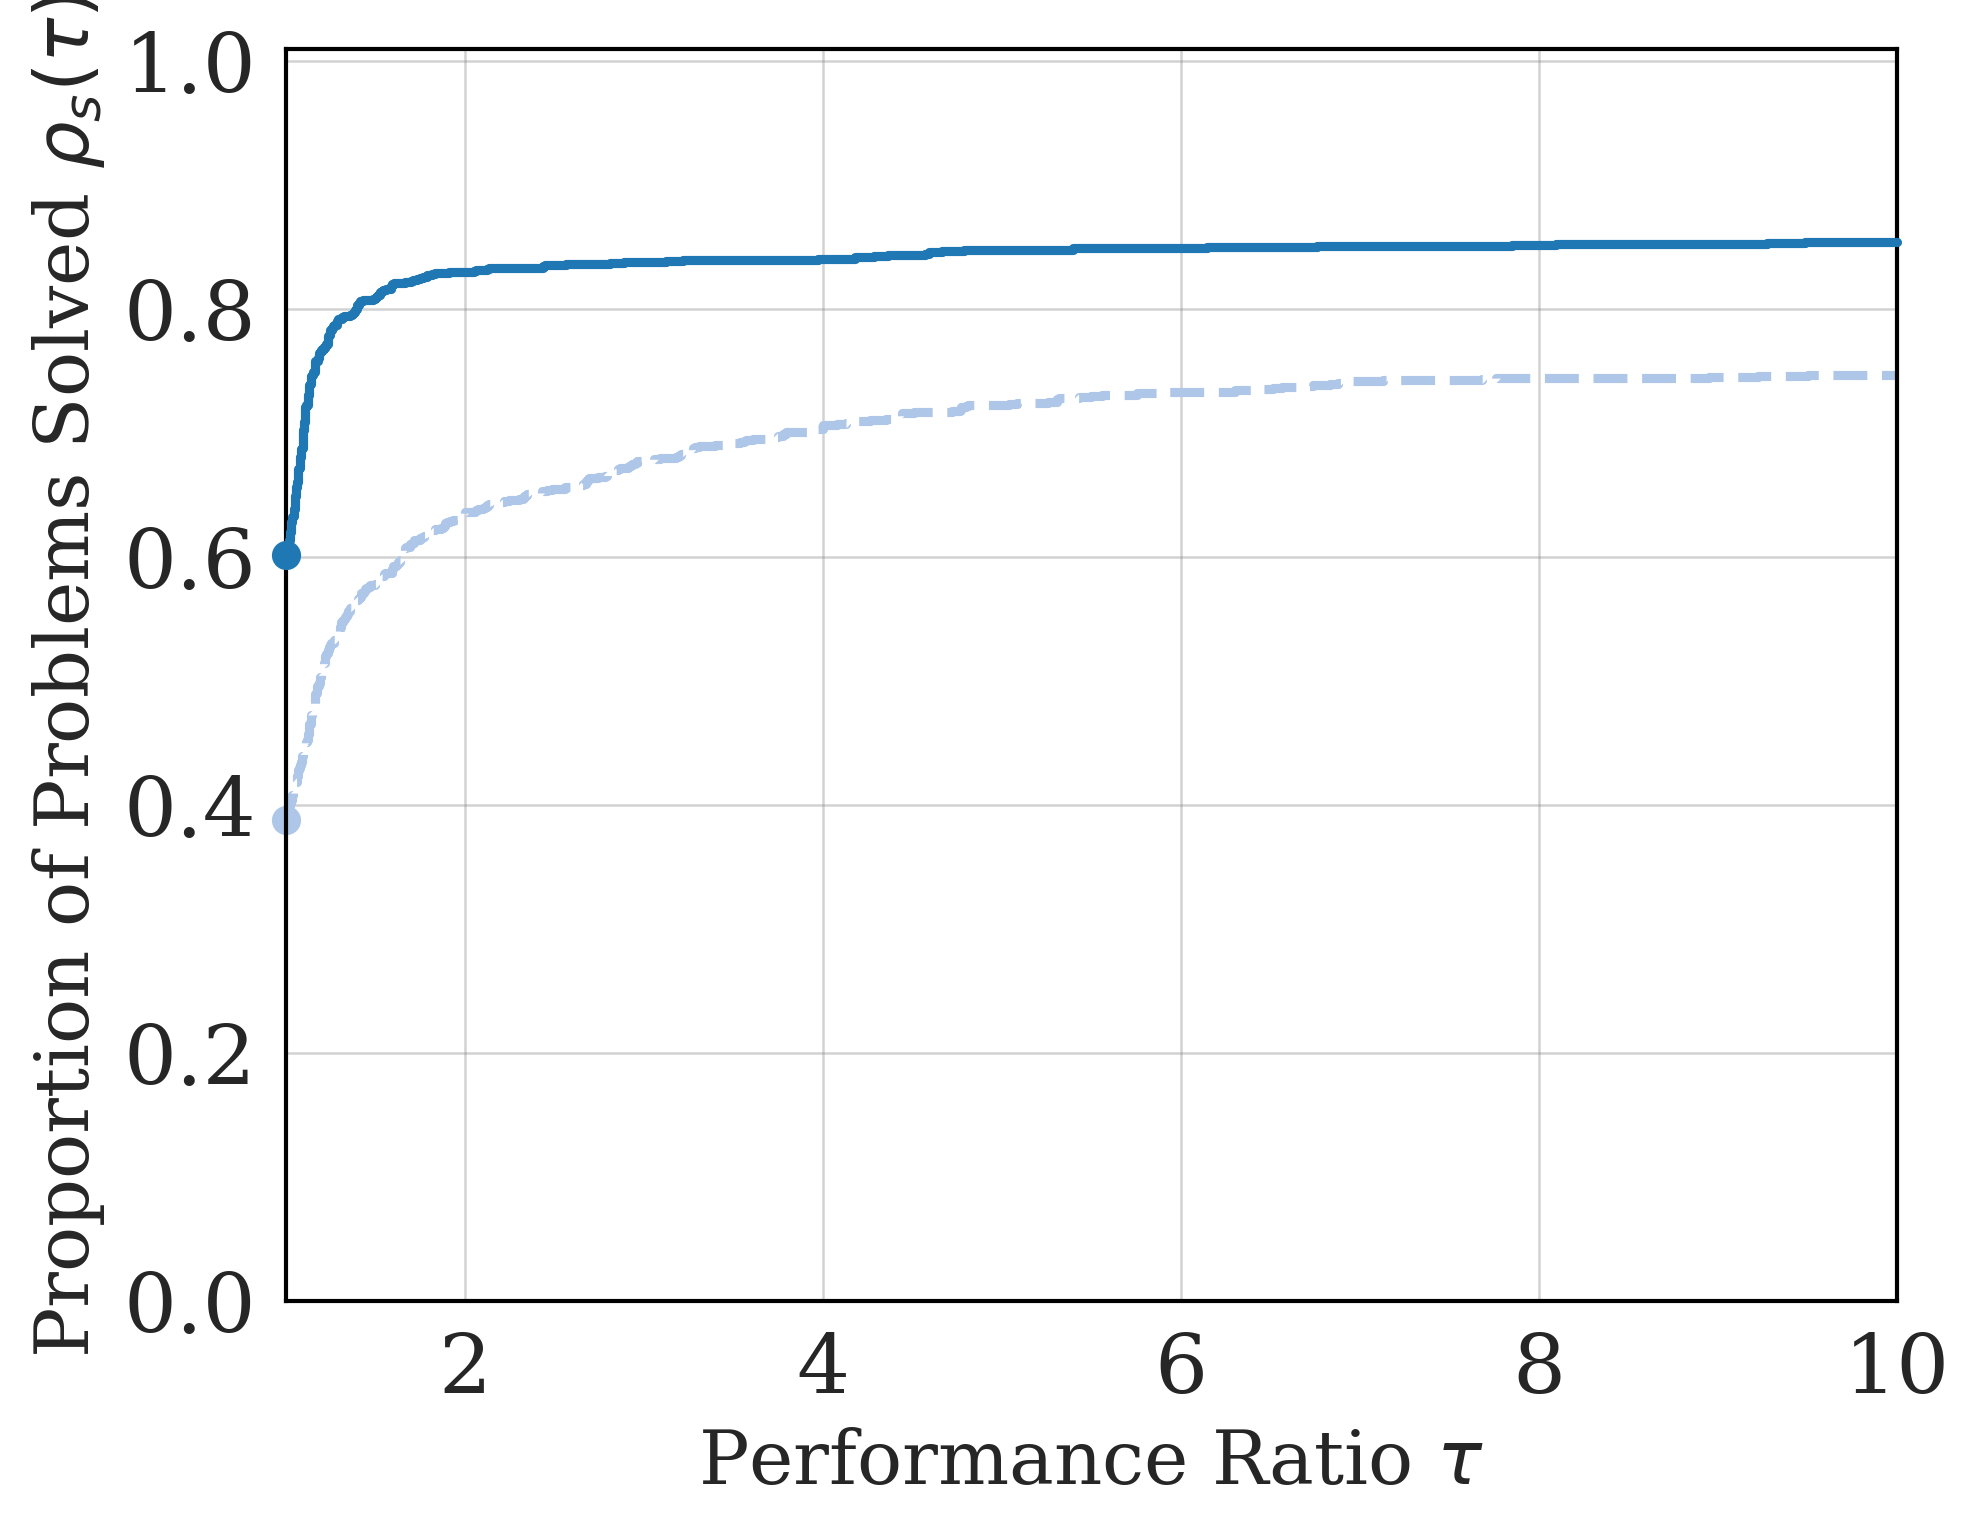

Saved figure to doc/imgs/compare/_dp_eps_under_gtol1e-02.pdf


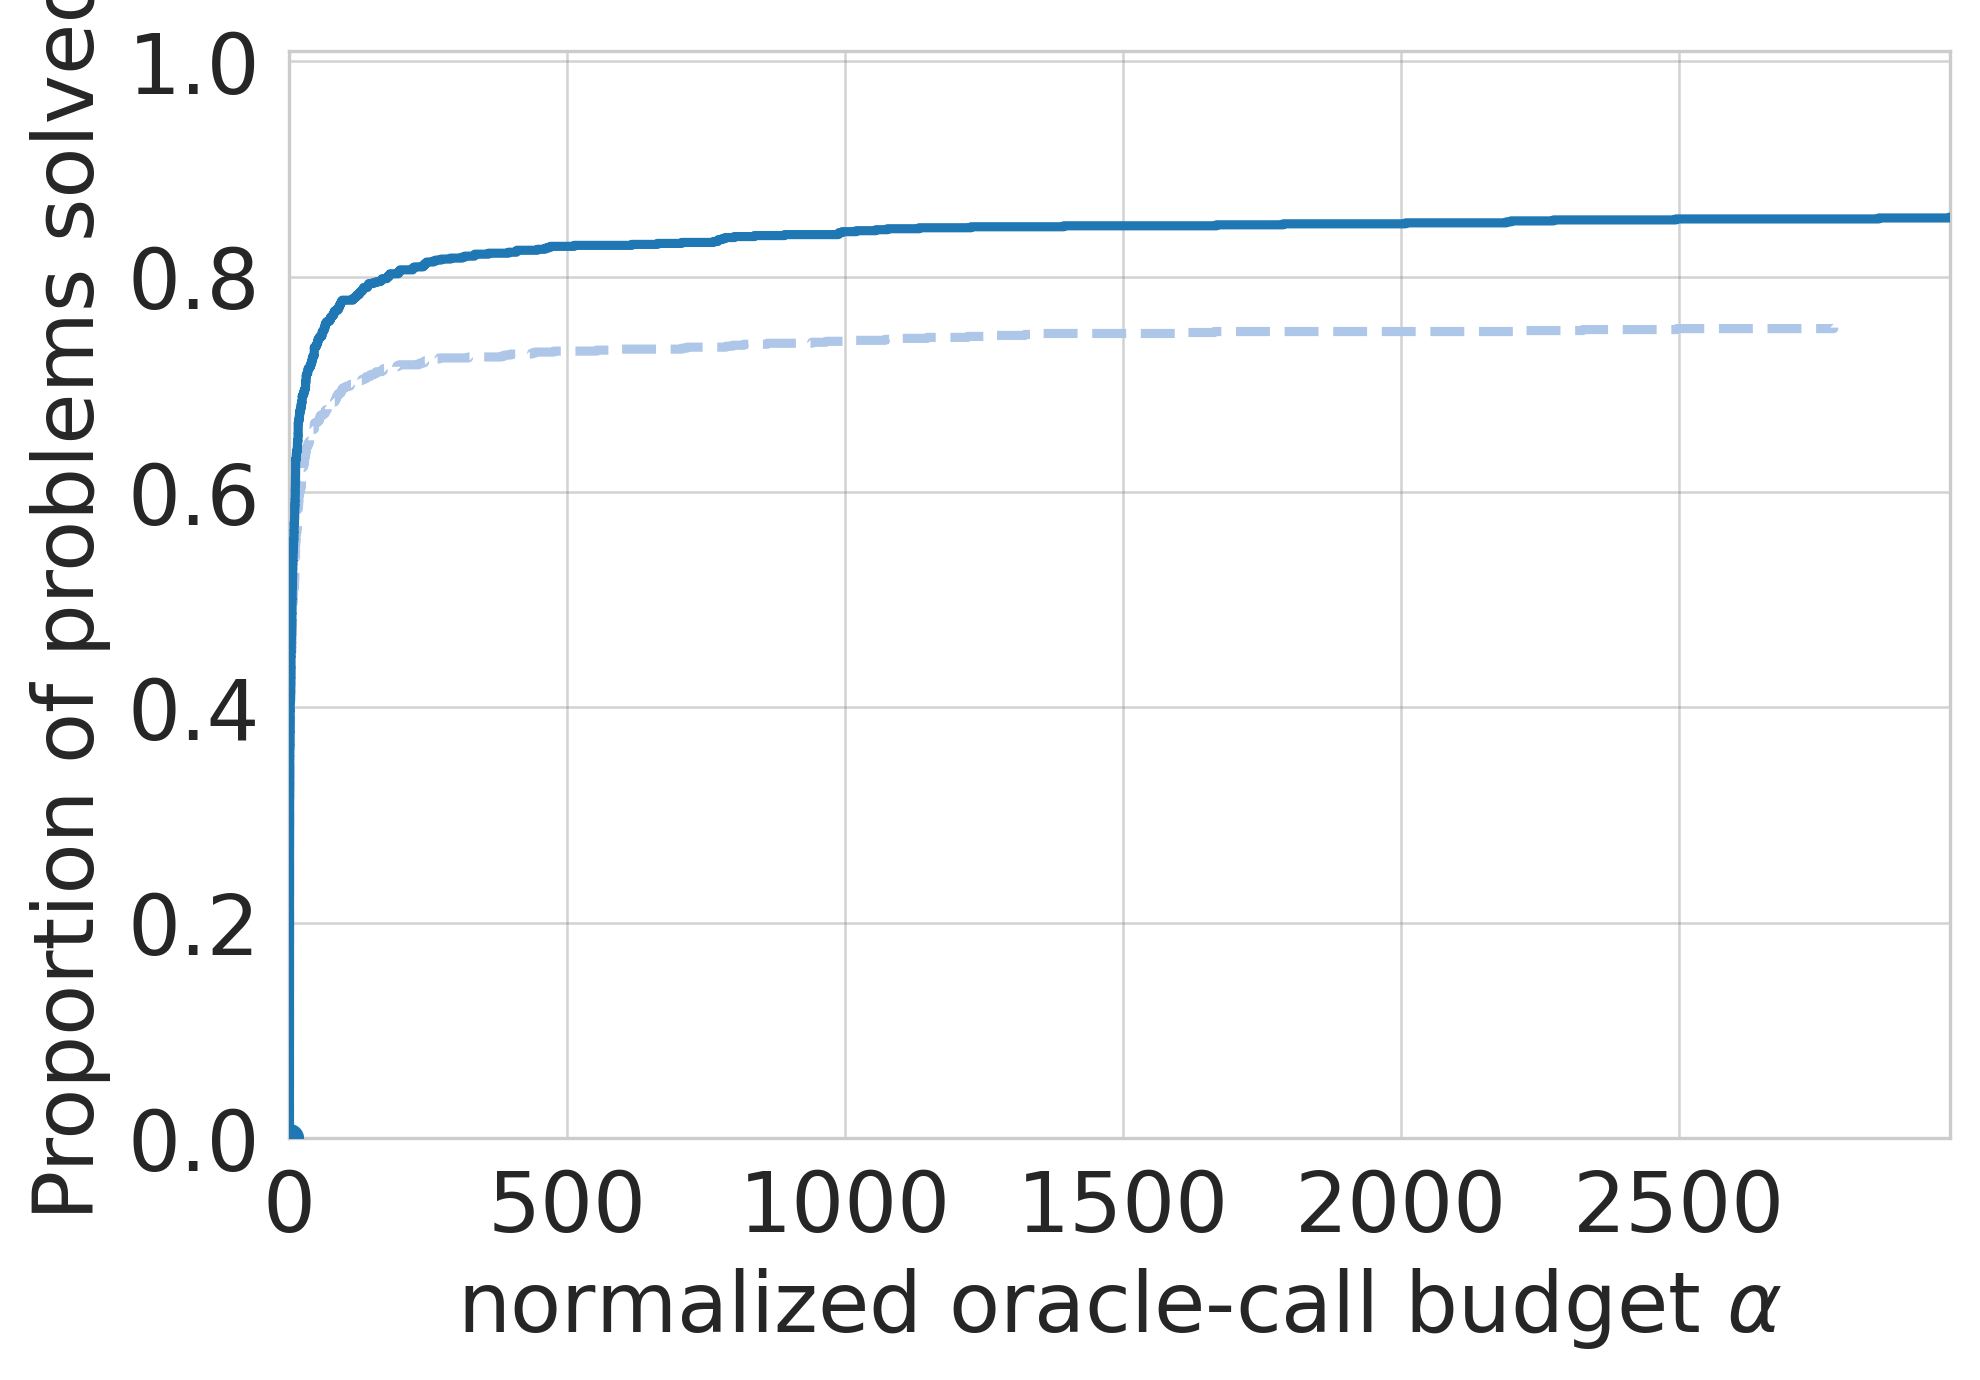

,NTRQN,NTRQN-MS
AKIVA (seed=0),47.0,68.0
ALLINITU (seed=0),21.0,23.0
ARGLINA (seed=0),6.0,6.0
ARGLINB (seed=0),8.0,8.0
ARGLINC (seed=0),8.0,8.0
...,...,...
WOODS (seed=4),42.0,38.0
YATP1LS (seed=4),59.0,34.0
YATP2LS (seed=4),122.0,inf
YFITU (seed=4),214.0,142.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,85.545455,60.181818
NTRQN-MS,75.272727,38.818182


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,1100,0,1099,1,0,158
NTRQN-MS,1100,0,1098,2,0,270


,mean solved fraction,std. dev. across seeds
NTRQN,0.855455,0.012613
NTRQN-MS,0.752727,0.019969


Saved figure to doc/imgs/compare/_pp_eps_nominal_gtol1e-02.pdf


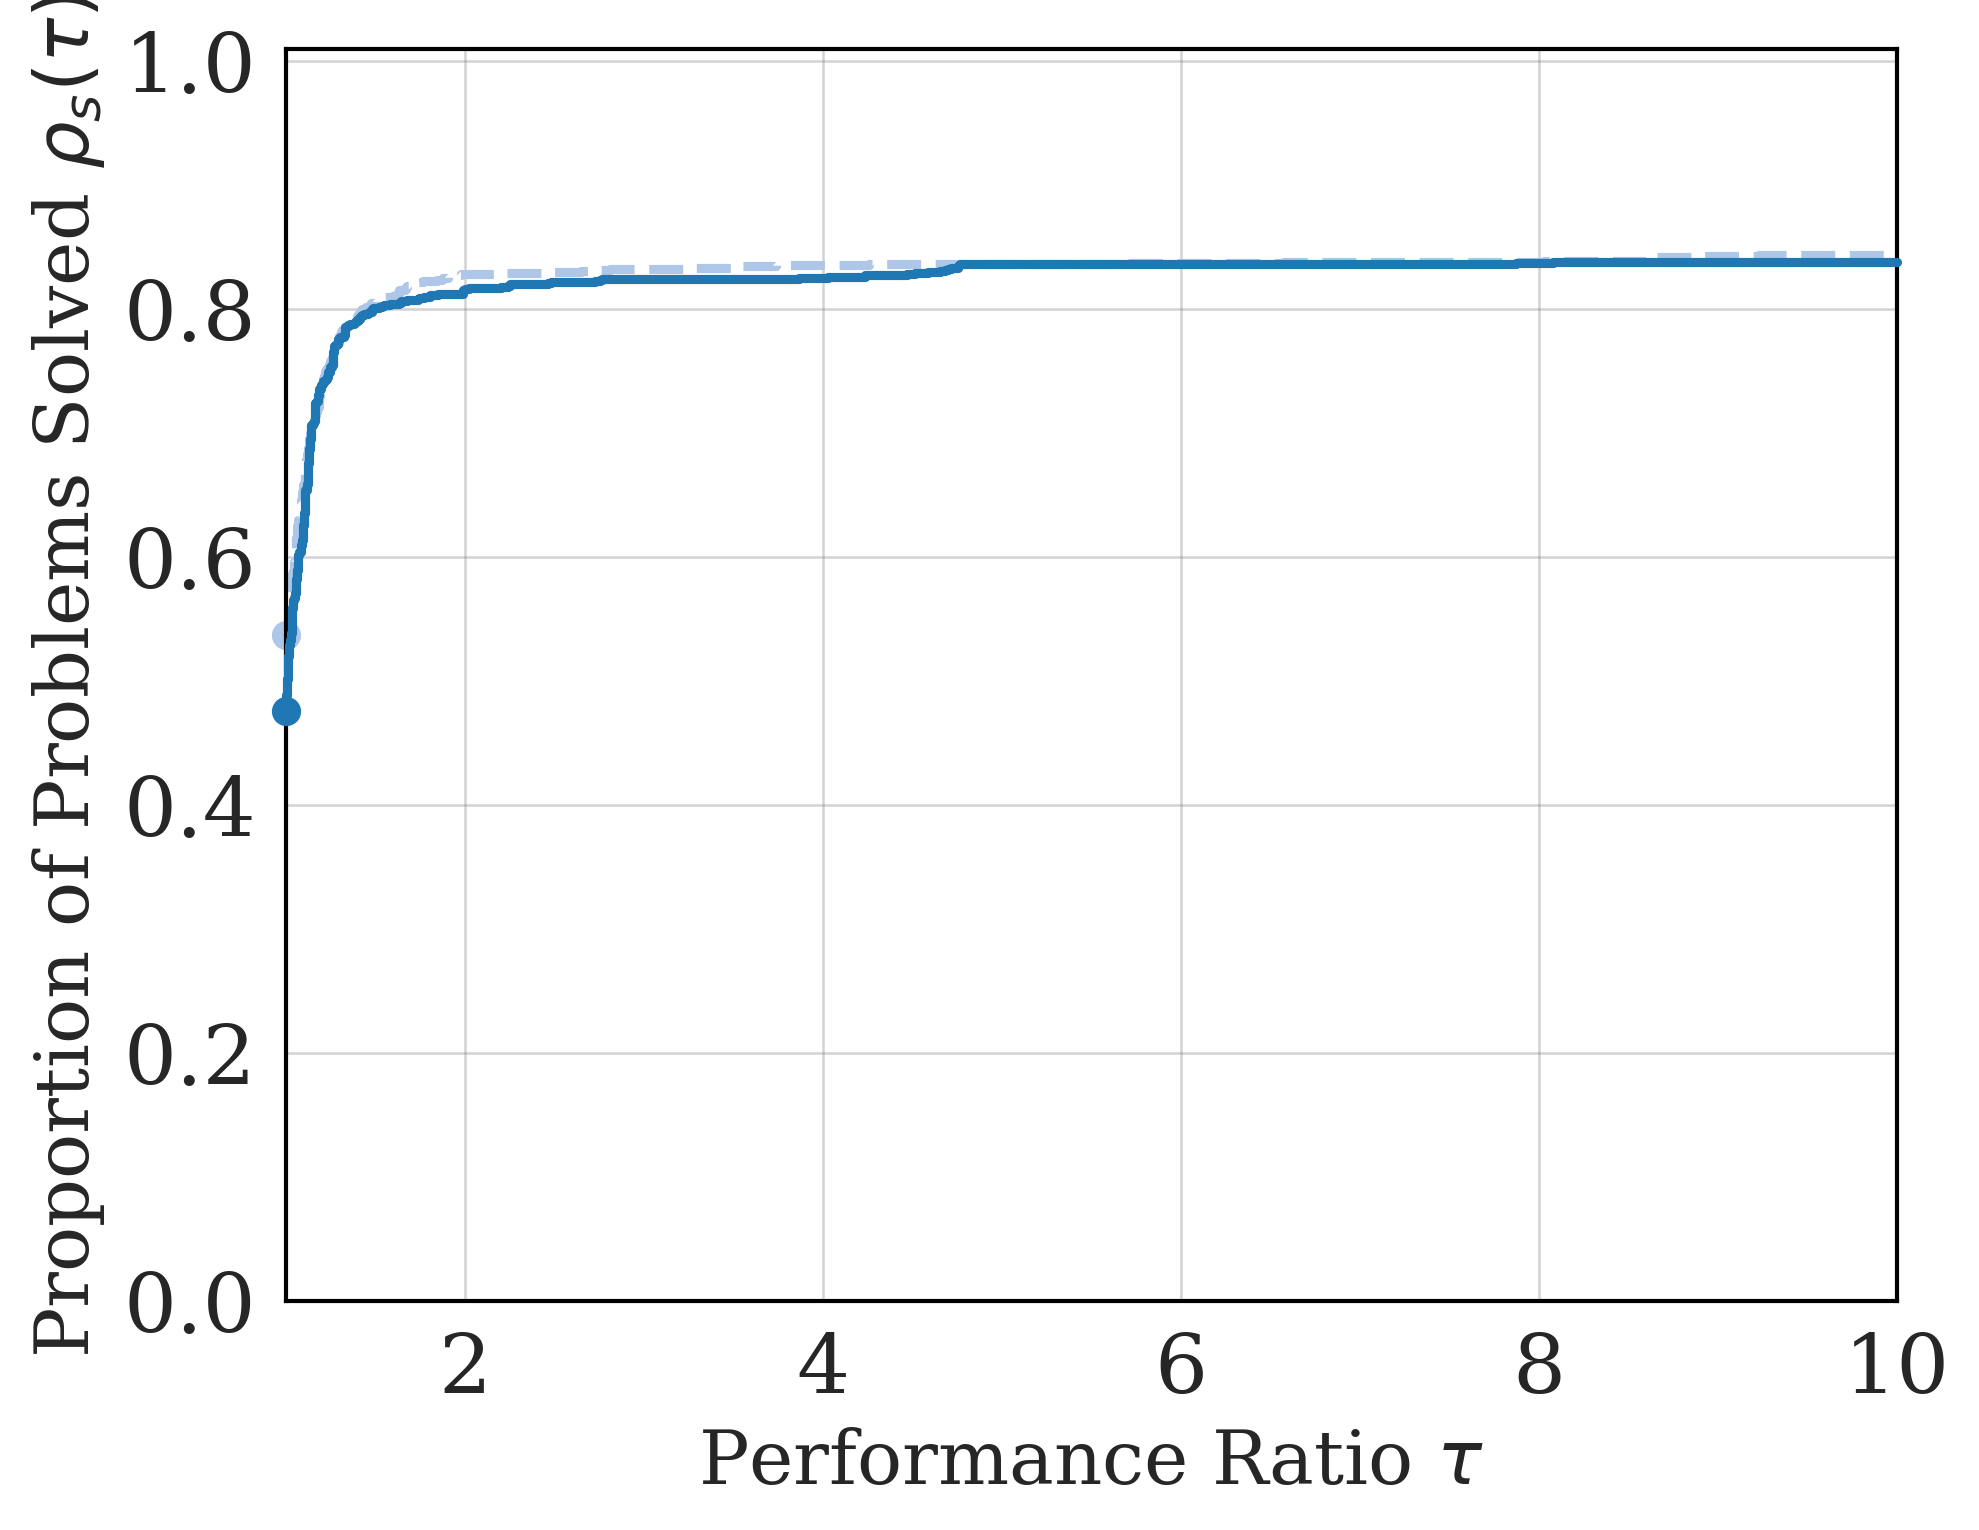

Saved figure to doc/imgs/compare/_dp_eps_nominal_gtol1e-02.pdf


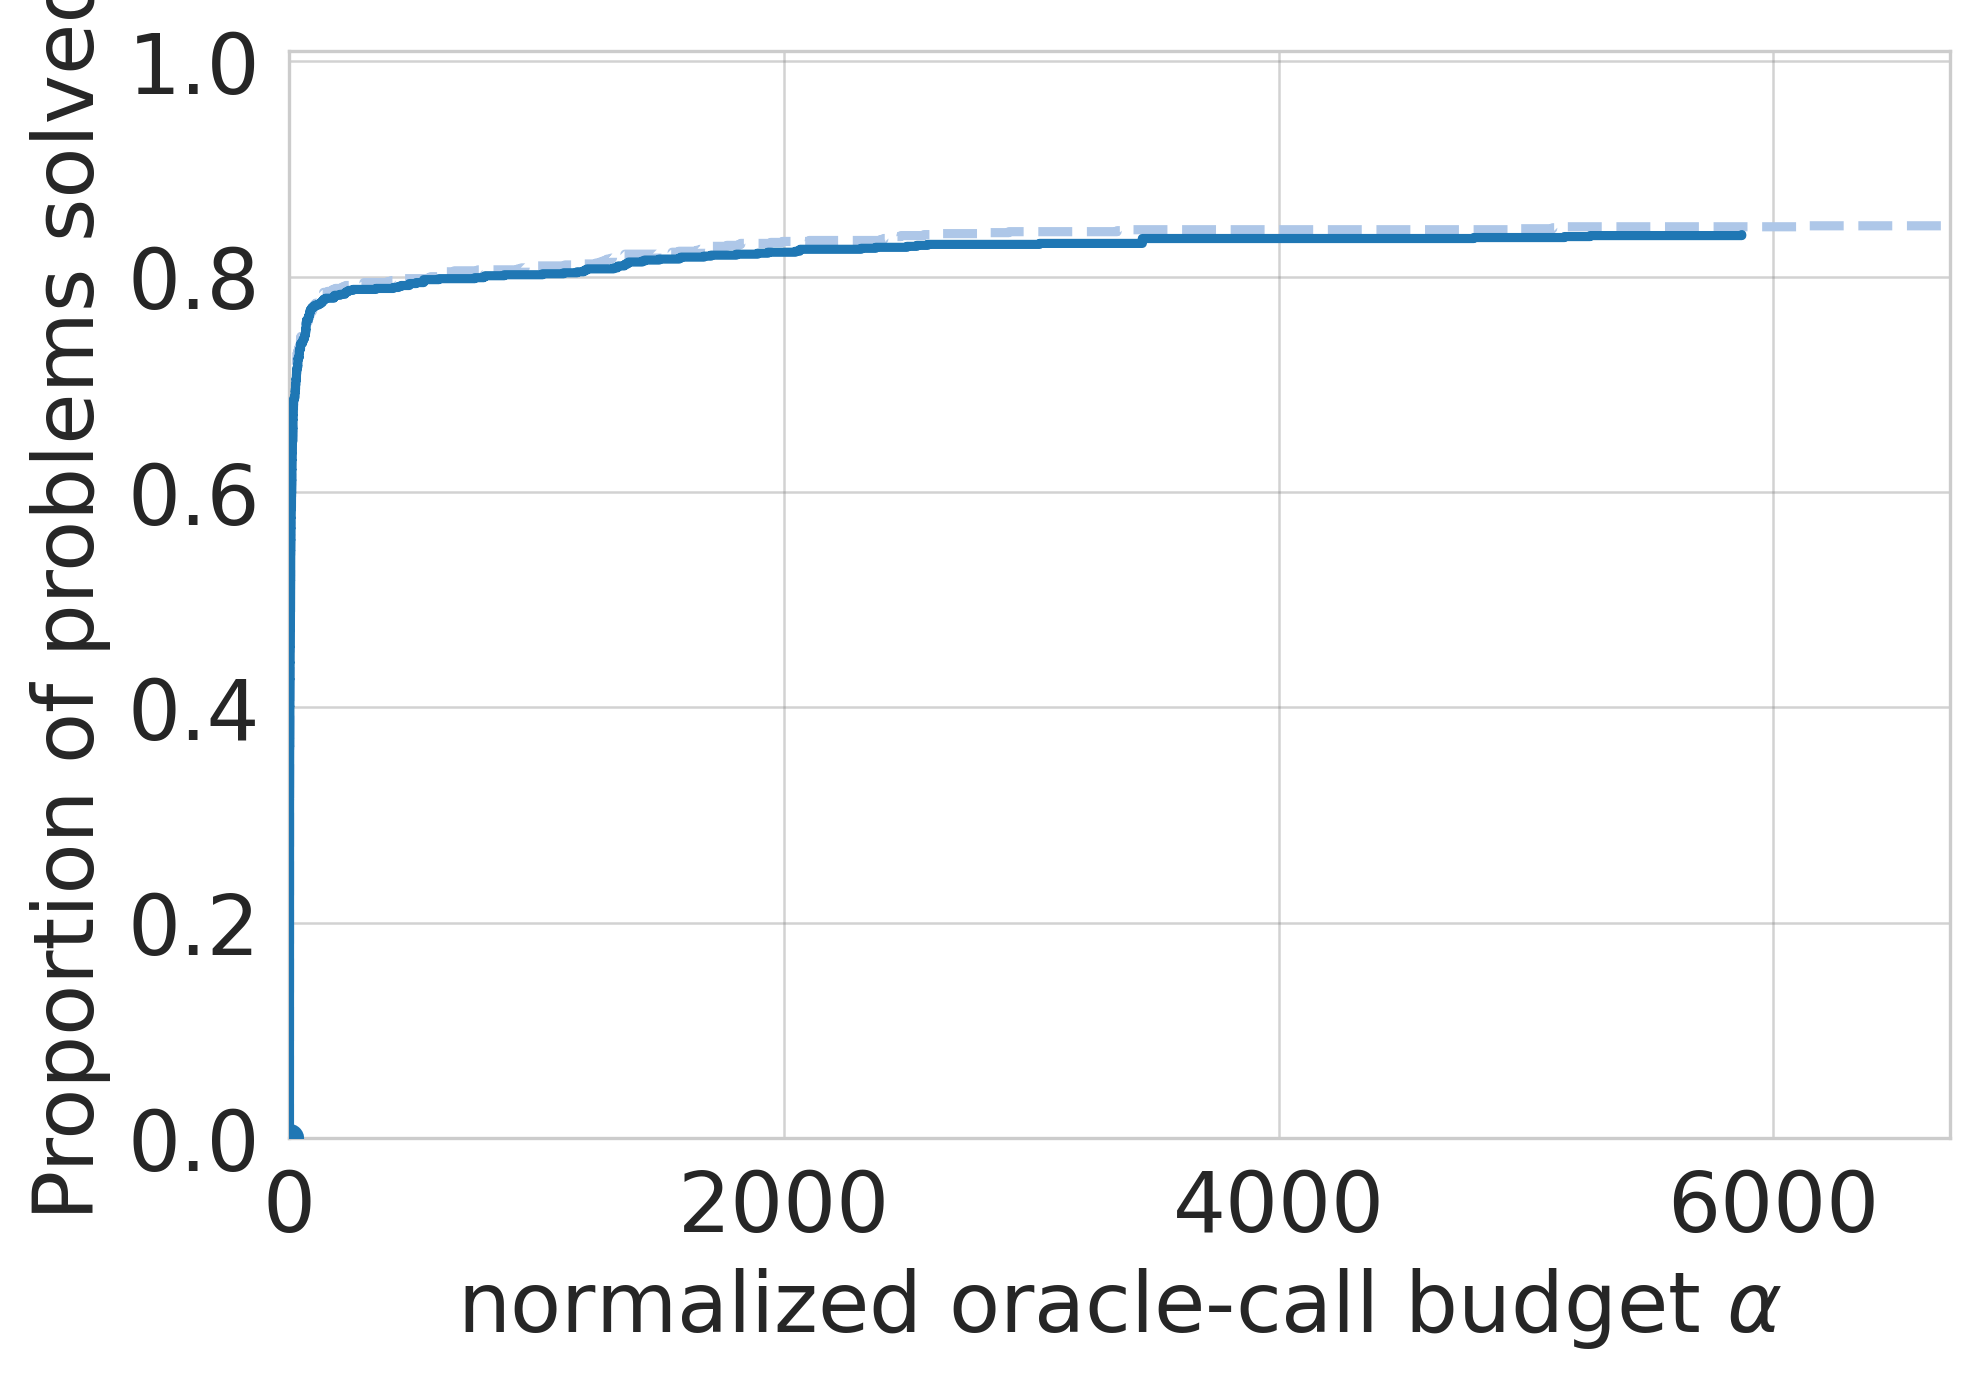

,NTRQN,NTRQN-MS
AKIVA (seed=0),35.0,49.0
ALLINITU (seed=0),23.0,25.0
ARGLINA (seed=0),6.0,6.0
ARGLINB (seed=0),8.0,8.0
ARGLINC (seed=0),8.0,8.0
...,...,...
WOODS (seed=4),42.0,38.0
YATP1LS (seed=4),140.0,153.0
YATP2LS (seed=4),inf,inf
YFITU (seed=4),262.0,150.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,83.909091,47.636364
NTRQN-MS,84.818182,53.727273


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,1100,0,1090,10,0,167
NTRQN-MS,1100,0,1090,10,0,157


,mean solved fraction,std. dev. across seeds
NTRQN,0.839091,0.005183
NTRQN-MS,0.848182,0.008257


Saved figure to doc/imgs/compare/_pp_eps_over_gtol1e-02.pdf


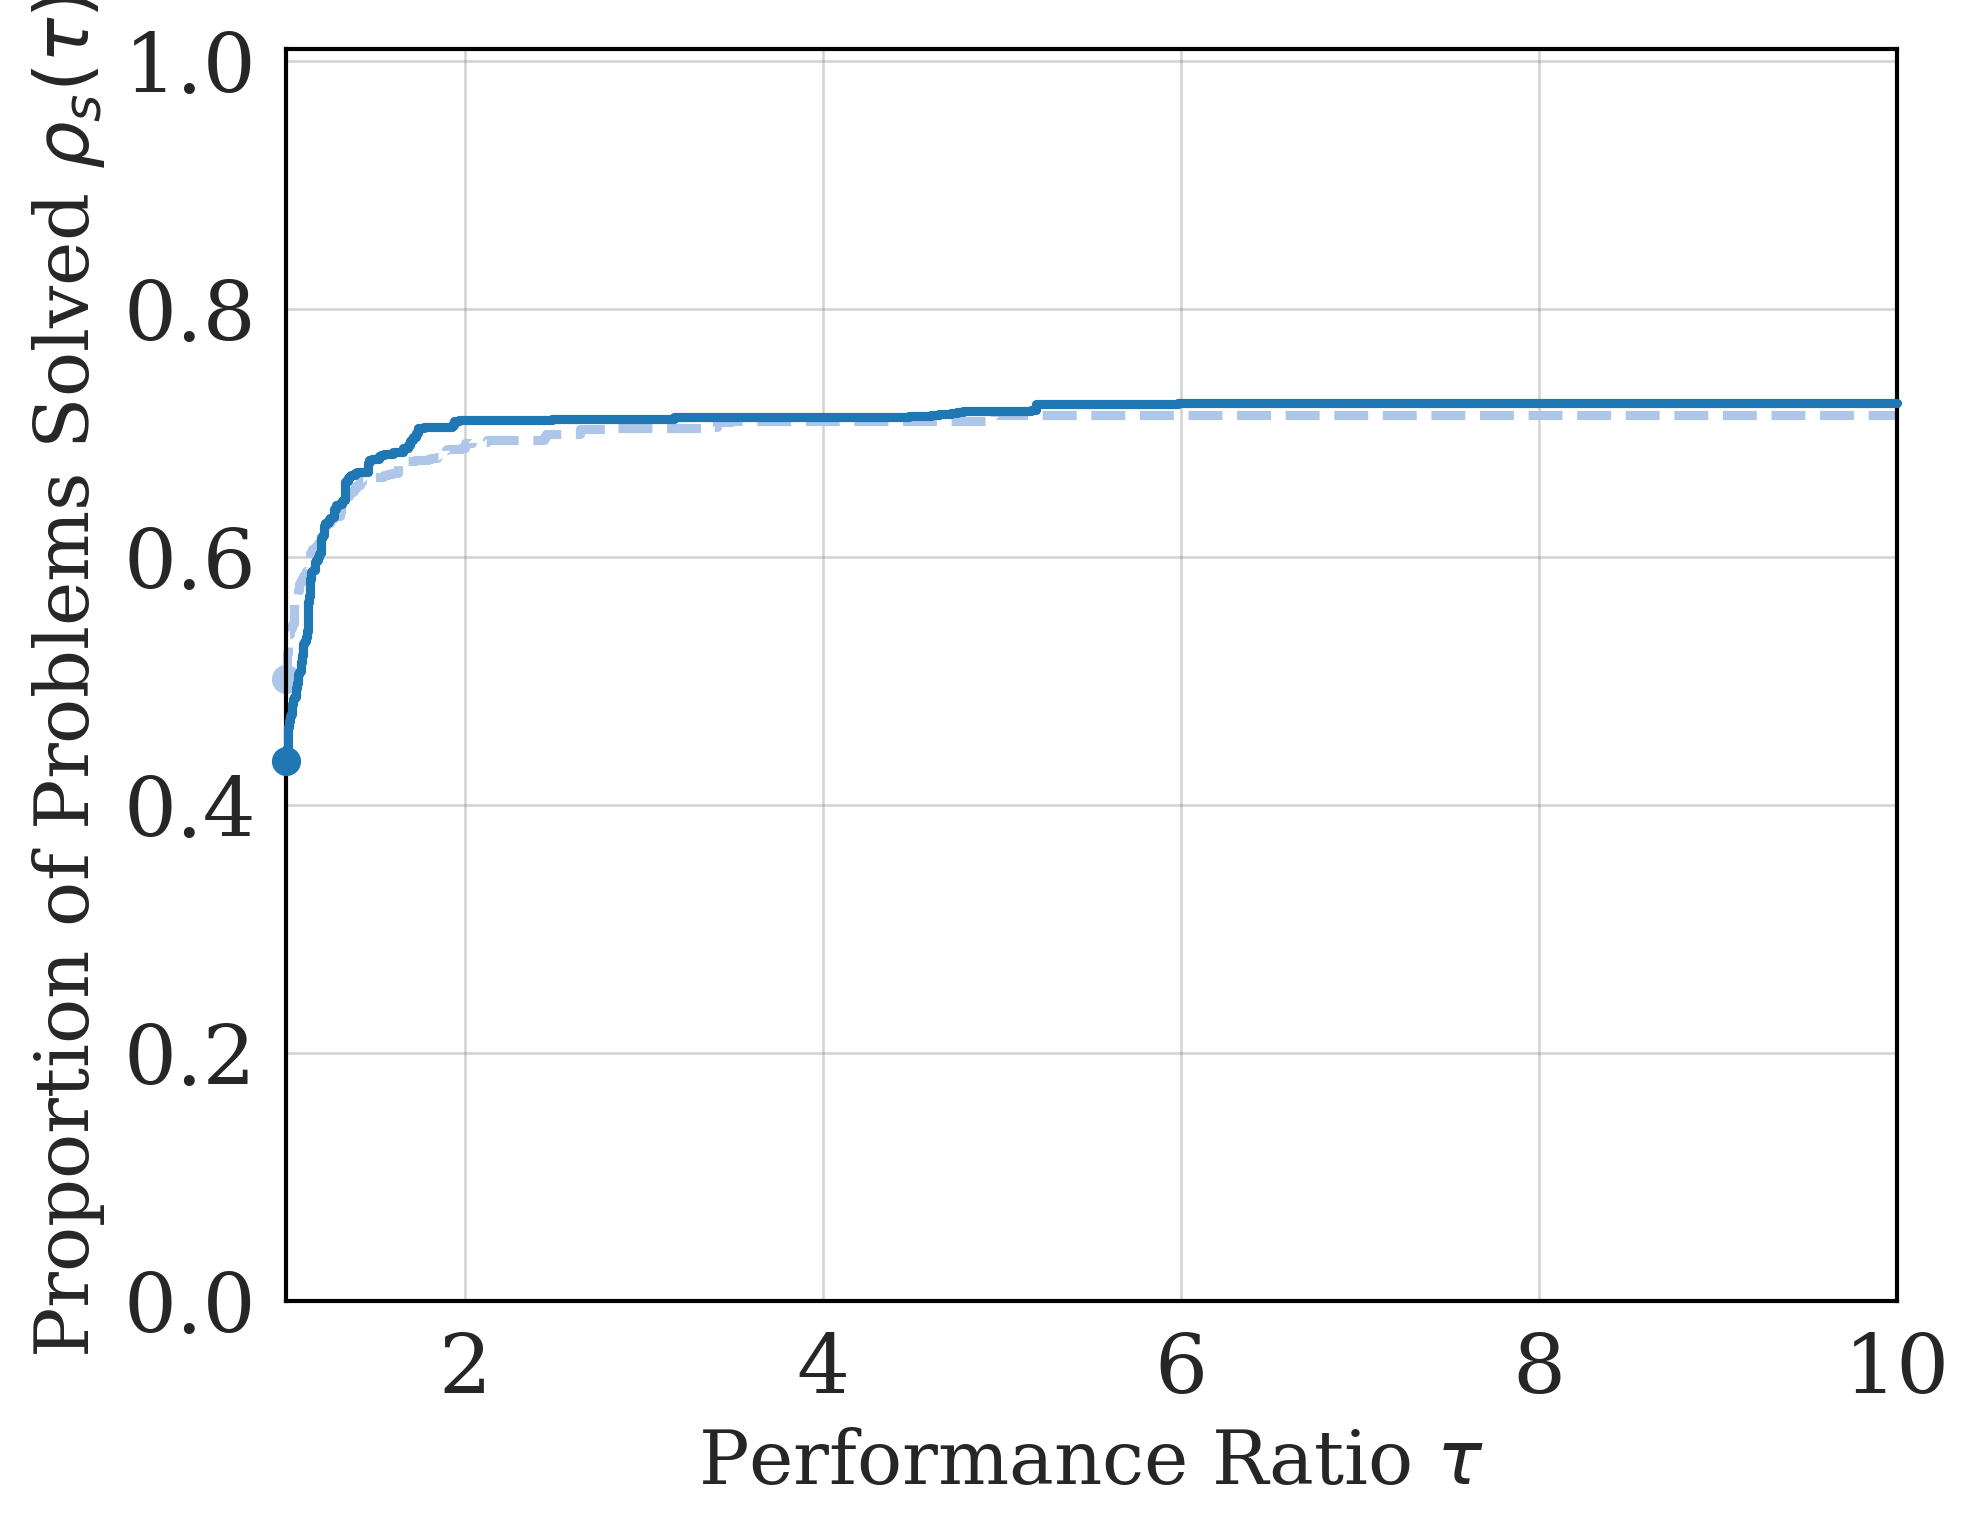

Saved figure to doc/imgs/compare/_dp_eps_over_gtol1e-02.pdf


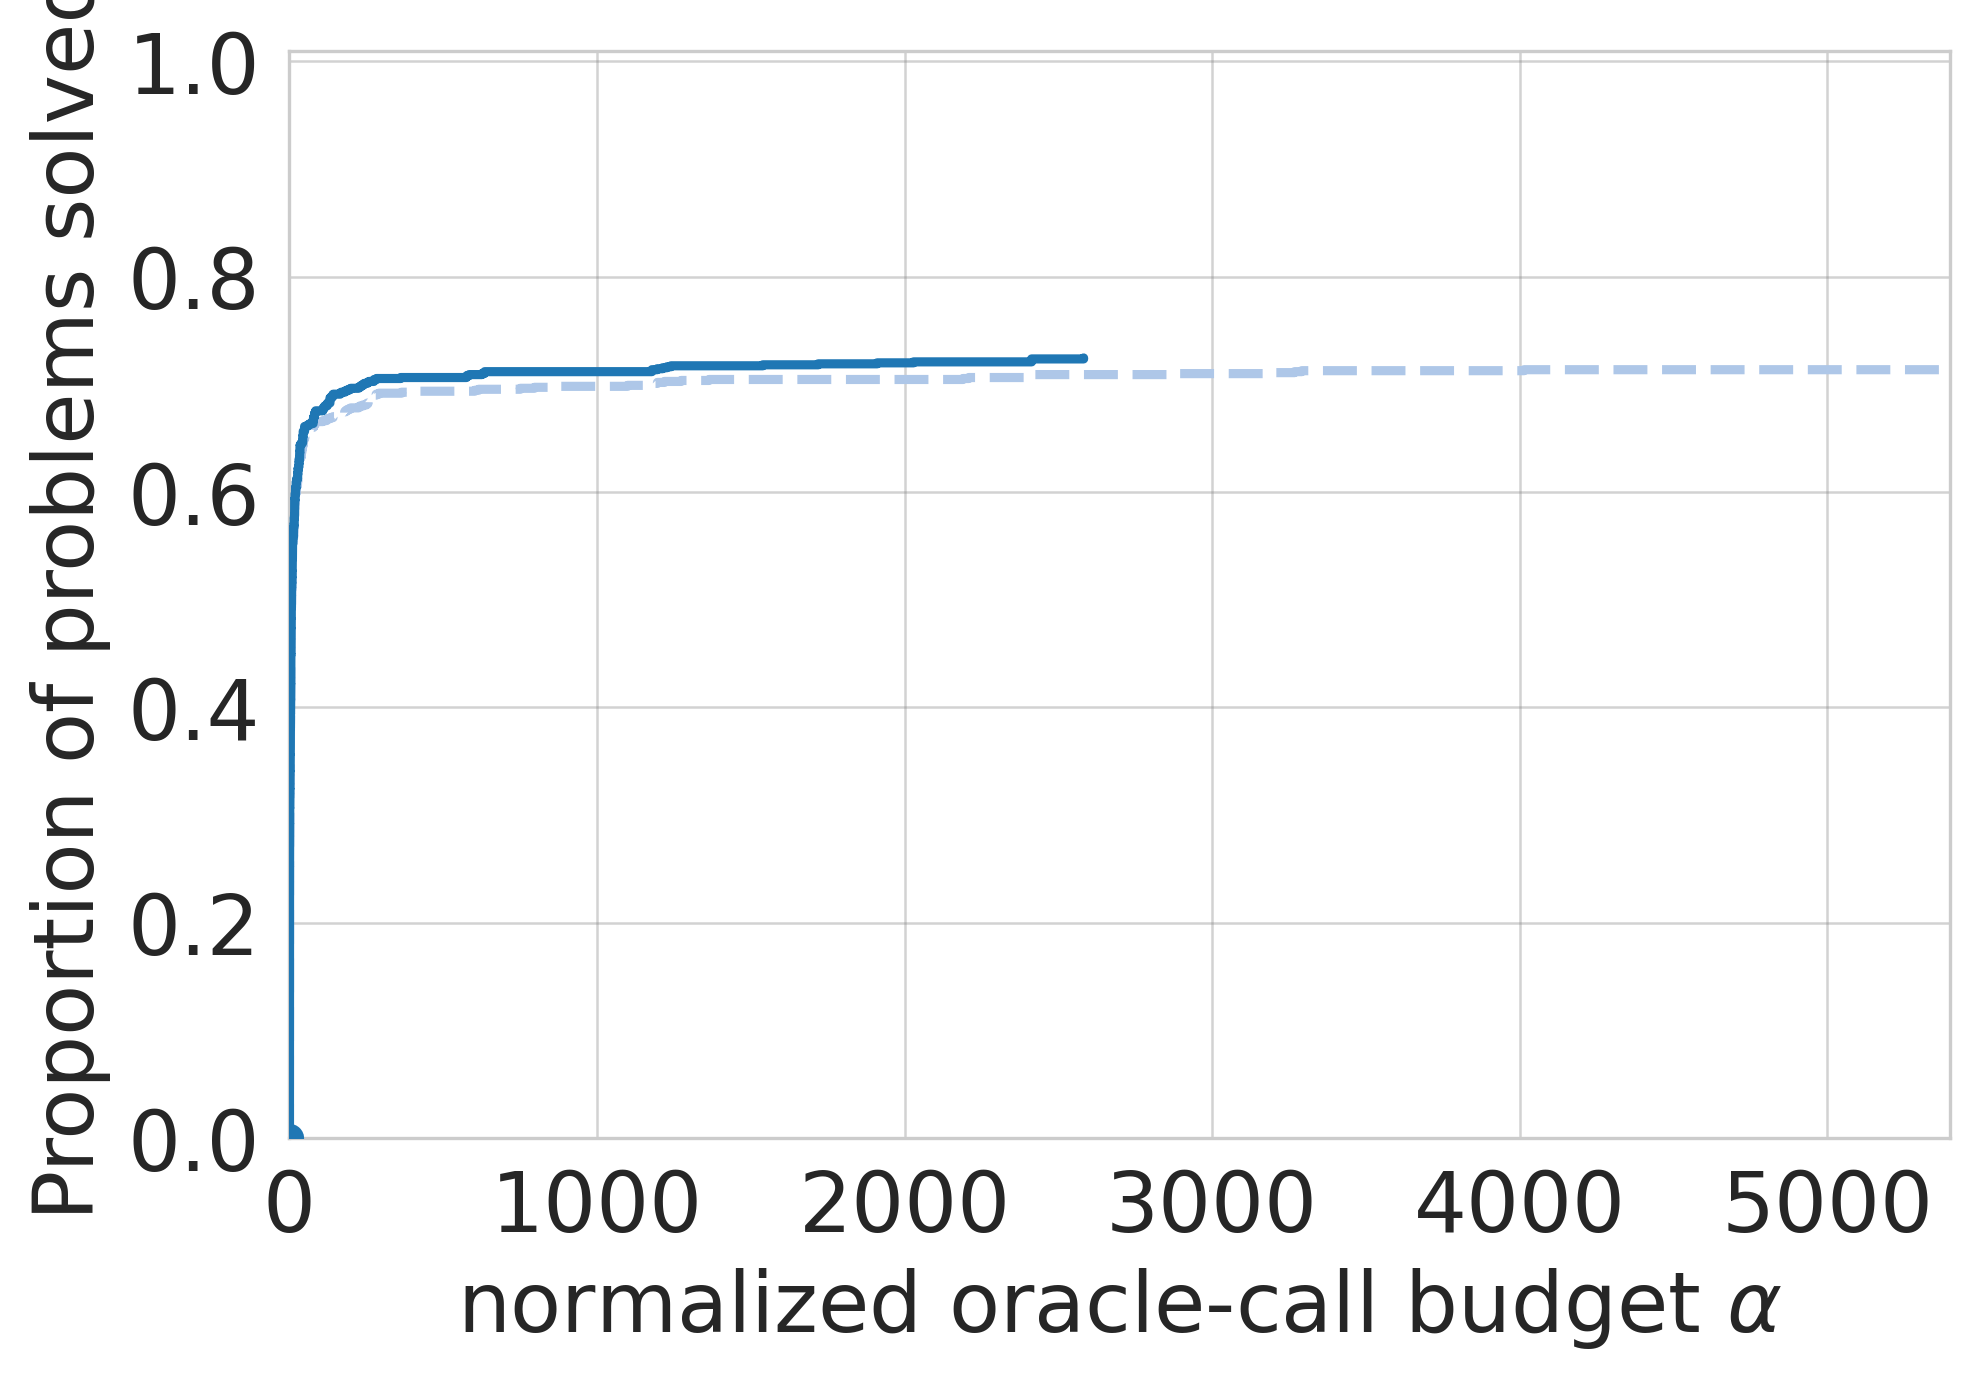

,NTRQN,NTRQN-MS
AKIVA (seed=0),59.0,57.0
ALLINITU (seed=0),23.0,21.0
ARGLINA (seed=0),8.0,8.0
ARGLINB (seed=0),10.0,10.0
ARGLINC (seed=0),10.0,10.0
...,...,...
WOODS (seed=4),529.0,inf
YATP1LS (seed=4),2085.0,1782.0
YATP2LS (seed=4),inf,inf
YFITU (seed=4),inf,16059.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,72.454545,43.545455
NTRQN-MS,71.454545,50.181818


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,1100,0,1090,10,0,293
NTRQN-MS,1100,0,1090,10,0,304


,mean solved fraction,std. dev. across seeds
NTRQN,0.724545,0.005183
NTRQN-MS,0.714545,0.005927


In [7]:
SCENARIOS_TO_PLOT = [
    "float64",
    "float32",
    "float16",
    "function_only",
    "joint_noise",
    "eps_under",
    "eps_nominal",
    "eps_over",
]


def display_result_summaries(alg_names, calls, metadata):
    best_calls = calls.min(axis=0)
    fastest = (calls == best_calls) & np.isfinite(best_calls)[None, :]
    display(
        pd.DataFrame(
            {
                "solved (percent)": 100.0 * np.isfinite(calls).mean(axis=1),
                "fastest, ties included (percent)": 100.0 * fastest.mean(axis=1),
            },
            index=alg_names,
        )
    )
    display(summarize_run_metadata(alg_names, metadata))
    restart_summary, ntqn_summary = summarize_diagnostics(alg_names, metadata)
    if not restart_summary.empty:
        display(restart_summary.set_index("method"))
    if not ntqn_summary.empty:
        display(ntqn_summary)


_, ALGORITHM_COLORS, ALGORITHM_LINE_STYLES = get_methods()
ALGORITHM_COLORS["ASTR1-Adagrad"] = COLORS["ASTR1-Adagrad"]
ALGORITHM_LINE_STYLES["ASTR1-Adagrad"] = LINE_STYLES["ASTR1-Adagrad"]
for scenario in SCENARIOS_TO_PLOT:
    config = SCENARIOS[scenario]
    for gtol in config["score_gtols"]:
        seeds = get_scenario_seeds(scenario)
        primary_labels = METHODS_TO_RUN or (
            SCENARIO_DEFAULT_LABELS[scenario] - {"NTRQN-Restart"}
        )
        alg_names, calls, instances, dimensions, metadata = load_scenario_results(
            scenario, seeds, gtol, labels=primary_labels
        )
        output_path = None
        if scenario not in {"float64", "float32", "float16", "joint_noise"}:
            gtol_name = f"{gtol:.0e}".replace("+", "")
            output_path = (
                Path("doc/imgs/compare") / f"_pp_{scenario}_gtol{gtol_name}.pdf"
            )
        draw_pp(
            alg_names,
            calls,
            ALGORITHM_COLORS,
            ALGORITHM_LINE_STYLES,
            config["precision"],
            np.float64(max(config["function_noise"], config["gradient_noise"])),
            np.float64(gtol),
            output_path=output_path,
        )
        gtol_name = f"{gtol:.0e}".replace("+", "")
        data_profile_path = (
            Path("doc/imgs/compare") / f"_dp_{scenario}_gtol{gtol_name}.pdf"
        )
        if np.all(np.isfinite(dimensions)):
            draw_data_profile(
                alg_names,
                calls,
                dimensions,
                ALGORITHM_COLORS,
                ALGORITHM_LINE_STYLES,
                data_profile_path,
            )
        else:
            print("Skipping data profile because some result metadata lack dimensions.")

        table = pd.DataFrame(calls.T, index=instances, columns=alg_names)
        display(table)

        display_result_summaries(alg_names, calls, metadata)

        if len(seeds) > 1:
            solved_by_seed = []
            for seed in seeds:
                _, seed_calls, _, _, _ = load_scenario_results(
                    scenario, [seed], gtol, labels=primary_labels
                )
                solved_by_seed.append(np.isfinite(seed_calls).mean(axis=1))
            solved_by_seed = np.asarray(solved_by_seed)
            seed_summary = pd.DataFrame(
                {
                    "mean solved fraction": solved_by_seed.mean(axis=0),
                    "std. dev. across seeds": solved_by_seed.std(axis=0, ddof=1),
                },
                index=alg_names,
            )
            display(seed_summary)

        if scenario == "function_only" and METHODS_TO_RUN is None:
            restart_labels = {"NTRQN", "NTRQN-Restart"}
            restart_names, restart_calls, _, restart_dimensions, restart_metadata = (
                load_scenario_results(scenario, seeds, gtol, labels=restart_labels)
            )
            restart_stem = f"function_only_restart_gtol{gtol_name}"
            draw_pp(
                restart_names,
                restart_calls,
                ALGORITHM_COLORS,
                ALGORITHM_LINE_STYLES,
                config["precision"],
                np.float64(config["function_noise"]),
                np.float64(gtol),
                output_path=Path("doc/imgs/compare") / f"_pp_{restart_stem}.pdf",
            )
            if np.all(np.isfinite(restart_dimensions)):
                draw_data_profile(
                    restart_names,
                    restart_calls,
                    restart_dimensions,
                    ALGORITHM_COLORS,
                    ALGORITHM_LINE_STYLES,
                    Path("doc/imgs/compare") / f"_dp_{restart_stem}.pdf",
                )
            display_result_summaries(restart_names, restart_calls, restart_metadata)